# RetrP Transformer reranking with all strict prior features — Facial Skincare
RetrP
This notebook resolves the appropriate Notebook 09 winner candidate pool through the machine-readable Stage 1 manifest, so retrieval identities are not hard-coded. The Transformer is a listwise encoder over leakage-safe structured candidate features.
RetrP
- 13a uses the query-only retrieval winner and excludes every user-prior model feature.
- 13b_02 uses the same query-only winner with all strict pre-target prior features.
- 13c uses the personalized retrieval winner with the same prior feature policy as 13b_02.
RetrP
> **Codex Batch 3 matched-framework correction (2026-07-18).** Transformer 13a and
> 13b_02 now use one Transformer-specific query-group plan per pool depth. Both fit on
> the identical target-present non-cold query groups with the same outer folds,
> time-ordered validation membership, whole-query candidate groups, unweighted
> listwise loss, architecture, optimizer, and checkpoint rule. Only 13b_02 adds prior
> features. Cold queries remain in the complete OOF evaluation universe; 13a scores
> them natively, while 13b_02 and 13c do not send them through the prior-aware model and
> reuse the same-category 13a OOF score/rank. 13c performs zero fitting and loads the
> exact 13b_02 fold checkpoints. Feature lists, pool depths, listwise objective, and
> checkpoint selection is aligned to validation NDCG@5 in this revision; feature lists, pool depths, and the listwise objective are otherwise unchanged.
RetrP

## NDCG@5-aligned checkpoint revision (Facial Skincare)
RetrP
- The differentiable training objective remains query-grouped listwise cross-entropy.
- Checkpoint selection uses only the inner-validation split: maximize validation NDCG@5, then minimize validation listwise CE, then retain the earliest epoch.
- OOF/test NDCG is never used for training, early stopping, or checkpoint selection.
- Fold-by-epoch train CE, validation CE, and validation NDCG@5 are exported and plotted.
RetrP
Verified prerequisite: the category root is the Facial Skincare Google Drive workspace, and the notebook must run after its same-category upstream artifacts. Because the checkpoint contract changed, older CE-selected Transformer checkpoints are intentionally rejected.
RetrP

In [1]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
!pip -q install -U pyarrow tqdm scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 675.5/675.5 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 159.4 MB/s eta 0:00:00


In [3]:
from __future__ import annotations

import ast
import copy
import gc
import hashlib
import json
import math
import os
import platform
import random
import re
import socket
import time
from collections import Counter, defaultdict
from contextlib import contextmanager
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import torch
from IPython.display import display
from sklearn.model_selection import GroupKFold
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

torch.set_float32_matmul_precision("high")

pd.set_option("display.max_columns", 220)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
NOTEBOOK_NAME = "13b_02_personalized_noprior_rerank_transformer_face.ipynb"
CATEGORY_ID = "face"
CATEGORY_FOLDER = "facial_skincare"
CATEGORY_LABEL = "Facial Skincare"
EXPERIMENT_CONDITION = "p2q_no_prior_reranking"
CANDIDATE_POOL_ROLE = "personalized_retrieval"
USE_USER_PRIOR_FEATURES = False
USER_PRIOR_FEATURE_POLICY = "all_strict_pre_target_prior" if USE_USER_PRIOR_FEATURES else "no_user_prior_model_features"
QUERY_VARIANT = "C"

# VERIFIED: category root is fixed to the Facial Skincare workspace for this notebook set.
PROJECT_ROOT = Path("/content/drive/MyDrive/thesis_recsys/categories/facial_skincare")
os.chdir(PROJECT_ROOT)
os.environ["PROJECT_ROOT"] = str(PROJECT_ROOT)
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

# Notebook 09 is the only Stage 1 candidate contract used by this notebook.
STAGE1_POOL_DIR = PROJECT_ROOT / "outputs" / "stage1_candidate_pools"
CANDIDATE_POOL_MANIFEST_PATH = (
    STAGE1_POOL_DIR / f"stage1_candidate_pool_export_manifest_{CATEGORY_ID}.json"
)
CANDIDATE_POOL_SUMMARY_PATH = (
    STAGE1_POOL_DIR / f"winner_candidate_pool_summary_{CATEGORY_ID}.csv"
)

# These values are resolved from the Notebook 09 manifest in the input-loading cell.
CANDIDATE_POOL_PATH = None
QUERY_CACHE_PARQUET = None
CANDIDATE_POOL_TYPE = "resolved_from_notebook09"
RETRIEVAL_METHOD = "resolved_from_notebook09"
RETRIEVAL_METHOD_LABEL = "resolved_from_notebook09"
SELECTED_RETRIEVAL_METHOD_SLUG = ""
SELECTED_RETRIEVAL_METHOD = ""
BASELINE_RETRIEVAL_METHOD = ""
BASELINE_RETRIEVAL_METHOD_LABEL = ""
SELECTED_PERSONALIZED_RETRIEVAL_METHOD = ""
CANDIDATE_SOURCE_LABEL = "resolved_from_notebook09"
CANDIDATE_SOURCE_FORMAT = "notebook09_winner_long_pool"
CANDIDATE_SCORE_POLICY = "upstream_score_preserved_plus_within_query_normalization"
SOURCE_NOTEBOOK_NAME = f"09_retrieval_candidate_pool_export_{CATEGORY_ID}.ipynb"

ITEM_SCHEMA_PARQUET = PROJECT_ROOT / "data/processed/items/face_item_schema_full.parquet"
ITEM_DOCS_PARQUET = PROJECT_ROOT / "data/processed/items/face_item_docs.parquet"
ITEMS_FACETS_PARQUET = PROJECT_ROOT / "data/processed/items/face_items_facets.parquet"
RETRIEVAL_ARTIFACT_MANIFEST_JSON = PROJECT_ROOT / "data/processed/items/retrieval_artifact_manifest_face.json"
PRIOR_HISTORY_PARQUET = PROJECT_ROOT / "data/processed/user_sampling/face_user_prior_review_history.parquet"
TARGET_CASE_METADATA_PARQUET = PROJECT_ROOT / "data/processed/user_sampling/face_target_case_metadata.parquet"
TEMPORAL_ARTIFACT_DIR = PROJECT_ROOT / "data" / "processed" / "temporal"
ITEM_REVIEW_TIME_INDEX_PATH = TEMPORAL_ARTIFACT_DIR / "face_item_review_timestamp_index.parquet"
TEMPORAL_ARTIFACT_MANIFEST_PATH = TEMPORAL_ARTIFACT_DIR / "temporal_artifact_manifest_face.json"

STAGE = "stage2_personalized_retrieval_noprior_b02_transformer"
RERANKING_METHOD = "transformer"
RUNTIME_BRANCH = "transformer"
RUN_TAG = "transformer_prior"

QUERY_METHOD = "C"
STAGE1_QUERY_METHOD = QUERY_METHOD
QUERY_TEXT_COL = "query"

BASELINE_RERANK_METHOD = "stage1_baseline"
TRANSFORMER_OUTPUT_RERANK_METHOD = "transformer_rerank"
EXPECTED_RERANK_METHODS = [BASELINE_RERANK_METHOD, TRANSFORMER_OUTPUT_RERANK_METHOD]

OUT_DIR = PROJECT_ROOT / "outputs" / "stage2_personalized_rerank" / "transformer_b02"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# RetrP writes fold models here; Full loads the exact same artifacts. No new directory is created.
SHARED_ALL_PRIOR_MODEL_DIR = PROJECT_ROOT / "outputs" / "stage2_personalized_rerank" / "transformer_b02"
SHARED_ALL_PRIOR_MODEL_ROLE = "train_and_export"

# The b/c cold-query replacement must never load an artifact from the other category.
P2Q_OOF_PREDICTION_PATH = OUTPUTS_DIR / "stage2_nonpersonalized_rerank" / "transformer_no_prior" / "p2q_oof_candidate_predictions.parquet"
P2Q_OOF_PREDICTION_MANIFEST_PATH = P2Q_OOF_PREDICTION_PATH.with_name("p2q_oof_candidate_predictions_manifest.json")

if PROJECT_ROOT.name != CATEGORY_FOLDER or PROJECT_ROOT.parent.name != "categories":
    raise RuntimeError(f"PROJECT_ROOT must point to the finalized {CATEGORY_FOLDER} category workspace: {PROJECT_ROOT}")
if SHARED_ALL_PRIOR_MODEL_DIR != OUT_DIR:
    raise RuntimeError("b02 Transformer must train/export its artifacts into OUT_DIR.")
missing_required_config_paths = [
    str(path)
    for path in [CANDIDATE_POOL_MANIFEST_PATH, CANDIDATE_POOL_SUMMARY_PATH, P2Q_OOF_PREDICTION_PATH, P2Q_OOF_PREDICTION_MANIFEST_PATH]
    if not Path(path).exists()
]
if missing_required_config_paths:
    raise FileNotFoundError(
        "Missing required Notebook 09 or 13a upstream artifacts:\n"
        + "\n".join(missing_required_config_paths)
    )

# Method-specific component scores are intentionally excluded so RetrP and Full
# share the same generic Stage 2 feature contract even when Stage 1 winners differ.
OPTIONAL_SCORE_CANDIDATES = []
USE_METHOD_SPECIFIC_RETRIEVAL_COMPONENT_SCORES = False
USE_RAW_RETRIEVAL_SCORE_FEATURE = False

# Candidate-source identities are retained for compact A/B diagnostics.
AB_CANDIDATE_SOURCE_SLUGS = []
AB_CANDIDATE_SOURCE_METHODS = {}
PROFILE_ANCHOR_SCORE_RRF_K = 60

print("Notebook:", NOTEBOOK_NAME)
print("Project root:", PROJECT_ROOT)
print("Experiment condition:", EXPERIMENT_CONDITION)
print("Candidate pool role:", CANDIDATE_POOL_ROLE)
print("User-prior model features:", USE_USER_PRIOR_FEATURES)
print("Notebook 09 manifest:", CANDIDATE_POOL_MANIFEST_PATH)
print("Output directory:", OUT_DIR)


Notebook: 13b_02_personalized_noprior_rerank_transformer_face.ipynb
Project root: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare
Experiment condition: p2q_no_prior_reranking
Candidate pool role: personalized_retrieval
User-prior model features: False
Notebook 09 manifest: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage1_candidate_pools/stage1_candidate_pool_export_manifest_face.json
Output directory: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02


In [5]:
POOL_K = 1000
POOL_DEPTHS = [100, 300, 500, 700, 1000]
MAX_POOL_DEPTH = max(POOL_DEPTHS)

RERANK_EVAL_KS = [1, 5, 10, 100, 300, 500, 700, 1000]
EVAL_KS = tuple(RERANK_EVAL_KS)
PREFERENCE_ALIGNMENT_K = 5
PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES = [
    "brand",
    "concern",
    "ingredient",
    "skin_type",
    "form",
    "benefit",
    "claim",
    "scent",
]
PREFERENCE_DIAGNOSTIC_FAMILIES = list(PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES)
PREFERENCE_DIAGNOSTIC_FAMILY_WEIGHTS = {family: 1.0 for family in PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES}
PREFERENCE_FAMILY_TO_METRIC_COL = {
    "brand": "brand_match_at_5",
    "concern": "concern_match_at_5",
    "ingredient": "ingredient_match_at_5",
    "skin_type": "skin_type_match_at_5",
    "form": "form_match_at_5",
    "benefit": "benefit_match_at_5",
    "claim": "claim_match_at_5",
    "scent": "scent_match_at_5",
}
PREFERENCE_DIAGNOSTIC_METRICS = [
    "weighted_facet_overlap_at_5",
    "brand_match_at_5",
    "concern_match_at_5",
    "ingredient_match_at_5",
    "skin_type_match_at_5",
    "form_match_at_5",
    "benefit_match_at_5",
    "claim_match_at_5",
    "scent_match_at_5",
]
UPLIFT_DIAGNOSTIC_METRICS = PREFERENCE_DIAGNOSTIC_METRICS

REPORT_POOL_DEPTH = MAX_POOL_DEPTH
RUNTIME_REPORT_POOL_DEPTH = REPORT_POOL_DEPTH
EXPECTED_QUERY_COUNT = None
EXPECTED_CANDIDATE_ROWS_TOP1000 = None
EXPECTED_REGIME_COUNTS = {}
EXPECTED_TARGET_SELECTION_MODE = "recent_eligible_review_rank_le5"
MAX_TARGET_RANK_ALLOWED = 5
BASELINE_RERANK_METHOD = "stage1_baseline"
# TRANSFORMER_OUTPUT_RERANK_METHOD is defined in the Config cell.
EXPECTED_RERANK_METHODS = [BASELINE_RERANK_METHOD, TRANSFORMER_OUTPUT_RERANK_METHOD]
PRIMARY_STAGE2_METRIC = "NDCG@5"
PRIMARY_STAGE2_METRICS = ["NDCG@5"]
SECONDARY_STAGE2_METRICS = ["HitRate@5", "NDCG@1", "HitRate@1", "MRR@5"]
SUPPLEMENTARY_STAGE2_METRICS = ["NDCG@10", "HitRate@10", "MRR@10"]
COMMON_STAGE2_COMPARISON_METRICS = [
    "NDCG@5",
    "HitRate@5",
    "NDCG@1",
    "HitRate@1",
    "MRR@5",
    "NDCG@10",
    "HitRate@10",
    "MRR@10",
]


MAIN_FAMILIES = [
    "brand",
    "category_or_product_type",
    "form_texture",
    "ingredient_or_composition",
    "need_benefit_concern",
    "claim_constraint",
    "target_context",
    "sensory",
]

NON_BRAND_FAMILIES = [family for family in MAIN_FAMILIES if family != "brand"]

# Notebook 02 common long-facet roles are the only Stage 2 family identifiers.
# A role is never copied into multiple model families, which avoids deterministic aliases.
FAMILY_ALIASES = {family: family for family in MAIN_FAMILIES}

DIAGNOSTIC_FAMILY_TO_PROFILE_FAMILY = {
    "brand": "brand",
    "product_type": "category_or_product_type",
    "category": "category_or_product_type",
    "form": "form_texture",
    "formulation": "form_texture",
    "texture": "form_texture",
    "ingredient": "ingredient_or_composition",
    "benefit": "need_benefit_concern",
    "concern": "need_benefit_concern",
    "claim": "claim_constraint",
    "free": "claim_constraint",
    "skin_type": "target_context",
    "usage_target": "target_context",
    "scent": "sensory",
    "flavor": "sensory",
}

BRAND_QUERY_ENABLED = False
BRAND_CANDIDATE_VISIBLE = True
BRAND_RERANKING_ENABLED = bool(USE_USER_PRIOR_FEATURES)
HISTORY_SOURCE = "all_prior"  # kept for feature-construction parity; prior features filtered out of the model registry
HISTORICAL_POPULATION_REVIEW_SIGNALS_IN_USER_PROFILE = False

BRAND_CANDIDATE_FEATURE_COLUMNS = ["candidate_brand_present"]
BRAND_HISTORY_FEATURE_COLUMNS = [
    "candidate_brand_prior_interaction_count",
    "candidate_brand_prior_unique_item_count",
    "candidate_brand_prior_share",
    "candidate_brand_last_interaction_age_days",
    "candidate_brand_recent_interaction_count_180d",
    "user_prior_unique_brand_count",
    "user_prior_brand_entropy_norm",
]
USER_BRAND_FEATURE_COLUMNS = list(BRAND_HISTORY_FEATURE_COLUMNS)


TEMPORAL_FEATURE_VERSION = "temporal_recency_v2_compact_prequery_only"
USE_TEMPORAL_RECENCY_FEATURES = True
TEMPORAL_WINDOWS_DAYS = [30, 90, 180]
MS_PER_DAY = 1000 * 60 * 60 * 24
RECENCY_FEATURE_FILL_DAYS = np.float32(3650.0)

# Primary next-novel-item registry, ported from the compatibility-audited GAM
# contract. Transformer candidate_rank is intentionally represented only by the
# learned rank embedding, so it is not duplicated as a numeric structured feature.
PRIMARY_REGISTRY_POLICY_VERSION = "benchmark_primary_novel_item_registry_v1"
SPECIFICATION_ROLE = "primary"
ENABLE_EXACT_ITEM_FAMILIARITY = False
LEGACY_RESULTS_REUSABLE = False
REQUIRES_DOWNSTREAM_REAGGREGATION = True
TRANSFORMER_FEATURE_CONTRACT_VERSION = "transformer_structured_primary_novel_item_v1"
COMMON_FEATURE_REGISTRY_VERSION = "transformer_primary_novel_item_registry_v1"

COMMON_CANDIDATE_BASE_FEATURE_COLUMNS = [
    "candidate_score_norm_pool",
    "query_token_len",
    "item_title_token_overlap",
    "item_doc_token_overlap",
]
COMMON_FAMILY_CANDIDATE_FEATURE_COLUMNS = [
    f"qmatch__{family}" for family in NON_BRAND_FAMILIES
]
COMMON_TEMPORAL_ITEM_FEATURE_COLS = [
    "item_prequery_review_count",
    "item_recent_review_share_180d",
    "item_last_review_gap_days",
    "item_first_review_age_days",
]

PRIMARY_COMMON_USER_PRIOR_FEATURE_COLUMNS = [
    "prior_review_n_log1p",
    "prior_item_n_log1p",
    "user_entropy_norm_mean",
    "user_last_interaction_gap_days",
]
EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS = [
    "user_item_seen_strength",
    "user_item_recency_days",
    "user_item_recent_count_180d",
]
COMMON_TEMPORAL_USER_FEATURE_COLS = [
    "user_last_interaction_gap_days",
    "user_item_recency_days",
    "user_item_recent_count_180d",
]

FAMILY_RECENCY_FEATURE_FAMILIES = list(NON_BRAND_FAMILIES)
PRIMARY_FUNCTIONAL_PRIOR_FEATURE_COLUMNS = []
COMMON_TEMPORAL_FAMILY_FEATURE_COLS = []
for family in FAMILY_RECENCY_FEATURE_FAMILIES:
    family_prior_columns = [
        f"uaff__{family}",
        f"ucountlog__{family}",
        f"user_{family}_recency_days",
        f"user_{family}_recent_count_180d",
    ]
    PRIMARY_FUNCTIONAL_PRIOR_FEATURE_COLUMNS.extend(family_prior_columns)
    COMMON_TEMPORAL_FAMILY_FEATURE_COLS.extend(family_prior_columns[-2:])

P2Q_FEATURE_COLUMNS = list(dict.fromkeys(
    COMMON_CANDIDATE_BASE_FEATURE_COLUMNS
    + COMMON_FAMILY_CANDIDATE_FEATURE_COLUMNS
    + COMMON_TEMPORAL_ITEM_FEATURE_COLS
    + BRAND_CANDIDATE_FEATURE_COLUMNS
))
PRIMARY_PRIOR_FEATURE_COLUMNS = list(dict.fromkeys(
    PRIMARY_COMMON_USER_PRIOR_FEATURE_COLUMNS
    + PRIMARY_FUNCTIONAL_PRIOR_FEATURE_COLUMNS
    + BRAND_HISTORY_FEATURE_COLUMNS
))
PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS = list(dict.fromkeys(
    P2Q_FEATURE_COLUMNS + PRIMARY_PRIOR_FEATURE_COLUMNS
))
NOVELTY_SENSITIVITY_FEATURE_COLUMNS = [
    *PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS,
    *EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS,
]
SHARED_ALL_PRIOR_FEATURE_COLUMNS = (
    NOVELTY_SENSITIVITY_FEATURE_COLUMNS
    if ENABLE_EXACT_ITEM_FAMILIARITY
    else PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS
)

COMMON_TIME_FEATURE_COLS = (
    COMMON_TEMPORAL_ITEM_FEATURE_COLS
    + COMMON_TEMPORAL_USER_FEATURE_COLS
    + COMMON_TEMPORAL_FAMILY_FEATURE_COLS
    + ["candidate_brand_last_interaction_age_days", "candidate_brand_recent_interaction_count_180d"]
)

if SPECIFICATION_ROLE not in {"primary", "novelty_sensitivity"}:
    raise RuntimeError(f"Unknown Transformer specification role: {SPECIFICATION_ROLE}")
if (SPECIFICATION_ROLE == "primary") != (not ENABLE_EXACT_ITEM_FAMILIARITY):
    raise RuntimeError("Transformer specification role and exact-item familiarity switch disagree.")
if len(NON_BRAND_FAMILIES) != 7:
    raise RuntimeError("The category-common Transformer registry requires seven non-Brand families.")
if len(P2Q_FEATURE_COLUMNS) != 16:
    raise RuntimeError("The Brand-visible Transformer RetrP registry must contain exactly 16 features.")
if len(PRIMARY_PRIOR_FEATURE_COLUMNS) != 39:
    raise RuntimeError("The primary Transformer prior block must contain exactly 39 features.")
if len(PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS) != 55:
    raise RuntimeError("The primary Transformer All-Prior registry must contain exactly 55 features.")
if len(NOVELTY_SENSITIVITY_FEATURE_COLUMNS) != 58:
    raise RuntimeError("The Transformer exact-item sensitivity registry must contain exactly 58 features.")
if NOVELTY_SENSITIVITY_FEATURE_COLUMNS[:55] != PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS:
    raise RuntimeError("The sensitivity registry must preserve the ordered 55-feature primary prefix.")
if set(NOVELTY_SENSITIVITY_FEATURE_COLUMNS) - set(PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS) != set(EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS):
    raise RuntimeError("Only the three exact-item familiarity diagnostics may extend the primary registry.")
if set(PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS).intersection(EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS):
    raise RuntimeError("Exact-item familiarity entered the primary Transformer registry.")
if "candidate_brand_present" not in P2Q_FEATURE_COLUMNS:
    raise RuntimeError("Candidate Brand availability must be common to RetrP, P2-P, and Full.")
if "candidate_brand_present" in PRIMARY_PRIOR_FEATURE_COLUMNS:
    raise RuntimeError("Candidate Brand availability is a common base feature, not a prior-only feature.")
if set(BRAND_CANDIDATE_FEATURE_COLUMNS).intersection(BRAND_HISTORY_FEATURE_COLUMNS):
    raise RuntimeError("Candidate-side Brand and user-prior Brand features were conflated.")
if len(PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS) != len(set(PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS)):
    raise RuntimeError("Primary Transformer feature registry contains duplicate columns.")

RAW_TIMESTAMP_FEATURE_COLS = {
    "timestamp_ms",
    "target_timestamp_ms",
    "review_timestamp_ms",
    "prior_timestamp_ms",
}

IDENTIFIER_OR_TEXT_FEATURE_COLS = {
    "case_id",
    "query_id",
    "user_id",
    "target_parent_asin",
    "gt_item_id",
    "candidate_parent_asin",
    "candidate_item_id",
    "query_text",
    "review_text",
    "target_review_text",
    "review_body",
    "candidate_brand_raw",
}

N_FOLDS = 5
VALID_FRAC_WITHIN_TRAIN = 0.15

TRANSFORMER_D_MODEL = 64
TRANSFORMER_NHEAD = 4
TRANSFORMER_NUM_LAYERS = 2
TRANSFORMER_DIM_FEEDFORWARD = 128
TRANSFORMER_DROPOUT = 0.10
TRANSFORMER_MAX_EPOCHS = 20
TRANSFORMER_PATIENCE = 3
# Checkpoint choice is aligned to the thesis primary metric on inner validation only.
TRANSFORMER_CHECKPOINT_NDCG_TOL = 1e-12
TRANSFORMER_CHECKPOINT_CE_TOL = 1e-12
TRANSFORMER_CHECKPOINT_SELECTION_METRIC = "validation_ndcg_at_5"
TRANSFORMER_CHECKPOINT_SELECTION_RULE = (
    "maximize_validation_ndcg_at_5_then_minimize_validation_listwise_ce_"
    "then_earliest_epoch"
)
TRANSFORMER_EARLY_STOPPING_POLICY = "patience_on_lexicographic_checkpoint_improvement"
TRANSFORMER_LEARNING_CURVE_VERSION = "transformer_fold_epoch_learning_curves_v1"
TRANSFORMER_LR = 1e-3
TRANSFORMER_WEIGHT_DECAY = 1e-4
TRANSFORMER_GRAD_CLIP = 1.0
TRANSFORMER_LABEL_SMOOTHING = 0.0
TRANSFORMER_USE_AMP = True
TRANSFORMER_RANK_EMBED_MAX = 1024
TRANSFORMER_BATCH_SIZE_BY_DEPTH = {}
TRANSFORMER_NUM_WORKERS = 0



# =========================================================
# Shared Stage 2 Feature and Reproducibility Contract
# =========================================================
TRANSFORMER_FRAMEWORK_VERSION = "winner_aware_listwise_transformer_v3_ndcg5_checkpoint"

# =========================================================
# Batch 3 matched Transformer fitting and reuse contract
# =========================================================
TRANSFORMER_TRAINING_PLAN_VERSION = "transformer_method_specific_query_group_plan_ndcg5_v3_primary_novel_item"
TRANSFORMER_MODEL_CONTRACT_VERSION = "transformer_matched_ablation_ndcg5_checkpoint_v3_primary_novel_item"
TRANSFORMER_MATCHED_FITTING_POLICY = "s2q_and_s2p_fit_identical_target_present_non_cold_query_groups_complete_universe_oof_and_s2q_cold_reuse"
TRANSFORMER_TRAINING_PLAN_ROLE = {
    "p2q_no_prior_reranking": "write",
    "p2p_prior_reranking": "read",
    "full_pipeline": "load_only",
}[EXPERIMENT_CONDITION]
TRANSFORMER_COMMON_TRAINING_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "stage2_personalized_rerank"
    / "transformer_b02"
    / "training_contract_self_pool"
)
SHARED_ARTIFACT_CONTRACT_VERSION = TRANSFORMER_MODEL_CONTRACT_VERSION

# PROJECT_ROOT is the only category root parameter; common-plan, RetrP, and RetrP
# paths remain derived from the same Facial Skincare root.


# Held-out structured-feature interpretation artifacts. These paths add outputs
# under the existing condition directory without changing any existing output.
CONDITION_NAME = {
    "p2q_no_prior_reranking": "P2-Q",
    "p2p_prior_reranking": "P2-P",
    "full_pipeline": "Full",
}[EXPERIMENT_CONDITION]
MODEL_SOURCE_CONDITION = CONDITION_NAME
B02_OUTPUT_CONDITION_SERIES = "b02"  # output/manifest identity; internal CONDITION_NAME stays RetrP for registry/roles
MODEL_SOURCE_ARTIFACT_DIR = (
    SHARED_ALL_PRIOR_MODEL_DIR if CONDITION_NAME in {"P2-P", "Full"} else OUT_DIR
)
FEATURE_INTERPRETATION_FOLD_ASSIGNMENT_PATH = OUT_DIR / "feature_interpretation_fold_assignments.parquet"
FEATURE_GROUP_MAPPING_PATH = OUT_DIR / "feature_group_mapping.csv"
FEATURE_INTERPRETATION_MANIFEST_PATH = OUT_DIR / "feature_interpretation_manifest.json"
FEATURE_INTERPRETATION_CANDIDATE_FILENAME = "heldout_feature_interpretation_pool{pool_depth}.parquet"

STRUCTURED_FEATURE_MISSING_VALUE_POLICY = (
    "numeric coercion; +/-inf converted to missing; missing filled with 0.0; "
    "then standardized with training-fold mean and population standard deviation; "
    "standard deviations below 1e-6 replaced by 1.0"
)
STRUCTURED_FEATURE_PREPROCESSING_CONTRACT = {
    "numeric_dtype": "float32",
    "numeric_coercion": "pandas.to_numeric(errors='coerce')",
    "nonfinite_policy": "replace_positive_and_negative_infinity_with_nan",
    "missing_value_fill": 0.0,
    "standardization": "training_fold_mean_and_population_std",
    "small_or_nonfinite_std_replacement": 1.0,
    "small_std_threshold": 1e-6,
    "rank_position_input": "candidate_rank clipped to [1, TRANSFORMER_RANK_EMBED_MAX - 1]",
}
TOKENIZER_TEXT_ENCODER_CONTRACT = {
    "tokenizer": None,
    "text_encoder": None,
    "raw_text_model_input": False,
    "text_embeddings": None,
    "query_text_usage": "precomputed structured token-count and query-item overlap features only",
}
STRUCTURED_FEATURE_INJECTION_CONTRACT = {
    "input": "fold-standardized structured feature vector in exported feature order",
    "projection": "LayerNorm -> Linear -> GELU -> Dropout -> Linear -> LayerNorm",
    "rank_injection": "learned clipped candidate-rank embedding added before TransformerEncoder",
    "encoder_scope": "candidate list within each query",
    "score_head": "Linear -> GELU -> Dropout -> Linear(1)",
}
ATTENTION_INTERPRETATION_POLICY = "attention weights are not exported or treated as explanations"
CV_SPLIT_POLICY = "user_group_disjoint_outer_folds_from_shared_query_plan_with_time_ordered_validation"
TRAINING_QUERY_POLICY = "s2q_and_s2p_fit_identical_target_present_non_cold_query_groups_complete_universe_oof_and_s2q_cold_reuse"
CANDIDATE_SCORE_MODEL_POLICY = "use_rank_and_within_query_normalized_score_not_raw_method_score"
ITEM_FACET_EVIDENCE_POLICY = "metadata_core_functional_plus_brand_no_review_derived"
NO_PRIOR_RUNTIME_POLICY = "skip_prior_history_io_and_user_temporal_construction"

# Full-list attention is quadratic in candidate depth. Explicit depth-specific batch
# sizes avoid the previous implicit batch size of 16 at depth 700.
TRANSFORMER_BATCH_SIZE_BY_DEPTH = {
    100: 32,
    300: 16,
    500: 8,
    700: 6,
    1000: 4,
}

NO_PRIOR_EXACT_FEATURES = {
    "prior_history_count",
    "prior_unique_item_count",
    "prior_history_n",
    "prior_review_n",
    "prior_review_n_log1p",
    "prior_item_n",
    "prior_item_n_log1p",
    "user_total_reviews",
    "user_total_prior_history",
    "profile_history_review_n",
    "profile_history_item_n",
    "profile_regime",
    "user_entropy_norm_mean",
    "user_top_share_mean",
    "user_item_affinity",
    "user_item_seen_strength",
    "user_last_interaction_gap_days",
    "user_item_recency_days",
    "user_item_recent_count_180d",
    *BRAND_HISTORY_FEATURE_COLUMNS,
}
NO_PRIOR_PREFIXES = ("prior_", "profile_", "uaff__", "useen__", "ucountlog__", "regime_")
NO_PRIOR_USER_SUBSTRINGS = (
    "affinity",
    "seen",
    "recency",
    "recent_count",
    "last_interaction",
    "entropy",
    "top_share",
)


def _unwrap_feature_name(feature_name):
    name = str(feature_name).strip().lower()
    if name.endswith("__pool_norm"):
        name = name[: -len("__pool_norm")]
    for prefix in ("candscore__", "score__"):
        if name.startswith(prefix):
            name = name[len(prefix):]
    return name


def is_no_prior_excluded_feature(feature_name):
    lower = _unwrap_feature_name(feature_name)
    if lower in NO_PRIOR_EXACT_FEATURES:
        return True
    if lower.startswith(NO_PRIOR_PREFIXES):
        return True
    if lower.startswith("user_") and any(token in lower for token in NO_PRIOR_USER_SUBSTRINGS):
        return True
    if lower.startswith("user_") and any(token in lower for token in ("history", "prior", "total_review")):
        return True
    if "_regime_" in lower or lower.endswith("_regime"):
        return True
    return False


def filter_no_prior_feature_cols(feature_cols):
    return [
        column
        for column in list(dict.fromkeys(feature_cols))
        if not is_no_prior_excluded_feature(column)
    ]


def validate_no_prior_model_features(feature_cols):
    return sorted(
        column
        for column in list(dict.fromkeys(feature_cols))
        if is_no_prior_excluded_feature(column)
    )

print("Transformer framework:", TRANSFORMER_FRAMEWORK_VERSION)
print("Feature policy:", USER_PRIOR_FEATURE_POLICY)
print("Raw retrieval score used as model feature:", USE_RAW_RETRIEVAL_SCORE_FEATURE)
print("Method-specific component scores used:", USE_METHOD_SPECIFIC_RETRIEVAL_COMPONENT_SCORES)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Notebook:", NOTEBOOK_NAME)
print("Candidate pool type:", CANDIDATE_POOL_TYPE)
print("Retrieval method:", RETRIEVAL_METHOD)
print("Candidate pool:", CANDIDATE_POOL_PATH)
print("Output directory:", OUT_DIR)
print("Device:", DEVICE)
print("Transformer batch size by depth:", TRANSFORMER_BATCH_SIZE_BY_DEPTH)
print("Temporal feature version:", TEMPORAL_FEATURE_VERSION)
print("Temporal feature count:", len(COMMON_TIME_FEATURE_COLS))


Transformer framework: winner_aware_listwise_transformer_v3_ndcg5_checkpoint
Feature policy: no_user_prior_model_features
Raw retrieval score used as model feature: False
Method-specific component scores used: False
Notebook: 13b_02_personalized_noprior_rerank_transformer_face.ipynb
Candidate pool type: resolved_from_notebook09
Retrieval method: resolved_from_notebook09
Candidate pool: None
Output directory: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02
Device: cuda
Transformer batch size by depth: {100: 32, 300: 16, 500: 8, 700: 6, 1000: 4}
Temporal feature version: temporal_recency_v2_compact_prequery_only
Temporal feature count: 23


In [6]:
RUNTIME_ROWS = []
NOTEBOOK_TIMER_START = time.perf_counter()


def record_runtime_step(
    step_name,
    runtime_sec,
    *,
    method=None,
    branch=None,
    pool_depth=None,
    n_queries=None,
    n_candidates=None,
    runtime_measurement_type="wall_clock_step",
    derived_from_existing_runtime=False,
    error="",
    **extra_metadata,
):
    n_queries_value = np.nan if n_queries is None else n_queries
    n_candidates_value = np.nan if n_candidates is None else n_candidates
    runtime_sec_value = np.nan if runtime_sec is None else float(runtime_sec)

    row = {
        "category": CATEGORY_FOLDER,
        "category_id": CATEGORY_ID,
        "notebook_name": NOTEBOOK_NAME,
        "method": method or RERANKING_METHOD,
        "branch": branch or RUNTIME_BRANCH,
        "step_name": step_name,
        "pool_depth": pool_depth,
        "n_queries": n_queries_value,
        "n_candidates": n_candidates_value,
        "runtime_sec": runtime_sec_value,
        "runtime_sec_per_query": runtime_sec_value / n_queries_value if pd.notna(runtime_sec_value) and pd.notna(n_queries_value) and n_queries_value else np.nan,
        "runtime_sec_per_candidate": runtime_sec_value / n_candidates_value if pd.notna(runtime_sec_value) and pd.notna(n_candidates_value) and n_candidates_value else np.nan,
        "error": error,
        "runtime_measurement_type": runtime_measurement_type,
        "derived_from_existing_runtime": bool(derived_from_existing_runtime),
    }
    row.update(extra_metadata)
    RUNTIME_ROWS.append(row)
    return row


@contextmanager
def runtime_step(
    step_name,
    *,
    method=None,
    branch=None,
    pool_depth=None,
    n_queries=None,
    n_candidates=None,
    runtime_measurement_type="wall_clock_step",
    derived_from_existing_runtime=False,
    **extra_metadata,
):
    start_time = time.perf_counter()
    error_message = ""
    try:
        yield
    except Exception as exc:
        error_message = f"{type(exc).__name__}: {exc}"
        raise
    finally:
        record_runtime_step(
            step_name,
            time.perf_counter() - start_time,
            method=method,
            branch=branch,
            pool_depth=pool_depth,
            n_queries=n_queries,
            n_candidates=n_candidates,
            runtime_measurement_type=runtime_measurement_type,
            derived_from_existing_runtime=derived_from_existing_runtime,
            error=error_message,
            **extra_metadata,
        )


def _runtime_sum(runtime_steps_df, step_names, pool_depth=REPORT_POOL_DEPTH, method=RERANKING_METHOD):
    if runtime_steps_df is None or runtime_steps_df.empty:
        return 0.0
    rows = runtime_steps_df.copy()
    rows = rows[rows["method"].astype(str).eq(str(method))]
    rows = rows[pd.to_numeric(rows["pool_depth"], errors="coerce").eq(int(pool_depth))]
    rows = rows[rows["step_name"].astype(str).isin(list(step_names))]
    vals = pd.to_numeric(rows["runtime_sec"], errors="coerce").dropna()
    return float(vals.sum()) if len(vals) else 0.0


def _metric_from_summary(summary_df, method_name, metric_col):
    if summary_df is None or summary_df.empty or metric_col not in summary_df.columns:
        return np.nan
    rows = summary_df.copy()
    rows = rows[rows["rerank_method"].astype(str).eq(method_name)]
    if rows.empty:
        return np.nan
    vals = pd.to_numeric(rows[metric_col], errors="coerce").dropna()
    return float(vals.iloc[0]) if len(vals) else np.nan


def runtime_hardware_context():
    cuda_available = bool(torch.cuda.is_available()) if "torch" in globals() else False
    gpu_name = ""
    if cuda_available:
        try:
            gpu_name = str(torch.cuda.get_device_name(0))
        except Exception:
            gpu_name = ""
    return {
        "compute_framework": "torch",
        "compute_device": str(DEVICE) if "DEVICE" in globals() else "",
        "cuda_available": cuda_available,
        "gpu_name": gpu_name,
        "torch_version": str(torch.__version__) if "torch" in globals() else "",
        "runtime_environment_note": "Transformer runtime may use GPU; compare against LightGBM CPU runtime as observed serving-cost diagnostics, not hardware-normalized benchmarks.",
    }


def export_runtime_logs(output_dir, report_pool_depth=REPORT_POOL_DEPTH):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    n_queries_at_report = np.nan
    n_candidates_at_report = np.nan

    if "per_query_report_df" in globals() and isinstance(per_query_report_df, pd.DataFrame) and not per_query_report_df.empty:
        report_rows = per_query_report_df[
            per_query_report_df["rerank_method"].astype(str).eq(TRANSFORMER_OUTPUT_RERANK_METHOD)
        ].copy()
        n_queries_at_report = float(report_rows["query_id"].nunique())
        n_candidates_at_report = n_queries_at_report * int(report_pool_depth)

    if "reranked_candidates_report_df" in globals() and isinstance(reranked_candidates_report_df, pd.DataFrame) and not reranked_candidates_report_df.empty:
        report_candidates = reranked_candidates_report_df[
            reranked_candidates_report_df["rerank_method"].astype(str).eq(TRANSFORMER_OUTPUT_RERANK_METHOD)
        ].copy()
        n_candidates_at_report = float(len(report_candidates))

    total_runtime_sec = time.perf_counter() - NOTEBOOK_TIMER_START
    record_runtime_step(
        "total_notebook",
        total_runtime_sec,
        pool_depth=report_pool_depth,
        n_queries=n_queries_at_report,
        n_candidates=n_candidates_at_report,
        runtime_measurement_type="wall_clock_total",
    )

    runtime_steps_df = pd.DataFrame(RUNTIME_ROWS)
    if not runtime_steps_df.empty:
        runtime_steps_df["pool_depth"] = pd.to_numeric(runtime_steps_df["pool_depth"], errors="coerce")

    online_steps = ["feature_preparation", "model_scoring", "ranking_sorting"]
    offline_steps = ["model_fit_or_tuning"]
    evaluation_export_steps = ["evaluation", "export_outputs"]

    online_runtime_sec = _runtime_sum(runtime_steps_df, online_steps, report_pool_depth)
    offline_runtime_sec = _runtime_sum(runtime_steps_df, offline_steps, report_pool_depth)
    evaluation_export_runtime_sec = _runtime_sum(runtime_steps_df, evaluation_export_steps, report_pool_depth)
    model_end_to_end_runtime_sec = float(offline_runtime_sec + online_runtime_sec)
    hardware_context = runtime_hardware_context()

    ndcg_at_5 = _metric_from_summary(summary_overall_df, TRANSFORMER_OUTPUT_RERANK_METHOD, "NDCG@5")
    hitrate_at_5 = _metric_from_summary(summary_overall_df, TRANSFORMER_OUTPUT_RERANK_METHOD, "HitRate@5")
    mrr_at_5 = _metric_from_summary(summary_overall_df, TRANSFORMER_OUTPUT_RERANK_METHOD, "MRR@5")
    baseline_ndcg_at_5 = _metric_from_summary(summary_overall_df, BASELINE_RERANK_METHOD, "NDCG@5")
    baseline_hitrate_at_5 = _metric_from_summary(summary_overall_df, BASELINE_RERANK_METHOD, "HitRate@5")
    delta_ndcg_at_5 = ndcg_at_5 - baseline_ndcg_at_5 if pd.notna(ndcg_at_5) and pd.notna(baseline_ndcg_at_5) else np.nan
    delta_hitrate_at_5 = hitrate_at_5 - baseline_hitrate_at_5 if pd.notna(hitrate_at_5) and pd.notna(baseline_hitrate_at_5) else np.nan

    runtime_method_summary_at1000_df = pd.DataFrame([{
        "category": CATEGORY_FOLDER,
        "category_id": CATEGORY_ID,
        "notebook_name": NOTEBOOK_NAME,
        "branch": RUNTIME_BRANCH,
        "method": RERANKING_METHOD,
        "rerank_method": TRANSFORMER_OUTPUT_RERANK_METHOD,
        "pool_depth": int(report_pool_depth),
        "n_queries": n_queries_at_report,
        "n_candidates": n_candidates_at_report,
        "online_operation_runtime_sec": online_runtime_sec,
        "offline_preparation_runtime_sec": offline_runtime_sec,
        "evaluation_export_runtime_sec": evaluation_export_runtime_sec,
        "total_notebook_runtime_sec": total_runtime_sec,
        "runtime_sec_per_query": online_runtime_sec / n_queries_at_report if pd.notna(n_queries_at_report) and n_queries_at_report else np.nan,
        "runtime_sec_per_candidate": online_runtime_sec / n_candidates_at_report if pd.notna(n_candidates_at_report) and n_candidates_at_report else np.nan,
        "queries_per_second": n_queries_at_report / online_runtime_sec if pd.notna(n_queries_at_report) and online_runtime_sec else np.nan,
        "candidates_per_second": n_candidates_at_report / online_runtime_sec if pd.notna(n_candidates_at_report) and online_runtime_sec else np.nan,
        "model_end_to_end_runtime_sec": model_end_to_end_runtime_sec,
        "model_end_to_end_runtime_sec_per_query": model_end_to_end_runtime_sec / n_queries_at_report if pd.notna(n_queries_at_report) and n_queries_at_report else np.nan,
        "model_end_to_end_runtime_sec_per_candidate": model_end_to_end_runtime_sec / n_candidates_at_report if pd.notna(n_candidates_at_report) and n_candidates_at_report else np.nan,
        "compute_framework": hardware_context.get("compute_framework", ""),
        "compute_device": hardware_context.get("compute_device", ""),
        "cuda_available": hardware_context.get("cuda_available", False),
        "gpu_name": hardware_context.get("gpu_name", ""),
        "torch_version": hardware_context.get("torch_version", ""),
        "runtime_environment_note": hardware_context.get("runtime_environment_note", ""),
        "runtime_scope": "stage2_online_reranking_excluding_stage1_retrieval",
        "candidate_pool_type": CANDIDATE_POOL_TYPE,
        "retrieval_method": RETRIEVAL_METHOD,
        "retrieval_method_label": RETRIEVAL_METHOD_LABEL,
        "reranking_method": RERANKING_METHOD,
        "sample_scope": "native",
        "common_sample_filtering_introduced": False,
        "primary_metric": "NDCG@5",
        "ndcg_at_5": ndcg_at_5,
        "hitrate_at_5": hitrate_at_5,
        "mrr_at_5": mrr_at_5,
        "baseline_ndcg_at_5": baseline_ndcg_at_5,
        "baseline_hitrate_at_5": baseline_hitrate_at_5,
        "delta_ndcg_at_5_vs_baseline": delta_ndcg_at_5,
        "delta_hitrate_at_5_vs_baseline": delta_hitrate_at_5,
        "delta_ndcg5_per_100sec_online": (delta_ndcg_at_5 / online_runtime_sec) * 100 if pd.notna(delta_ndcg_at_5) and online_runtime_sec else np.nan,
        "delta_hitrate5_per_100sec_online": (delta_hitrate_at_5 / online_runtime_sec) * 100 if pd.notna(delta_hitrate_at_5) and online_runtime_sec else np.nan,
    }])

    runtime_notebook_summary_df = runtime_method_summary_at1000_df.copy()
    runtime_notebook_summary_df["total_logged_step_runtime_sec"] = pd.to_numeric(runtime_steps_df.get("runtime_sec", pd.Series(dtype="float64")), errors="coerce").sum()

    runtime_method_components_at1000_df = pd.DataFrame([{
        "category_id": CATEGORY_ID,
        "category_folder": CATEGORY_FOLDER,
        "category_label": CATEGORY_LABEL,
        "method": RERANKING_METHOD,
        "rerank_method": TRANSFORMER_OUTPUT_RERANK_METHOD,
        "pool_depth": int(report_pool_depth),
        "n_queries": n_queries_at_report,
        "feature_preparation_runtime_sec": _runtime_sum(runtime_steps_df, ["feature_preparation"], report_pool_depth),
        "model_fit_or_tuning_runtime_sec": _runtime_sum(runtime_steps_df, ["model_fit_or_tuning"], report_pool_depth),
        "model_scoring_runtime_sec": _runtime_sum(runtime_steps_df, ["model_scoring"], report_pool_depth),
        "ranking_sorting_runtime_sec": _runtime_sum(runtime_steps_df, ["ranking_sorting"], report_pool_depth),
        "evaluation_runtime_sec": _runtime_sum(runtime_steps_df, ["evaluation"], report_pool_depth),
        "export_outputs_runtime_sec": _runtime_sum(runtime_steps_df, ["export_outputs"], report_pool_depth),
        "online_operation_runtime_sec": online_runtime_sec,
        "model_end_to_end_runtime_sec": model_end_to_end_runtime_sec,
        "model_end_to_end_runtime_sec_per_query": model_end_to_end_runtime_sec / n_queries_at_report if pd.notna(n_queries_at_report) and n_queries_at_report else np.nan,
        "compute_framework": hardware_context.get("compute_framework", ""),
        "compute_device": hardware_context.get("compute_device", ""),
        "cuda_available": hardware_context.get("cuda_available", False),
        "gpu_name": hardware_context.get("gpu_name", ""),
        "runtime_scope": "stage2_online_reranking_excluding_stage1_retrieval",
        "candidate_pool_type": CANDIDATE_POOL_TYPE,
        "retrieval_method": RETRIEVAL_METHOD,
        "retrieval_method_label": RETRIEVAL_METHOD_LABEL,
        "reranking_method": RERANKING_METHOD,
    }])

    if "runtime_by_pool_depth_df" in globals() and isinstance(runtime_by_pool_depth_df, pd.DataFrame) and not runtime_by_pool_depth_df.empty:
        runtime_pool_depth_diagnostic_df = runtime_by_pool_depth_df.copy()
    else:
        runtime_pool_depth_diagnostic_df = pd.DataFrame([{
            "category_id": CATEGORY_ID,
            "method": RERANKING_METHOD,
            "reranker": TRANSFORMER_OUTPUT_RERANK_METHOD,
            "pool_depth": int(report_pool_depth),
            "n_queries": n_queries_at_report,
            "n_candidates": n_candidates_at_report,
        }])

    runtime_pool_depth_diagnostic_df["notebook_name"] = NOTEBOOK_NAME
    runtime_pool_depth_diagnostic_df["branch"] = RUNTIME_BRANCH
    runtime_pool_depth_diagnostic_df["summary_scope"] = "all_pool_depths"
    runtime_pool_depth_diagnostic_df["sample_scope"] = "native"
    runtime_pool_depth_diagnostic_df["candidate_pool_type"] = CANDIDATE_POOL_TYPE
    runtime_pool_depth_diagnostic_df["retrieval_method"] = RETRIEVAL_METHOD
    runtime_pool_depth_diagnostic_df["retrieval_method_label"] = RETRIEVAL_METHOD_LABEL
    runtime_pool_depth_diagnostic_df["reranking_method"] = RERANKING_METHOD

    runtime_steps_df.to_csv(output_dir / "runtime_steps.csv", index=False)
    runtime_notebook_summary_df.to_csv(output_dir / "runtime_notebook_summary.csv", index=False)
    runtime_method_summary_at1000_df.to_csv(output_dir / "runtime_method_summary_at1000.csv", index=False)
    runtime_pool_depth_diagnostic_df.to_csv(output_dir / "runtime_pool_depth_diagnostic.csv", index=False)
    runtime_method_components_at1000_df.to_csv(output_dir / f"runtime_method_components_at1000_{CATEGORY_ID}.csv", index=False)

    return (
        runtime_steps_df,
        runtime_notebook_summary_df,
        runtime_method_summary_at1000_df,
        runtime_pool_depth_diagnostic_df,
        runtime_method_components_at1000_df,
    )

print("Notebook 10-compatible runtime framework ready.")


Notebook 10-compatible runtime framework ready.


In [7]:
def parquet_columns(path):
    return pq.ParquetFile(path).schema.names


def normalize_text(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""

    return re.sub(r"\s+", " ", str(value).strip().lower())


def tokenize(value):
    text = normalize_text(value)
    return set(re.findall(r"[a-z0-9]+", text)) if text else set()


def minmax_by_group(df, group_col, value_col):
    values = pd.to_numeric(df[value_col], errors="coerce").fillna(0.0)
    group_min = values.groupby(df[group_col]).transform("min")
    group_max = values.groupby(df[group_col]).transform("max")
    denom = (group_max - group_min).replace(0, np.nan)

    return ((values - group_min) / denom).fillna(0.0).astype("float32")


def jaccard(left, right):
    if not left or not right:
        return 0.0

    return float(len(left & right) / len(left | right))


def ndcg_at(rank, k):
    if rank is None or rank > k:
        return 0.0

    return float(1.0 / math.log2(rank + 1))


def metric_values(group, rank_col, ks=EVAL_KS):
    hit_rows = group.loc[group["is_gt"].astype(bool)]
    rank = None if hit_rows.empty else int(hit_rows[rank_col].min())

    output = {}

    for k in ks:
        output[f"HitRate@{k}"] = float(rank is not None and rank <= k)
        output[f"MRR@{k}"] = float(1.0 / rank) if rank is not None and rank <= k else 0.0
        output[f"NDCG@{k}"] = ndcg_at(rank, k)

    return output


def summarize_metrics(df, group_cols):
    metric_cols = [col for col in df.columns if re.match(r"^(HitRate|MRR|NDCG)@\d+$", col)]
    extra_cols = [col for col in PREFERENCE_DIAGNOSTIC_METRICS if col in df.columns]

    agg_map = {col: "mean" for col in metric_cols + extra_cols}
    agg_map["query_id"] = "nunique"

    return (
        df.groupby(group_cols, dropna=False)
        .agg(agg_map)
        .reset_index()
        .rename(columns={"query_id": "query_count"})
    )


def label_set_for_item(item_id, family):
    profile_family = DIAGNOSTIC_FAMILY_TO_PROFILE_FAMILY.get(str(family), str(family))
    labels = item_family_labels_map.get(str(item_id), {}).get(profile_family, [])
    return {norm for norm in (normalize_text(x) for x in labels) if norm}


def binary_family_match(candidate_item_id, gt_item_id, family):
    left = label_set_for_item(candidate_item_id, family)
    right = label_set_for_item(gt_item_id, family)
    if not left or not right:
        return 0.0
    return float(bool(left & right))


def weighted_family_overlap(candidate_item_id, gt_item_id, family_weights):
    score = 0.0
    weight_sum = 0.0
    for family, weight in family_weights.items():
        left = label_set_for_item(candidate_item_id, family)
        right = label_set_for_item(gt_item_id, family)
        if not left or not right:
            continue
        union = left | right
        if not union:
            continue
        score += float(weight) * (len(left & right) / len(union))
        weight_sum += float(weight)
    if weight_sum == 0.0:
        return 0.0
    return score / weight_sum


def preference_diagnostics_for_topk(group, rank_col="rerank_rank", k=PREFERENCE_ALIGNMENT_K):
    top_k = group.nsmallest(int(k), rank_col)
    gt_item_id = None
    for gt_col in ["gt_item_id", "target_parent_asin"]:
        if gt_col in top_k.columns and len(top_k):
            gt_item_id = str(top_k[gt_col].iloc[0])
            break
    out = {metric: np.nan for metric in PREFERENCE_DIAGNOSTIC_METRICS}
    if top_k.empty or not gt_item_id:
        return out

    candidate_ids = top_k["candidate_parent_asin"].astype(str).tolist()
    out["weighted_facet_overlap_at_5"] = float(np.mean([
        weighted_family_overlap(candidate_item_id, gt_item_id, PREFERENCE_DIAGNOSTIC_FAMILY_WEIGHTS)
        for candidate_item_id in candidate_ids
    ])) if candidate_ids else np.nan
    for family in PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES:
        metric_col = PREFERENCE_FAMILY_TO_METRIC_COL.get(family, f"{family}_match_at_5")
        if metric_col in out:
            out[metric_col] = float(np.mean([
                binary_family_match(candidate_item_id, gt_item_id, family)
                for candidate_item_id in candidate_ids
            ])) if candidate_ids else np.nan
    return out

def make_jsonable(value):
    if isinstance(value, dict):
        return {str(key): make_jsonable(val) for key, val in value.items()}

    if isinstance(value, (list, tuple, set)):
        return [make_jsonable(val) for val in value]

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return None if pd.isna(value) else float(value)

    if isinstance(value, float):
        return None if pd.isna(value) else value

    if isinstance(value, np.bool_):
        return bool(value)

    return value


def clear_torch_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [8]:

# =========================================================
# Load Notebook 09 Winner Candidate Pool
# =========================================================

def _load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def _require_columns(frame, required, frame_name):
    missing = [column for column in required if column not in frame.columns]
    if missing:
        raise RuntimeError(f"{frame_name} missing required columns: {missing}")


def _as_bool(values):
    if pd.api.types.is_bool_dtype(values):
        return values.fillna(False).astype(bool)
    if pd.api.types.is_numeric_dtype(values):
        return pd.to_numeric(values, errors="coerce").fillna(0).ne(0)
    return values.fillna("").astype(str).str.strip().str.lower().isin({"1", "true", "t", "yes", "y"})


def _normalize_text(value):
    if value is None:
        return ""
    try:
        if pd.isna(value):
            return ""
    except TypeError:
        pass
    return " ".join(str(value).split())


def _minmax_with_rank_fallback(frame, value_col, rank_col, group_col, group_size):
    values = pd.to_numeric(frame[value_col], errors="coerce").fillna(0.0)
    group_min = values.groupby(frame[group_col]).transform("min")
    group_max = values.groupby(frame[group_col]).transform("max")
    denominator = (group_max - group_min).replace(0, np.nan)
    normalized = ((values - group_min) / denominator).fillna(0.0)
    ranks = pd.to_numeric(frame[rank_col], errors="coerce").fillna(group_size).astype(float)
    rank_fallback = 1.0 - ((ranks - 1.0) / max(int(group_size) - 1, 1))
    return normalized.where(denominator.notna(), rank_fallback).clip(0.0, 1.0)


with runtime_step(
    "load_inputs",
    pool_depth=RUNTIME_REPORT_POOL_DEPTH,
    runtime_measurement_type="wall_clock_step",
    derived_from_existing_runtime=False,
):
    if not CANDIDATE_POOL_MANIFEST_PATH.exists():
        raise FileNotFoundError(
            f"Notebook 09 winner manifest is missing: {CANDIDATE_POOL_MANIFEST_PATH}"
        )

    stage1_pool_manifest = _load_json(CANDIDATE_POOL_MANIFEST_PATH)
    if stage1_pool_manifest.get("category_id") != CATEGORY_ID:
        raise RuntimeError("Notebook 09 candidate manifest category mismatch.")
    if stage1_pool_manifest.get("candidate_budget_policy") != "exact_k_all_methods":
        raise RuntimeError("Notebook 09 must use the exact-K candidate budget policy.")
    if bool(stage1_pool_manifest.get("variable_candidate_count_allowed", True)):
        raise RuntimeError("Variable candidate counts are not allowed for Stage 2.")

    output_paths_09 = stage1_pool_manifest.get("output_paths", {})
    input_paths_09 = stage1_pool_manifest.get("input_paths", {})

    if CANDIDATE_POOL_ROLE == "baseline_query_only":
        candidate_path_key = "query_only_winner_long"
        selected_method_slug = str(stage1_pool_manifest.get("baseline_retrieval_winner_method_key", "")).strip()
        selected_method_label = str(stage1_pool_manifest.get("baseline_retrieval_winner_method_label", "")).strip()
    elif CANDIDATE_POOL_ROLE == "personalized_retrieval":
        candidate_path_key = "personalized_winner_long"
        selected_method_slug = str(stage1_pool_manifest.get("selected_personalized_method_slug", "")).strip()
        selected_method_label = str(stage1_pool_manifest.get("selected_personalized_method_label", "")).strip()
    else:
        raise RuntimeError(f"Unsupported CANDIDATE_POOL_ROLE: {CANDIDATE_POOL_ROLE}")

    if not selected_method_slug or not selected_method_label:
        raise RuntimeError("Notebook 09 manifest does not contain the selected method identity.")

    candidate_path_text = str(output_paths_09.get(candidate_path_key, "")).strip()
    if not candidate_path_text:
        raise RuntimeError(f"Notebook 09 manifest missing output path: {candidate_path_key}")

    CANDIDATE_POOL_PATH = Path(candidate_path_text)
    QUERY_CACHE_PARQUET = Path(str(input_paths_09.get("query_cache", "")))
    if not CANDIDATE_POOL_PATH.exists():
        raise FileNotFoundError(f"Winner candidate pool is missing: {CANDIDATE_POOL_PATH}")
    if not QUERY_CACHE_PARQUET.exists():
        raise FileNotFoundError(f"Notebook 09 query cache is missing: {QUERY_CACHE_PARQUET}")

    expected_k = int(stage1_pool_manifest.get("effective_candidate_count_per_query", POOL_K))
    manifest_budget_k = int(stage1_pool_manifest.get("candidate_budget_k", POOL_K))
    if manifest_budget_k != int(POOL_K) or expected_k != int(POOL_K):
        raise RuntimeError(
            f"Notebook 09 candidate budget mismatch: configured={POOL_K}, "
            f"manifest_budget={manifest_budget_k}, effective={expected_k}"
        )

    BASELINE_RETRIEVAL_METHOD = str(
        stage1_pool_manifest.get("baseline_retrieval_winner_method_label", "")
    ).strip()
    BASELINE_RETRIEVAL_METHOD_LABEL = BASELINE_RETRIEVAL_METHOD
    SELECTED_PERSONALIZED_RETRIEVAL_METHOD = str(
        stage1_pool_manifest.get("selected_personalized_method_label", "")
    ).strip()
    SELECTED_RETRIEVAL_METHOD_SLUG = selected_method_slug
    SELECTED_RETRIEVAL_METHOD = selected_method_label
    CANDIDATE_POOL_TYPE = selected_method_label
    RETRIEVAL_METHOD = selected_method_label
    RETRIEVAL_METHOD_LABEL = selected_method_label
    CANDIDATE_SOURCE_LABEL = f"notebook09_{CANDIDATE_POOL_ROLE}_{selected_method_slug}"
    AB_CANDIDATE_SOURCE_SLUGS = [selected_method_slug]
    AB_CANDIDATE_SOURCE_METHODS = {selected_method_slug: selected_method_label}

    candidate_raw_df = pd.read_parquet(CANDIDATE_POOL_PATH).copy()
    query_cache_raw = pd.read_parquet(QUERY_CACHE_PARQUET).copy()
    _require_columns(query_cache_raw, ["case_id"], "Notebook 06 query cache")

    query_brand_leak_candidate_columns = [
        "brand_or_name_leak_flag",
        "query_brand_or_name_leak_flag",
        "brand_name_leak_flag",
        "query_brand_leak_flag",
    ]
    query_brand_leak_source_column = next(
        (column for column in query_brand_leak_candidate_columns if column in query_cache_raw.columns),
        None,
    )

    query_brand_qc = query_cache_raw[["case_id"]].copy()
    query_brand_qc["case_id"] = query_brand_qc["case_id"].fillna("").astype(str)
    if query_brand_qc["case_id"].duplicated().any():
        raise RuntimeError("Notebook 06 query cache contains duplicate case_id values.")

    if query_brand_leak_source_column is not None:
        query_brand_qc["brand_or_name_leak_flag"] = pd.to_numeric(
            query_cache_raw[query_brand_leak_source_column], errors="raise"
        ).astype(int)
        query_brand_qc_source = query_brand_leak_source_column
    else:
        fallback_query_audit_columns = [
            "query_evidence_source",
            "target_metadata_fallback_used",
            "item_context_fallback_used",
            "historical_review_evidence_used",
            "user_prior_evidence_used",
            "insufficient_review_evidence",
        ]
        _require_columns(
            query_cache_raw,
            ["case_id", *fallback_query_audit_columns],
            "Notebook 06 query cache brand-leak fallback audit",
        )
        if not query_cache_raw["query_evidence_source"].fillna("").astype(str).eq(
            "target_review_safe_signals_only"
        ).all():
            raise RuntimeError(
                "Cannot infer zero query brand/name leakage unless every query uses target_review_safe_signals_only."
            )
        for audit_column in fallback_query_audit_columns[1:]:
            if _as_bool(query_cache_raw[audit_column]).any():
                raise RuntimeError(
                    f"Cannot infer zero query brand/name leakage because {audit_column} contains true rows."
                )
        query_brand_qc["brand_or_name_leak_flag"] = 0
        query_brand_qc_source = "inferred_zero_from_notebook06_target_review_safe_query_audit"

    active_query_brand_qc = query_brand_qc.loc[
        query_brand_qc["case_id"].isin(candidate_raw_df["case_id"].astype(str))
    ]
    query_brand_leak_row_count = int(active_query_brand_qc["brand_or_name_leak_flag"].ne(0).sum())
    if query_brand_leak_row_count != 0:
        raise RuntimeError(f"Synthetic query brand/name leak rows must be zero, found {query_brand_leak_row_count}.")

    if "candidate_brand_raw" not in candidate_raw_df.columns:
        if "candidate_brand_facet_text" in candidate_raw_df.columns:
            candidate_raw_df["candidate_brand_raw"] = candidate_raw_df["candidate_brand_facet_text"]
        else:
            candidate_raw_df["candidate_brand_raw"] = ""

    required_candidate_cols = [
        "category_id",
        "case_id",
        "query_id",
        "user_id",
        "regime",
        "sampling_bracket",
        "target_selection_mode",
        "target_parent_asin",
        "gt_item_id",
        "target_timestamp_ms",
        "prior_history_n",
        "query_text",
        "candidate_pool_role",
        "method_slug",
        "retrieval_method",
        "candidate_parent_asin",
        "candidate_brand_raw",
        "candidate_rank",
        "candidate_score",
        "candidate_score_source",
        "is_gt",
    ]
    _require_columns(candidate_raw_df, required_candidate_cols, "Notebook 09 winner pool")

    candidate_raw_df["category_id"] = candidate_raw_df["category_id"].fillna("").astype(str)
    candidate_raw_df["case_id"] = candidate_raw_df["case_id"].fillna("").astype(str)
    candidate_raw_df["query_id"] = candidate_raw_df["query_id"].fillna("").astype(str)
    candidate_raw_df["user_id"] = candidate_raw_df["user_id"].fillna("").astype(str)
    candidate_raw_df["regime"] = candidate_raw_df["regime"].fillna("").astype(str)
    candidate_raw_df["sampling_bracket"] = candidate_raw_df["sampling_bracket"].fillna("").astype(str)
    candidate_raw_df["target_selection_mode"] = candidate_raw_df["target_selection_mode"].fillna("").astype(str)
    candidate_raw_df["target_parent_asin"] = candidate_raw_df["target_parent_asin"].fillna("").astype(str)
    candidate_raw_df["gt_item_id"] = candidate_raw_df["gt_item_id"].fillna("").astype(str)
    candidate_raw_df["query_text"] = candidate_raw_df["query_text"].map(_normalize_text)
    candidate_raw_df["candidate_pool_role"] = candidate_raw_df["candidate_pool_role"].fillna("").astype(str)
    candidate_raw_df["method_slug"] = candidate_raw_df["method_slug"].fillna("").astype(str)
    candidate_raw_df["retrieval_method"] = candidate_raw_df["retrieval_method"].fillna("").astype(str)
    candidate_raw_df["candidate_parent_asin"] = candidate_raw_df["candidate_parent_asin"].fillna("").astype(str)
    candidate_raw_df["candidate_score_source"] = candidate_raw_df["candidate_score_source"].fillna("").astype(str)

    if "target_rank_desc" not in candidate_raw_df.columns:
        if {"case_id", "target_rank_desc"}.issubset(query_cache_raw.columns):
            query_rank_source = query_cache_raw[["case_id", "target_rank_desc"]].copy()
            query_rank_source["case_id"] = query_rank_source["case_id"].fillna("").astype(str)
            if query_rank_source["case_id"].duplicated().any():
                raise RuntimeError("Notebook 09 query cache contains duplicate case_id values.")
            candidate_raw_df["target_rank_desc"] = candidate_raw_df["case_id"].map(
                query_rank_source.set_index("case_id")["target_rank_desc"]
            )
        else:
            candidate_raw_df["target_rank_desc"] = pd.NA

    candidate_raw_df["candidate_rank"] = pd.to_numeric(candidate_raw_df["candidate_rank"], errors="raise").astype(int)
    candidate_raw_df["candidate_score"] = pd.to_numeric(candidate_raw_df["candidate_score"], errors="raise").astype(float)
    candidate_raw_df["target_timestamp_ms"] = pd.to_numeric(candidate_raw_df["target_timestamp_ms"], errors="raise").astype("int64")
    candidate_raw_df["target_rank_desc"] = pd.to_numeric(
        candidate_raw_df["target_rank_desc"], errors="coerce"
    ).astype("Int32")
    candidate_raw_df["prior_history_n"] = pd.to_numeric(candidate_raw_df["prior_history_n"], errors="raise").astype(int)
    candidate_raw_df["is_gt"] = _as_bool(candidate_raw_df["is_gt"])

    observed_categories = sorted(candidate_raw_df["category_id"].unique().tolist())
    observed_roles = sorted(candidate_raw_df["candidate_pool_role"].unique().tolist())
    observed_slugs = sorted(candidate_raw_df["method_slug"].unique().tolist())
    observed_methods = sorted(candidate_raw_df["retrieval_method"].unique().tolist())
    if observed_categories != [CATEGORY_ID]:
        raise RuntimeError(f"Candidate category mismatch: {observed_categories}")
    if observed_roles != [CANDIDATE_POOL_ROLE]:
        raise RuntimeError(f"Candidate role mismatch: expected={CANDIDATE_POOL_ROLE}, found={observed_roles}")
    if observed_slugs != [selected_method_slug]:
        raise RuntimeError(f"Candidate method_slug mismatch: {observed_slugs}")
    if observed_methods != [selected_method_label]:
        raise RuntimeError(f"Candidate retrieval_method mismatch: {observed_methods}")

    if candidate_raw_df["query_text"].eq("").any():
        raise RuntimeError("Winner candidate pool contains an empty query_text value.")
    if candidate_raw_df["case_id"].eq("").any() or candidate_raw_df["query_id"].eq("").any():
        raise RuntimeError("Winner candidate pool contains an empty case_id or query_id.")
    if not np.isfinite(candidate_raw_df["candidate_score"].to_numpy(dtype=float)).all():
        raise RuntimeError("Winner candidate pool contains a non-finite candidate_score.")
    if candidate_raw_df.duplicated(["query_id", "candidate_parent_asin"]).any():
        raise RuntimeError("Winner candidate pool contains duplicate query-candidate rows.")
    if candidate_raw_df.duplicated(["query_id", "candidate_rank"]).any():
        raise RuntimeError("Winner candidate pool contains duplicate ranks within a query.")

    query_candidate_counts = candidate_raw_df.groupby("query_id", sort=False).size()
    if not query_candidate_counts.eq(expected_k).all():
        examples = query_candidate_counts[~query_candidate_counts.eq(expected_k)].head(10).to_dict()
        raise RuntimeError(f"Winner candidate pool violates exact-K={expected_k}: {examples}")

    rank_qc = candidate_raw_df.groupby("query_id", sort=False)["candidate_rank"].agg(
        rank_min="min",
        rank_max="max",
        rank_nunique="nunique",
    )
    bad_rank = rank_qc[
        ~rank_qc["rank_min"].eq(1)
        | ~rank_qc["rank_max"].eq(expected_k)
        | ~rank_qc["rank_nunique"].eq(expected_k)
    ]
    if not bad_rank.empty:
        raise RuntimeError(f"Winner candidate ranks must be exactly 1..{expected_k}.")

    ordered_score_qc = candidate_raw_df.sort_values(
        ["query_id", "candidate_rank"], kind="mergesort"
    )
    if ordered_score_qc.groupby("query_id", sort=False)["candidate_score"].diff().gt(1e-12).any():
        raise RuntimeError("Winner candidate scores increase with candidate rank.")

    expected_is_gt = candidate_raw_df["candidate_parent_asin"].eq(candidate_raw_df["target_parent_asin"])
    if not candidate_raw_df["is_gt"].eq(expected_is_gt).all():
        raise RuntimeError("Winner candidate is_gt labels do not match item IDs.")

    # Query-level metadata must be constant across all candidates for a query.
    metadata_cols = [
        "case_id",
        "user_id",
        "regime",
        "sampling_bracket",
        "target_selection_mode",
        "target_rank_desc",
        "target_parent_asin",
        "gt_item_id",
        "target_timestamp_ms",
        "prior_history_n",
        "query_text",
    ]
    metadata_nunique = candidate_raw_df.groupby("query_id", sort=False)[metadata_cols].nunique(dropna=False)
    if metadata_nunique.gt(1).any().any():
        bad_columns = metadata_nunique.columns[metadata_nunique.gt(1).any()].tolist()
        raise RuntimeError(f"Query metadata varies within a candidate list: {bad_columns}")

    # Validate Notebook 09 metadata against the canonical target-case artifact.
    if not TARGET_CASE_METADATA_PARQUET.exists():
        raise FileNotFoundError(f"Target case metadata is missing: {TARGET_CASE_METADATA_PARQUET}")
    target_meta_raw = pd.read_parquet(TARGET_CASE_METADATA_PARQUET).copy()
    _require_columns(
        target_meta_raw,
        ["case_id", "user_id", "target_parent_asin", "target_timestamp_ms"],
        "target case metadata",
    )
    target_meta = target_meta_raw[["case_id", "user_id", "target_parent_asin", "target_timestamp_ms"]].copy()
    target_meta["case_id"] = target_meta["case_id"].astype(str)
    target_meta["user_id"] = target_meta["user_id"].fillna("").astype(str)
    target_meta["target_parent_asin"] = target_meta["target_parent_asin"].fillna("").astype(str)
    target_meta["target_timestamp_ms"] = pd.to_numeric(target_meta["target_timestamp_ms"], errors="raise").astype("int64")
    if target_meta["case_id"].duplicated().any():
        raise RuntimeError("Target case metadata contains duplicate case_id values.")

    query_meta_09 = candidate_raw_df.drop_duplicates("query_id")[[
        "case_id", "query_id", "user_id", "target_parent_asin", "target_timestamp_ms"
    ]]
    target_check = query_meta_09.merge(
        target_meta,
        on="case_id",
        how="left",
        suffixes=("_candidate", "_target"),
        validate="many_to_one",
    )
    if target_check[["user_id_target", "target_parent_asin_target", "target_timestamp_ms_target"]].isna().any().any():
        raise RuntimeError("A Notebook 09 case is missing from target case metadata.")
    if not target_check["user_id_candidate"].eq(target_check["user_id_target"]).all():
        raise RuntimeError("user_id mismatch between Notebook 09 and target case metadata.")
    if not target_check["target_parent_asin_candidate"].eq(target_check["target_parent_asin_target"]).all():
        raise RuntimeError("target item mismatch between Notebook 09 and target case metadata.")
    if not target_check["target_timestamp_ms_candidate"].eq(target_check["target_timestamp_ms_target"]).all():
        raise RuntimeError("target timestamp mismatch between Notebook 09 and target case metadata.")

    candidate_df = candidate_raw_df.copy()
    candidate_df["candidate_item_id"] = candidate_df["candidate_parent_asin"]
    candidate_df["baseline_rank"] = candidate_df["candidate_rank"].astype("int32")
    candidate_df["candidate_pool_type"] = CANDIDATE_POOL_TYPE
    candidate_df["retrieval_method"] = RETRIEVAL_METHOD
    candidate_df["retrieval_method_label"] = RETRIEVAL_METHOD_LABEL
    candidate_df["candidate_source_slug"] = selected_method_slug
    candidate_df["candidate_source_method"] = selected_method_label
    candidate_df["candidate_score"] = candidate_df["candidate_score"].astype("float32")
    candidate_df["candidate_rank"] = candidate_df["candidate_rank"].astype("int32")
    candidate_df["prior_history_n"] = candidate_df["prior_history_n"].astype("int32")
    candidate_df["target_rank_desc"] = candidate_df["target_rank_desc"].astype("Int32")
    candidate_df["is_gt"] = candidate_df["is_gt"].astype(bool)
    candidate_df["candidate_score_norm_pool"] = _minmax_with_rank_fallback(
        candidate_df,
        "candidate_score",
        "candidate_rank",
        "query_id",
        expected_k,
    ).astype("float32")
    candidate_df["candidate_rank_pct_in_pool"] = (
        candidate_df["candidate_rank"].astype("float32") / np.float32(expected_k)
    ).astype("float32")
    candidate_df["candidate_rank_from_bottom"] = (
        np.float32(expected_k) - candidate_df["candidate_rank"].astype("float32") + np.float32(1.0)
    ).astype("float32")

    candidate_df = candidate_df.sort_values(
        ["query_id", "candidate_rank", "candidate_parent_asin"], kind="mergesort"
    ).reset_index(drop=True)

    candidate_parent_sets_before = (
        candidate_df.groupby("query_id", sort=False)["candidate_parent_asin"]
        .apply(lambda values: tuple(sorted(values.astype(str))))
        .to_dict()
    )
    optional_score_cols = []

    EXPECTED_QUERY_COUNT = int(candidate_df["query_id"].nunique())
    EXPECTED_CANDIDATE_ROWS_TOP1000 = int(len(candidate_df))
    EXPECTED_REGIME_COUNTS = (
        candidate_df.drop_duplicates("query_id")["regime"].value_counts().astype(int).to_dict()
    )
    candidate_pool_type_actual = CANDIDATE_POOL_TYPE
    retrieval_method_actual = RETRIEVAL_METHOD
    retrieval_method_label_actual = RETRIEVAL_METHOD_LABEL

    if int(stage1_pool_manifest.get("query_count", EXPECTED_QUERY_COUNT)) != EXPECTED_QUERY_COUNT:
        raise RuntimeError("Notebook 09 manifest query count does not match the selected winner pool.")

    print("Candidate path:", CANDIDATE_POOL_PATH)
    print("Candidate role:", CANDIDATE_POOL_ROLE)
    print("Selected Stage 1 method:", selected_method_slug, "-", selected_method_label)
    print("Baseline Stage 1 winner:", BASELINE_RETRIEVAL_METHOD)
    print("Personalized Stage 1 winner:", SELECTED_PERSONALIZED_RETRIEVAL_METHOD)
    print("Candidate rows:", len(candidate_df))
    print("Query count:", EXPECTED_QUERY_COUNT)
    print("Candidates per query:", int(query_candidate_counts.min()), "-", int(query_candidate_counts.max()))
    print("Candidate score source:", sorted(candidate_df["candidate_score_source"].unique().tolist()))
    print("Validation status: PASS")

    display(candidate_df.head())


Candidate path: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage1_candidate_pools/by_method/personalized_winner_top1000_face.parquet
Candidate role: personalized_retrieval
Selected Stage 1 method: profile_sparse_qcha - Profile Sparse QCHA
Baseline Stage 1 winner: Graph-Hybrid
Personalized Stage 1 winner: Profile Sparse QCHA
Candidate rows: 2288000
Query count: 2288
Candidates per query: 1000 - 1000
Candidate score source: ['notebook07_graph_hybrid_score', 'notebook08_query_only_winner_plus_sparse_qcha_rrf']
Validation status: PASS


,category_id,case_id,query_id,user_id,regime,sampling_bracket,target_selection_mode,target_parent_asin,gt_item_id,target_timestamp_ms,prior_history_n,query,query_text,query_method,active_query_method,active_query_column,baseline_retrieval_method_key,baseline_retrieval_method,baseline_retrieval_method_label,method,method_slug,method_label,retrieval_method,retrieval_method_label,candidate_pool_type,candidate_pool_role,profile_facet_policy,profile_fallback_flag,raw_prior_item_count,training_safe_prior_item_count,qcha_selected_prior_item_count,qcha_profile_safe_facet_count,qcha_profile_available,profile_fallback_reason,qcha_brand_facet_count,qcha_functional_facet_count,profile_selected_prior_item_count,profile_selected_facet_count,profile_anchor_phrase_count,dense_qcha_candidate_count,sparse_qcha_candidate_count,graph_qcha_candidate_count,candidate_score_source,selected_personalized_method,selected_personalized_method_label,is_selected_personalized_method,candidate_parent_asin,candidate_brand_facet_text,candidate_item_id,candidate_rank,candidate_score,is_target,is_gt,candidate_brand_raw,target_rank_desc,baseline_rank,candidate_source_slug,candidate_source_method,candidate_score_norm_pool,candidate_rank_pct_in_pool,candidate_rank_from_bottom
0,face,00066272543b,00066272543b__C,AENEHY5JPZLQYAUHNTSQFWHF5EAQ,cold,0,recent_eligible_review_rank_le5,B07P3JVDBT,B07P3JVDBT,1681048812725,0,redness texture sensitive skin salicylic acid ...,redness texture sensitive skin salicylic acid ...,C,C,query,graph_hybrid,Graph-Hybrid,Graph-Hybrid,Profile Sparse QCHA,profile_sparse_qcha,Profile Sparse QCHA,Profile Sparse QCHA,Profile Sparse QCHA,Profile Sparse QCHA,personalized_retrieval,qcha_selected_prior_items_profile_safe_functio...,True,0,0,0,0,False,cold_no_history,0,0,0,0,0,0,0,0,notebook07_graph_hybrid_score,profile_sparse_qcha,Profile Sparse QCHA,1,B0B8TFCTYL,Pure Organic Ingredients,B0B8TFCTYL,1,0.025963,False,False,Pure Organic Ingredients,<NA>,1,profile_sparse_qcha,Profile Sparse QCHA,1.000000,0.001,1000.0
1,face,00066272543b,00066272543b__C,AENEHY5JPZLQYAUHNTSQFWHF5EAQ,cold,0,recent_eligible_review_rank_le5,B07P3JVDBT,B07P3JVDBT,1681048812725,0,redness texture sensitive skin salicylic acid ...,redness texture sensitive skin salicylic acid ...,C,C,query,graph_hybrid,Graph-Hybrid,Graph-Hybrid,Profile Sparse QCHA,profile_sparse_qcha,Profile Sparse QCHA,Profile Sparse QCHA,Profile Sparse QCHA,Profile Sparse QCHA,personalized_retrieval,qcha_selected_prior_items_profile_safe_functio...,True,0,0,0,0,False,cold_no_history,0,0,0,0,0,0,0,0,notebook07_graph_hybrid_score,profile_sparse_qcha,Profile Sparse QCHA,1,B0084Y1NG4,LIFE-FLO,B0084Y1NG4,2,0.025380,False,False,LIFE-FLO,<NA>,2,profile_sparse_qcha,Profile Sparse QCHA,0.975351,0.002,999.0
2,face,00066272543b,00066272543b__C,AENEHY5JPZLQYAUHNTSQFWHF5EAQ,cold,0,recent_eligible_review_rank_le5,B07P3JVDBT,B07P3JVDBT,1681048812725,0,redness texture sensitive skin salicylic acid ...,redness texture sensitive skin salicylic acid ...,C,C,query,graph_hybrid,Graph-Hybrid,Graph-Hybrid,Profile Sparse QCHA,profile_sparse_qcha,Profile Sparse QCHA,Profile Sparse QCHA,Profile Sparse QCHA,Profile Sparse QCHA,personalized_retrieval,qcha_selected_prior_items_profile_safe_functio...,True,0,0,0,0,False,cold_no_history,0,0,0,0,0,0,0,0,notebook07_graph_hybrid_score,profile_sparse_qcha,Profile Sparse QCHA,1,B06W5H9K5H,Medicube,B06W5H9K5H,3,0.024204,False,False,Medicube,<NA>,3,profile_sparse_qcha,Profile Sparse QCHA,0.925618,0.003,998.0
3,face,00066272543b,00066272543b__C,AENEHY5JPZLQYAUHNTSQFWHF5EAQ,cold,0,recent_eligible_review_rank_le5,B07P3JVDBT,B07P3JVDBT,1681048812725,0,redness texture sensitive skin salicylic acid ...,redness texture sensitive skin salicylic acid ...,C,C,query,graph_hybrid,Graph-Hybrid,Graph-Hybrid,Profile Sparse QCHA,profile_sparse_qcha,Profile Sparse QCHA,Profile Sparse QCHA,Profile Sparse QCHA,Profile Sparse QCHA,personalized_retrieval,qcha_selected_prior_items_profile_safe_functio...,True,0,0,0,0

In [9]:
with runtime_step(
    "load_inputs",
    pool_depth=RUNTIME_REPORT_POOL_DEPTH,
    runtime_measurement_type="wall_clock_step",
    derived_from_existing_runtime=False,
    n_queries=int(candidate_df["query_id"].nunique()),
    n_candidates=int(len(candidate_df)),
):
    # Notebook 02 exact catalog and common long-facet contracts.
    item_schema_cols = parquet_columns(ITEM_SCHEMA_PARQUET)
    item_docs_cols = parquet_columns(ITEM_DOCS_PARQUET)
    items_facets_cols = parquet_columns(ITEMS_FACETS_PARQUET)

    required_schema_cols = ["parent_asin", "brand_facet_text"]
    required_facet_cols = [
        "parent_asin",
        "facet_role",
        "facet_value_norm",
        "is_brand",
        "is_review_derived",
        "is_profile_safe",
    ]
    missing_schema_cols = [col for col in required_schema_cols if col not in item_schema_cols]
    missing_facet_cols = [col for col in required_facet_cols if col not in items_facets_cols]
    if missing_schema_cols:
        raise RuntimeError(f"Notebook 02 item schema missing required columns: {missing_schema_cols}")
    if "parent_asin" not in item_docs_cols:
        raise RuntimeError("Notebook 02 item docs missing required column: parent_asin")
    if missing_facet_cols:
        raise RuntimeError(f"Notebook 02 long facets missing required columns: {missing_facet_cols}")

    schema_load_cols = required_schema_cols + [
        col for col in ["title", "title_text"] if col in item_schema_cols
    ]
    item_schema = pd.read_parquet(
        ITEM_SCHEMA_PARQUET,
        columns=list(dict.fromkeys(schema_load_cols)),
    ).drop_duplicates("parent_asin").copy()

    item_docs_text_cols = [
        col
        for col in [
            "title",
            "title_text",
            "item_title",
            "product_title",
            "name",
            "description",
            "item_doc",
            "doc_text",
        ]
        if col in item_docs_cols
    ]
    item_docs = pd.read_parquet(
        ITEM_DOCS_PARQUET,
        columns=["parent_asin"] + item_docs_text_cols,
    ).drop_duplicates("parent_asin").copy()

    facet_load_cols = required_facet_cols + [
        col for col in ["facet_value", "facet_family", "common_role"] if col in items_facets_cols
    ]
    items_facets = pd.read_parquet(
        ITEMS_FACETS_PARQUET,
        columns=list(dict.fromkeys(facet_load_cols)),
    ).copy()

    def _coerce_bool_series(values: pd.Series) -> pd.Series:
        if pd.api.types.is_bool_dtype(values.dtype):
            return values.fillna(False).astype(bool)
        numeric = pd.to_numeric(values, errors="coerce")
        result = pd.Series(False, index=values.index, dtype=bool)
        numeric_mask = numeric.notna()
        result.loc[numeric_mask] = numeric.loc[numeric_mask].ne(0)
        result.loc[~numeric_mask] = (
            values.loc[~numeric_mask]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
            .isin({"true", "t", "yes", "y", "1"})
        )
        return result

    facet_rows_total = int(len(items_facets))
    profile_safe_mask = _coerce_bool_series(items_facets["is_profile_safe"])
    review_derived_mask = _coerce_bool_series(items_facets["is_review_derived"])
    brand_mask_all = _coerce_bool_series(items_facets["is_brand"])
    safe_facet_mask = profile_safe_mask & ~review_derived_mask
    items_facets = items_facets.loc[safe_facet_mask].copy().reset_index(drop=True)
    if items_facets.empty:
        raise RuntimeError("No Notebook 02 profile-safe catalog facets remain for Stage 2.")
    if _coerce_bool_series(items_facets["is_review_derived"]).any():
        raise RuntimeError("Historical population review facets entered the user-profile source.")

    item_schema["item_id"] = item_schema["parent_asin"].fillna("").astype(str).str.strip()
    item_docs["item_id"] = item_docs["parent_asin"].fillna("").astype(str).str.strip()
    items_facets["item_id"] = items_facets["parent_asin"].fillna("").astype(str).str.strip()
    items_facets["facet_role"] = items_facets["facet_role"].map(normalize_text)
    items_facets["facet_value_norm"] = items_facets["facet_value_norm"].map(normalize_text)

    unexpected_profile_roles = sorted(
        set(items_facets.loc[items_facets["facet_role"].ne(""), "facet_role"]) - set(MAIN_FAMILIES)
    )
    if unexpected_profile_roles:
        raise RuntimeError(f"Unexpected Notebook 02 profile-safe facet roles: {unexpected_profile_roles}")

    facet_pairs = (
        items_facets.loc[
            items_facets["item_id"].ne("")
            & items_facets["facet_role"].isin(MAIN_FAMILIES)
            & items_facets["facet_value_norm"].ne(""),
            ["item_id", "facet_role", "facet_value_norm"],
        ]
        .drop_duplicates(["item_id", "facet_role", "facet_value_norm"])
        .reset_index(drop=True)
    )

    item_family_labels_tmp = defaultdict(lambda: defaultdict(set))
    for row in facet_pairs.itertuples(index=False):
        item_family_labels_tmp[str(row.item_id)][str(row.facet_role)].add(str(row.facet_value_norm))
    item_family_labels_map = {
        item_id: {family: sorted(values) for family, values in family_map.items()}
        for item_id, family_map in item_family_labels_tmp.items()
    }
    del item_family_labels_tmp

    item_family_token_map = {
        item_id: {
            family: {token for label in labels for token in tokenize(label)}
            for family, labels in family_map.items()
        }
        for item_id, family_map in item_family_labels_map.items()
    }
    family_vocab_sizes = (
        facet_pairs.groupby("facet_role")["facet_value_norm"]
        .nunique()
        .reindex(MAIN_FAMILIES)
        .fillna(1)
        .astype(int)
        .clip(lower=1)
        .to_dict()
    )

    brand_from_facets = {
        item_id: family_map["brand"][0]
        for item_id, family_map in item_family_labels_map.items()
        if family_map.get("brand")
    }
    brand_from_schema = (
        item_schema.assign(
            brand_facet_text=lambda df: df["brand_facet_text"].map(normalize_text)
        )
        .loc[lambda df: df["brand_facet_text"].ne("")]
        .set_index("item_id")["brand_facet_text"]
        .to_dict()
    )
    item_brand_map = {**brand_from_schema, **brand_from_facets}

    # Notebook 09's winner pool has no confirmed standard brand field, so Stage 2 restores
    # candidate-visible brand from Notebook 02's exact brand_facet_text contract.
    candidate_identity_before_brand_join = candidate_df[
        ["query_id", "candidate_parent_asin"]
    ].astype(str).copy()
    candidate_df["candidate_brand_raw"] = (
        candidate_df["candidate_parent_asin"].astype(str).map(item_brand_map).fillna("").astype(str)
    )
    candidate_identity_after_brand_join = candidate_df[
        ["query_id", "candidate_parent_asin"]
    ].astype(str).copy()
    if not candidate_identity_before_brand_join.equals(candidate_identity_after_brand_join):
        raise RuntimeError("Candidate identity changed while restoring Notebook 02 brand.")

    if item_docs_text_cols:
        item_docs["title_text"] = item_docs[item_docs_text_cols[:1]].fillna("").astype(str).agg(" ".join, axis=1)
        item_docs["doc_text"] = item_docs[item_docs_text_cols].fillna("").astype(str).agg(" ".join, axis=1)
    else:
        item_docs["title_text"] = ""
        item_docs["doc_text"] = ""
    item_title_token_map = dict(zip(item_docs["item_id"], item_docs["title_text"].map(tokenize)))
    item_doc_token_map = dict(zip(item_docs["item_id"], item_docs["doc_text"].map(tokenize)))

    candidate_item_set = set(candidate_df["candidate_parent_asin"].astype(str)) - {""}
    gt_item_set = set(candidate_df["gt_item_id"].astype(str)) - {""}
    usable_facet_item_set = set(item_family_labels_map)
    missing_candidate_items = sorted(candidate_item_set - usable_facet_item_set)
    missing_gt_items = sorted(gt_item_set - usable_facet_item_set)
    if missing_gt_items:
        raise RuntimeError(f"GT items missing from Notebook 02 profile-safe facets: n={len(missing_gt_items)}")

    item_facet_source_qc = {
        "policy": ITEM_FACET_EVIDENCE_POLICY,
        "source_contract": "notebook02_common_long_facets",
        "facet_rows_total": facet_rows_total,
        "facet_rows_retained": int(len(items_facets)),
        "review_derived_rows_excluded": int(review_derived_mask.sum()),
        "brand_rows_retained": int((brand_mask_all & safe_facet_mask).sum()),
        "profile_roles": list(MAIN_FAMILIES),
    }
    facet_coverage_diagnostics = {
        **item_facet_source_qc,
        "candidate_items_missing_usable_family_facets_n": int(len(missing_candidate_items)),
        "gt_items_missing_usable_family_facets_n": int(len(missing_gt_items)),
        "candidate_brand_nonnull_rate": float(candidate_df["candidate_brand_raw"].ne("").mean()),
    }

    print("Item facet evidence policy:", ITEM_FACET_EVIDENCE_POLICY)
    print("Notebook 02 profile roles:", MAIN_FAMILIES)
    print("Profile-safe facet rows:", len(facet_pairs))
    print("Candidate brand non-null rate:", round(facet_coverage_diagnostics["candidate_brand_nonnull_rate"], 4))


Item facet evidence policy: metadata_core_functional_plus_brand_no_review_derived
Notebook 02 profile roles: ['brand', 'category_or_product_type', 'form_texture', 'ingredient_or_composition', 'need_benefit_concern', 'claim_constraint', 'target_context', 'sensory']
Profile-safe facet rows: 693435
Candidate brand non-null rate: 0.9785


In [10]:
with runtime_step(
    "feature_preparation",
    pool_depth=RUNTIME_REPORT_POOL_DEPTH,
    runtime_measurement_type="wall_clock_step",
    derived_from_existing_runtime=False,
    n_queries=int(candidate_df["query_id"].nunique()),
    n_candidates=int(len(candidate_df)),
):
    # Notebook 03 All Prior interactions; never QCHS-selected history.
    active_case_ids = set(candidate_df["case_id"].astype(str))
    case_contract = candidate_df[
        ["case_id", "user_id", "target_parent_asin", "target_timestamp_ms"]
    ].drop_duplicates("case_id").copy()
    if case_contract["case_id"].duplicated().any():
        raise RuntimeError("Candidate cases are not unique in the target contract.")
    for col in ["case_id", "user_id", "target_parent_asin"]:
        case_contract[col] = case_contract[col].fillna("").astype(str)
    case_contract["target_timestamp_ms"] = pd.to_numeric(
        case_contract["target_timestamp_ms"], errors="raise"
    ).astype("int64")

    if USE_USER_PRIOR_FEATURES:
        prior_source_cols = parquet_columns(PRIOR_HISTORY_PARQUET)
        if CATEGORY_ID == "face":
            required_prior_cols = [
                "case_id", "user_id", "target_timestamp_ms", "prior_item_id", "prior_timestamp_ms"
            ]
        else:
            required_prior_cols = [
                "case_id", "user_id", "target_parent_asin", "target_timestamp_ms",
                "prior_parent_asin", "prior_timestamp_ms",
            ]
        missing_prior_cols = [col for col in required_prior_cols if col not in prior_source_cols]
        if missing_prior_cols:
            raise RuntimeError(f"Notebook 03 All Prior history missing columns: {missing_prior_cols}")

        prior_source = pd.read_parquet(PRIOR_HISTORY_PARQUET, columns=required_prior_cols).copy()
        if CATEGORY_ID == "face":
            prior_source = prior_source.rename(columns={"prior_item_id": "prior_parent_asin"})
        for col in ["case_id", "user_id", "prior_parent_asin"]:
            prior_source[col] = prior_source[col].fillna("").astype(str)
        if "target_parent_asin" in prior_source.columns:
            prior_source["target_parent_asin"] = prior_source["target_parent_asin"].fillna("").astype(str)
        for col in ["target_timestamp_ms", "prior_timestamp_ms"]:
            prior_source[col] = pd.to_numeric(prior_source[col], errors="raise").astype("int64")

        prior_source = prior_source.loc[prior_source["case_id"].isin(active_case_ids)].copy()
        prior_source_for_check = prior_source.rename(columns={
            "user_id": "user_id_prior",
            "target_timestamp_ms": "target_timestamp_ms_prior",
            **({"target_parent_asin": "target_parent_asin_prior"} if "target_parent_asin" in prior_source.columns else {}),
        })
        case_contract_for_check = case_contract.rename(columns={
            "user_id": "user_id_case",
            "target_parent_asin": "target_parent_asin_case",
            "target_timestamp_ms": "target_timestamp_ms_case",
        })
        prior_check = prior_source_for_check.merge(
            case_contract_for_check,
            on="case_id",
            how="left",
            validate="many_to_one",
        )
        if prior_check[["user_id_case", "target_parent_asin_case", "target_timestamp_ms_case"]].isna().any().any():
            raise RuntimeError("Notebook 03 prior row is missing its candidate target-case contract.")
        if not prior_check["user_id_prior"].eq(prior_check["user_id_case"]).all():
            raise RuntimeError("Notebook 03 prior user_id disagrees with the candidate case.")
        if not prior_check["target_timestamp_ms_prior"].eq(prior_check["target_timestamp_ms_case"]).all():
            raise RuntimeError("Notebook 03 prior target timestamp disagrees with the candidate case.")
        if CATEGORY_ID != "face" and not prior_check["target_parent_asin_prior"].eq(prior_check["target_parent_asin_case"]).all():
            raise RuntimeError("Notebook 03 prior target item disagrees with the candidate case.")

        prior_history = pd.DataFrame({
            "case_id": prior_check["case_id"].astype(str),
            "user_id": prior_check["user_id_case"].astype(str),
            "target_parent_asin": prior_check["target_parent_asin_case"].astype(str),
            "target_timestamp_ms": prior_check["target_timestamp_ms_case"].astype("int64"),
            "prior_parent_asin": prior_check["prior_parent_asin"].astype(str),
            "prior_timestamp_ms": prior_check["prior_timestamp_ms"].astype("int64"),
        })
        if prior_history["prior_parent_asin"].eq("").any():
            raise RuntimeError("Notebook 03 All Prior contains an empty prior item identifier.")
        if not prior_history["prior_timestamp_ms"].lt(prior_history["target_timestamp_ms"]).all():
            raise RuntimeError("All prior timestamps must be strictly earlier than the target timestamp.")
        same_target_item_prior_rows = int(
            prior_history["prior_parent_asin"].eq(prior_history["target_parent_asin"]).sum()
        )
        if same_target_item_prior_rows != 0:
            raise RuntimeError(f"Same-target-item prior rows must be zero, found {same_target_item_prior_rows}.")
        prior_history = prior_history.sort_values(
            ["case_id", "prior_timestamp_ms", "prior_parent_asin"], kind="mergesort"
        ).reset_index(drop=True)
        prior_history_raw = prior_history.copy()
    else:
        same_target_item_prior_rows = 0
        prior_history_raw = pd.DataFrame({
            "case_id": pd.Series(dtype="object"),
            "user_id": pd.Series(dtype="object"),
            "target_parent_asin": pd.Series(dtype="object"),
            "target_timestamp_ms": pd.Series(dtype="int64"),
            "prior_parent_asin": pd.Series(dtype="object"),
            "prior_timestamp_ms": pd.Series(dtype="int64"),
        })
        prior_history = prior_history_raw.copy()

    # Preserve every All Prior interaction. Unique-item counts are computed separately.
    prior_items_by_case = (
        prior_history.groupby("case_id", sort=False)["prior_parent_asin"]
        .apply(lambda values: values.astype(str).tolist())
        .to_dict()
        if not prior_history.empty
        else {}
    )
    case_meta = (
        candidate_df[[
            "case_id", "query_id", "user_id", "target_parent_asin", "regime", "query_text"
        ]]
        .drop_duplicates("case_id")
        .reset_index(drop=True)
    )

    profile_rows = []
    profile_map = {}
    for row in case_meta.itertuples(index=False):
        prior_items = prior_items_by_case.get(row.case_id, [])
        seen_items = set(prior_items)
        family_counts = {family: Counter() for family in MAIN_FAMILIES}
        brand_unique_items = defaultdict(set)
        for item_id in prior_items:
            family_map = item_family_labels_map.get(item_id, {})
            for family, labels in family_map.items():
                if family in family_counts:
                    family_counts[family].update(labels)
            for brand_label in family_map.get("brand", []):
                brand_unique_items[str(brand_label)].add(str(item_id))

        family_count = {family: dict(family_counts[family]) for family in MAIN_FAMILIES}
        family_pref = {}
        for family in MAIN_FAMILIES:
            total = sum(family_counts[family].values())
            family_pref[family] = (
                {key: value / total for key, value in family_counts[family].items()}
                if total > 0
                else {}
            )

        functional_entropy_values = []
        for family in NON_BRAND_FAMILIES:
            counts = family_counts[family]
            total = int(sum(counts.values()))
            if total <= 0:
                continue
            probabilities = np.asarray(list(counts.values()), dtype=np.float64) / float(total)
            unique_count = int(len(counts))
            entropy_norm = (
                float(-(probabilities * np.log(probabilities)).sum() / np.log(unique_count))
                if unique_count > 1 else 0.0
            )
            functional_entropy_values.append(entropy_norm)
        user_entropy_norm_mean = (
            float(np.mean(functional_entropy_values)) if functional_entropy_values else 0.0
        )

        brand_counts = family_counts["brand"]
        brand_interaction_total = int(sum(brand_counts.values()))
        brand_probabilities = (
            np.asarray(list(brand_counts.values()), dtype=np.float64) / float(brand_interaction_total)
            if brand_interaction_total > 0
            else np.asarray([], dtype=np.float64)
        )
        unique_brand_count = int(len(brand_counts))
        brand_entropy_norm = (
            float(-(brand_probabilities * np.log(brand_probabilities)).sum() / np.log(unique_brand_count))
            if unique_brand_count > 1
            else 0.0
        )
        dominant_brand_count = max(brand_counts.values(), default=0)
        dominant_brands = {
            brand for brand, count in brand_counts.items() if count == dominant_brand_count and count > 0
        }
        prior_history_count = int(len(prior_items))

        profile_map[row.case_id] = {
            "case_id": row.case_id,
            "query_id": row.query_id,
            "user_id": row.user_id,
            "prior_history_count": prior_history_count,
            "prior_unique_item_count": int(len(seen_items)),
            "user_entropy_norm_mean": user_entropy_norm_mean,
            "seen_items": seen_items,
            "family_pref": family_pref,
            "family_count": family_count,
            "brand_interaction_total": brand_interaction_total,
            "brand_unique_items": {key: set(value) for key, value in brand_unique_items.items()},
            "dominant_brands": dominant_brands,
            "user_prior_unique_brand_count": unique_brand_count,
            "user_prior_brand_entropy_norm": brand_entropy_norm,
        }
        profile_rows.append({
            "case_id": row.case_id,
            "query_id": row.query_id,
            "user_id": row.user_id,
            "prior_history_count": prior_history_count,
            "prior_unique_item_count": int(len(seen_items)),
            "user_entropy_norm_mean": user_entropy_norm_mean,
            "user_prior_unique_brand_count": unique_brand_count,
            "user_prior_brand_entropy_norm": brand_entropy_norm,
            "profile_regime": "cold" if prior_history_count == 0 else "weak" if prior_history_count <= 4 else "strong",
        })

    user_profiles_df = pd.DataFrame(profile_rows)
    users_with_at_least_one_prior_brand = int(
        user_profiles_df["user_prior_unique_brand_count"].gt(0).sum()
    )
    prior_history_source_qc = {
        "policy": USER_PRIOR_FEATURE_POLICY,
        "history_source": HISTORY_SOURCE,
        "source_contract": "notebook03_all_prior",
        "prior_history_loaded": bool(USE_USER_PRIOR_FEATURES),
        "prior_history_path": str(PRIOR_HISTORY_PARQUET) if USE_USER_PRIOR_FEATURES else None,
        "all_prior_interaction_rows": int(len(prior_history_raw)),
        "profile_count": int(len(user_profiles_df)),
        "users_with_at_least_one_prior_brand": users_with_at_least_one_prior_brand,
        "same_target_item_prior_rows": int(same_target_item_prior_rows),
        "strict_temporal_validation_passed": bool(
            not USE_USER_PRIOR_FEATURES
            or prior_history_raw["prior_timestamp_ms"].lt(prior_history_raw["target_timestamp_ms"]).all()
        ),
        "historical_population_review_signals_in_user_profile": False,
        "raw_prior_review_text_loaded": False,
        "rating_sentiment_helpfulness_loaded": False,
        "no_prior_runtime_policy": NO_PRIOR_RUNTIME_POLICY,
    }

    print("User-prior feature policy:", USER_PRIOR_FEATURE_POLICY)
    print("All Prior interaction rows:", len(prior_history_raw))
    print("Users with at least one prior brand:", users_with_at_least_one_prior_brand)
    print("Cold profiles:", int(user_profiles_df["profile_regime"].eq("cold").sum()))


User-prior feature policy: no_user_prior_model_features
All Prior interaction rows: 0
Users with at least one prior brand: 0
Cold profiles: 2288


In [11]:
with runtime_step(
    "feature_preparation",
    pool_depth=RUNTIME_REPORT_POOL_DEPTH,
    runtime_measurement_type="wall_clock_step",
    derived_from_existing_runtime=False,
    n_queries=int(candidate_df["query_id"].nunique()),
    n_candidates=int(len(candidate_df)),
):
    # Shared candidate feature builder. RetrP and Full use this cell verbatim.
    def build_item_timestamp_map(item_time_df: pd.DataFrame) -> dict:
        if item_time_df.empty:
            return {}
        work = item_time_df[["parent_asin", "review_timestamp_ms"]].copy()
        work["parent_asin"] = work["parent_asin"].fillna("").astype(str).str.strip()
        work["review_timestamp_ms"] = pd.to_numeric(work["review_timestamp_ms"], errors="coerce")
        work = work.dropna(subset=["review_timestamp_ms"])
        work = work[work["parent_asin"].ne("")]
        work["review_timestamp_ms"] = work["review_timestamp_ms"].astype(np.int64)
        return {
            str(item_id): np.sort(group["review_timestamp_ms"].to_numpy(dtype=np.int64))
            for item_id, group in work.groupby("parent_asin", sort=False)
            if len(group)
        }

    def build_user_temporal_maps(prior_source: pd.DataFrame) -> dict:
        required = ["case_id", "user_id", "prior_parent_asin", "prior_timestamp_ms", "target_timestamp_ms"]
        missing = [col for col in required if col not in prior_source.columns]
        if missing:
            raise RuntimeError(f"prior_history_raw is missing temporal columns: {missing}")
        prior = prior_source[required].copy()
        for col in ["case_id", "user_id", "prior_parent_asin"]:
            prior[col] = prior[col].fillna("").astype(str).str.strip()
        for col in ["prior_timestamp_ms", "target_timestamp_ms"]:
            prior[col] = pd.to_numeric(prior[col], errors="coerce")
        prior = prior.dropna(subset=["prior_timestamp_ms", "target_timestamp_ms"])
        prior["prior_timestamp_ms"] = prior["prior_timestamp_ms"].astype(np.int64)
        prior["target_timestamp_ms"] = prior["target_timestamp_ms"].astype(np.int64)
        prior = prior[
            prior["case_id"].ne("")
            & prior["user_id"].ne("")
            & prior["prior_parent_asin"].ne("")
            & prior["prior_timestamp_ms"].lt(prior["target_timestamp_ms"])
        ].copy()

        user_last_ts = {}
        user_item_last_ts = {}
        user_item_recent_count_180d = defaultdict(int)
        user_facet_last_ts = {}
        user_facet_recent_count_180d = defaultdict(int)
        user_brand_last_ts = {}
        user_brand_recent_count_180d = defaultdict(int)
        for row in prior.itertuples(index=False):
            case_id = str(row.case_id)
            user_id = str(row.user_id)
            item_id = str(row.prior_parent_asin)
            prior_ts = int(row.prior_timestamp_ms)
            target_ts = int(row.target_timestamp_ms)
            case_user_key = (case_id, user_id)
            item_key = (case_id, user_id, item_id)
            user_last_ts[case_user_key] = max(prior_ts, user_last_ts.get(case_user_key, -1))
            user_item_last_ts[item_key] = max(prior_ts, user_item_last_ts.get(item_key, -1))
            if 0 <= target_ts - prior_ts <= int(180 * MS_PER_DAY):
                user_item_recent_count_180d[item_key] += 1

            item_family_labels = item_family_labels_map.get(item_id, {})
            for family in FAMILY_RECENCY_FEATURE_FAMILIES:
                for label in item_family_labels.get(family, []):
                    label = normalize_text(label)
                    if not label:
                        continue
                    family_key = (case_id, user_id, family, label)
                    user_facet_last_ts[family_key] = max(prior_ts, user_facet_last_ts.get(family_key, -1))
                    if 0 <= target_ts - prior_ts <= int(180 * MS_PER_DAY):
                        user_facet_recent_count_180d[family_key] += 1
            for brand_label in item_family_labels.get("brand", []):
                brand_label = normalize_text(brand_label)
                if brand_label:
                    brand_key = (case_id, user_id, brand_label)
                    user_brand_last_ts[brand_key] = max(prior_ts, user_brand_last_ts.get(brand_key, -1))
                    if 0 <= target_ts - prior_ts <= int(180 * MS_PER_DAY):
                        user_brand_recent_count_180d[brand_key] += 1
        return {
            "user_last_ts": user_last_ts,
            "user_item_last_ts": user_item_last_ts,
            "user_item_recent_count_180d": user_item_recent_count_180d,
            "user_facet_last_ts": user_facet_last_ts,
            "user_facet_recent_count_180d": user_facet_recent_count_180d,
            "user_brand_last_ts": user_brand_last_ts,
            "user_brand_recent_count_180d": user_brand_recent_count_180d,
        }

    def add_item_temporal_features(df: pd.DataFrame, item_ts_map: dict) -> pd.DataFrame:
        if not USE_TEMPORAL_RECENCY_FEATURES:
            for col in COMMON_TEMPORAL_ITEM_FEATURE_COLS:
                df[col] = np.float32(0.0)
            return df
        n = len(df)
        prequery_count = np.zeros(n, dtype=np.float32)
        last_gap_days = np.full(n, RECENCY_FEATURE_FILL_DAYS, dtype=np.float32)
        first_age_days = np.full(n, RECENCY_FEATURE_FILL_DAYS, dtype=np.float32)
        recent_counts = {days: np.zeros(n, dtype=np.float32) for days in TEMPORAL_WINDOWS_DAYS}
        item_ids = df["candidate_item_id"].astype(str).to_numpy()
        query_ts = pd.to_numeric(df["timestamp_ms"], errors="coerce").fillna(0).astype(np.int64).to_numpy()
        for item_id, positions in pd.Series(np.arange(n), index=item_ids).groupby(level=0, sort=False):
            ts = item_ts_map.get(str(item_id))
            if ts is None or len(ts) == 0:
                continue
            idx = positions.to_numpy(dtype=np.int64)
            qts = query_ts[idx]
            valid_q = qts > 0
            if not valid_q.any():
                continue
            idx_valid = idx[valid_q]
            qts_valid = qts[valid_q]
            right = np.searchsorted(ts, qts_valid, side="left")
            prequery_count[idx_valid] = right.astype(np.float32)
            has_prior = right > 0
            if has_prior.any():
                selected = idx_valid[has_prior]
                right_selected = right[has_prior]
                last_ts = ts[right_selected - 1]
                first_ts = ts[0]
                last_gap_days[selected] = ((qts_valid[has_prior] - last_ts) / float(MS_PER_DAY)).astype(np.float32)
                first_age_days[selected] = ((qts_valid[has_prior] - first_ts) / float(MS_PER_DAY)).astype(np.float32)
            for days in TEMPORAL_WINDOWS_DAYS:
                left = np.searchsorted(ts, qts_valid - int(days * MS_PER_DAY), side="left")
                recent_counts[days][idx_valid] = np.maximum(0, right - left).astype(np.float32)
        df["item_prequery_review_count"] = prequery_count
        df["item_last_review_gap_days"] = last_gap_days
        df["item_first_review_age_days"] = first_age_days
        denom = np.maximum(prequery_count, 1.0)
        for days in TEMPORAL_WINDOWS_DAYS:
            df[f"item_recent_review_count_{days}d"] = recent_counts[days]
            df[f"item_recent_review_share_{days}d"] = (recent_counts[days] / denom).astype(np.float32)
            df[f"item_review_velocity_{days}d"] = (recent_counts[days] / np.float32(days)).astype(np.float32)
        return df

    def add_user_temporal_features(df: pd.DataFrame, temporal_maps: dict) -> pd.DataFrame:
        temporal_user_cols = (
            COMMON_TEMPORAL_USER_FEATURE_COLS
            + COMMON_TEMPORAL_FAMILY_FEATURE_COLS
            + ["candidate_brand_last_interaction_age_days", "candidate_brand_recent_interaction_count_180d"]
        )
        if not USE_USER_PRIOR_FEATURES or not USE_TEMPORAL_RECENCY_FEATURES:
            for col in temporal_user_cols:
                df[col] = np.float32(0.0)
            return df
        n = len(df)
        user_last_gap = np.full(n, RECENCY_FEATURE_FILL_DAYS, dtype=np.float32)
        user_item_recency = np.full(n, RECENCY_FEATURE_FILL_DAYS, dtype=np.float32)
        user_item_recent_count = np.zeros(n, dtype=np.float32)
        family_recency = {
            family: np.full(n, RECENCY_FEATURE_FILL_DAYS, dtype=np.float32)
            for family in FAMILY_RECENCY_FEATURE_FAMILIES
        }
        family_recent_count = {
            family: np.zeros(n, dtype=np.float32) for family in FAMILY_RECENCY_FEATURE_FAMILIES
        }
        brand_recency = np.full(n, RECENCY_FEATURE_FILL_DAYS, dtype=np.float32)
        brand_recent_count = np.zeros(n, dtype=np.float32)
        for idx, row in enumerate(
            df[["case_id", "user_id", "candidate_item_id", "target_parent_asin", "timestamp_ms"]]
            .itertuples(index=False)
        ):
            case_id = str(row.case_id)
            user_id = str(row.user_id)
            item_id = str(row.candidate_item_id)
            target_item_id = str(row.target_parent_asin)
            query_ts = int(row.timestamp_ms) if pd.notna(row.timestamp_ms) else 0
            if query_ts <= 0:
                continue

            last_user_ts = temporal_maps["user_last_ts"].get((case_id, user_id))
            if last_user_ts is not None and int(last_user_ts) < query_ts:
                user_last_gap[idx] = max(0.0, (query_ts - int(last_user_ts)) / float(MS_PER_DAY))

            exact_key = (case_id, user_id, item_id)
            is_target_candidate = item_id == target_item_id
            if not is_target_candidate:
                last_item_ts = temporal_maps["user_item_last_ts"].get(exact_key)
                if last_item_ts is not None and int(last_item_ts) < query_ts:
                    user_item_recency[idx] = max(0.0, (query_ts - int(last_item_ts)) / float(MS_PER_DAY))
                user_item_recent_count[idx] = float(
                    temporal_maps["user_item_recent_count_180d"].get(exact_key, 0)
                )

            item_family_labels = item_family_labels_map.get(item_id, {})
            for family in FAMILY_RECENCY_FEATURE_FAMILIES:
                labels = [normalize_text(v) for v in item_family_labels.get(family, []) if normalize_text(v)]
                last_ts_values = [
                    int(ts)
                    for label in labels
                    for ts in [temporal_maps["user_facet_last_ts"].get((case_id, user_id, family, label))]
                    if ts is not None and int(ts) < query_ts
                ]
                if last_ts_values:
                    family_recency[family][idx] = max(0.0, (query_ts - max(last_ts_values)) / float(MS_PER_DAY))
                family_recent_count[family][idx] = float(sum(
                    int(temporal_maps["user_facet_recent_count_180d"].get((case_id, user_id, family, label), 0))
                    for label in labels
                ))
            candidate_brand_labels = [
                normalize_text(value)
                for value in item_family_labels.get("brand", [])
                if normalize_text(value)
            ]
            brand_last_values = [
                int(ts)
                for brand_label in candidate_brand_labels
                for ts in [temporal_maps["user_brand_last_ts"].get((case_id, user_id, brand_label))]
                if ts is not None and int(ts) < query_ts
            ]
            if brand_last_values:
                brand_recency[idx] = max(0.0, (query_ts - max(brand_last_values)) / float(MS_PER_DAY))
            brand_recent_count[idx] = float(sum(
                int(temporal_maps["user_brand_recent_count_180d"].get((case_id, user_id, brand_label), 0))
                for brand_label in candidate_brand_labels
            ))

        df["user_last_interaction_gap_days"] = user_last_gap
        df["user_item_recency_days"] = user_item_recency
        df["user_item_recent_count_180d"] = user_item_recent_count
        for family in FAMILY_RECENCY_FEATURE_FAMILIES:
            df[f"user_{family}_recency_days"] = family_recency[family]
            df[f"user_{family}_recent_count_180d"] = family_recent_count[family]
        df["candidate_brand_last_interaction_age_days"] = brand_recency
        df["candidate_brand_recent_interaction_count_180d"] = brand_recent_count
        return df

    query_token_map = {row.case_id: tokenize(row.query_text) for row in case_meta.itertuples(index=False)}
    static_feature_cols = [
        "candidate_rank",
        "candidate_score",
        "candidate_score_norm_pool",
        "candidate_rank_pct_in_pool",
        "candidate_rank_from_bottom",
        "query_token_count",
        "query_unique_token_count",
        "prior_history_count",
        "prior_unique_item_count",
        "user_entropy_norm_mean",
        "item_title_token_overlap",
        "item_doc_token_overlap",
        "query_item_structured_match",
        "user_item_affinity",
        "user_item_seen_strength",
    ] + BRAND_CANDIDATE_FEATURE_COLUMNS + [
        col for col in BRAND_HISTORY_FEATURE_COLUMNS if col not in {"candidate_brand_last_interaction_age_days", "candidate_brand_recent_interaction_count_180d"}
    ]
    family_feature_cols = []
    for family in NON_BRAND_FAMILIES:
        family_feature_cols.extend([
            f"qmatch__{family}",
            f"uaff__{family}",
            f"ucountlog__{family}",
            f"item_label_n__{family}",
        ])
    candidate_optional_feature_cols = [f"score__{col}" for col in optional_score_cols]
    brand_diagnostic_loop_feature_cols = [
        "candidate_brand_seen_in_prior",
        "candidate_brand_is_dominant_prior_brand",
    ]
    base_loop_feature_cols = list(dict.fromkeys(
        static_feature_cols + family_feature_cols + brand_diagnostic_loop_feature_cols
    ))
    feature_data = {col: [] for col in base_loop_feature_cols}

    for row in tqdm(candidate_df.itertuples(index=False), total=len(candidate_df), desc="Build rerank features", leave=False):
        case_id = row.case_id
        item_id = row.candidate_parent_asin
        query_tokens = query_token_map.get(case_id, set())
        profile = profile_map.get(case_id, {})
        seen_items = profile.get("seen_items", set())
        family_pref = profile.get("family_pref", {})
        family_count = profile.get("family_count", {})
        item_family_labels = item_family_labels_map.get(item_id, {})
        item_family_tokens = item_family_token_map.get(item_id, {})

        feature_data["candidate_rank"].append(float(row.candidate_rank))
        feature_data["candidate_score"].append(float(row.candidate_score))
        feature_data["candidate_score_norm_pool"].append(float(row.candidate_score_norm_pool))
        feature_data["candidate_rank_pct_in_pool"].append(float(row.candidate_rank_pct_in_pool))
        feature_data["candidate_rank_from_bottom"].append(float(row.candidate_rank_from_bottom))
        feature_data["query_token_count"].append(float(len(query_tokens)))
        feature_data["query_unique_token_count"].append(float(len(query_tokens)))
        feature_data["prior_history_count"].append(float(profile.get("prior_history_count", 0)))
        feature_data["prior_unique_item_count"].append(float(profile.get("prior_unique_item_count", 0)))
        feature_data["user_entropy_norm_mean"].append(float(profile.get("user_entropy_norm_mean", 0.0)))
        feature_data["item_title_token_overlap"].append(jaccard(query_tokens, item_title_token_map.get(item_id, set())))
        feature_data["item_doc_token_overlap"].append(jaccard(query_tokens, item_doc_token_map.get(item_id, set())))
        feature_data["candidate_brand_present"].append(float(bool(normalize_text(getattr(row, "candidate_brand_raw", "")))))

        brand_labels = [normalize_text(v) for v in item_family_labels.get("brand", []) if normalize_text(v)]
        brand_counts = family_count.get("brand", {})
        brand_interaction_count = int(sum(int(brand_counts.get(label, 0)) for label in brand_labels))
        brand_unique_items = profile.get("brand_unique_items", {})
        brand_unique_item_count = len({
            prior_item
            for label in brand_labels
            for prior_item in brand_unique_items.get(label, set())
        })
        brand_total = int(profile.get("brand_interaction_total", 0))
        feature_data["candidate_brand_seen_in_prior"].append(float(brand_interaction_count > 0))
        feature_data["candidate_brand_prior_interaction_count"].append(float(brand_interaction_count))
        feature_data["candidate_brand_prior_unique_item_count"].append(float(brand_unique_item_count))
        feature_data["candidate_brand_prior_share"].append(float(brand_interaction_count / brand_total) if brand_total > 0 else 0.0)
        feature_data["candidate_brand_is_dominant_prior_brand"].append(float(bool(set(brand_labels) & profile.get("dominant_brands", set()))))
        feature_data["user_prior_unique_brand_count"].append(float(profile.get("user_prior_unique_brand_count", 0)))
        feature_data["user_prior_brand_entropy_norm"].append(float(profile.get("user_prior_brand_entropy_norm", 0.0)))

        query_match_by_family = []
        user_affinity_by_family = []
        for family in NON_BRAND_FAMILIES:
            labels = item_family_labels.get(family, [])
            qmatch = jaccard(query_tokens, item_family_tokens.get(family, set()))
            prefs = family_pref.get(family, {})
            counts = family_count.get(family, {})
            uaff = max([prefs.get(label, 0.0) for label in labels], default=0.0)
            ucount = max([counts.get(label, 0) for label in labels], default=0)
            feature_data[f"qmatch__{family}"].append(float(qmatch))
            feature_data[f"uaff__{family}"].append(float(uaff))
            feature_data[f"ucountlog__{family}"].append(float(np.log1p(ucount)))
            feature_data[f"item_label_n__{family}"].append(float(len(labels)))
            query_match_by_family.append(qmatch)
            user_affinity_by_family.append(uaff)
        feature_data["query_item_structured_match"].append(float(np.mean(query_match_by_family)) if query_match_by_family else 0.0)
        feature_data["user_item_affinity"].append(float(np.mean(user_affinity_by_family)) if user_affinity_by_family else 0.0)
        feature_data["user_item_seen_strength"].append(float(item_id in seen_items))

    feature_data_length_mismatches = {
        column: len(values)
        for column, values in feature_data.items()
        if len(values) != len(candidate_df)
    }
    if feature_data_length_mismatches:
        raise RuntimeError(
            f"Feature construction length mismatch: {feature_data_length_mismatches}"
        )

    base_feature_cols = [
        "case_id", "query_id", "user_id", "target_parent_asin", "target_timestamp_ms",
        "target_rank_desc", "target_selection_mode", "regime", "query_text", "gt_item_id",
        "candidate_pool_type", "retrieval_method", "retrieval_method_label", "candidate_pool_role",
        "method_slug", "candidate_score_source", "candidate_source_slug", "candidate_source_method",
        "candidate_parent_asin", "candidate_brand_raw", "candidate_rank", "candidate_score",
        "candidate_score_norm_pool", "candidate_rank_pct_in_pool", "candidate_rank_from_bottom",
        "prior_history_n", "is_gt",
    ]
    base_feature_cols += [col for col in optional_score_cols if col in candidate_df.columns]
    feature_df = candidate_df[[col for col in base_feature_cols if col in candidate_df.columns]].copy()
    feature_df["candidate_item_id"] = feature_df["candidate_parent_asin"].astype(str)
    feature_df["timestamp_ms"] = pd.to_numeric(feature_df["target_timestamp_ms"], errors="raise").astype("int64")
    for col in base_loop_feature_cols:
        feature_df[col] = (
            pd.Series(feature_data[col], index=feature_df.index)
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .astype("float32")
        )
    for col in optional_score_cols:
        feature_df[f"score__{col}"] = (
            pd.to_numeric(candidate_df[col], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .astype("float32")
        )

    feature_df["candidate_rank_log1p"] = np.log1p(feature_df["candidate_rank"].astype(np.float32)).astype(np.float32)
    feature_df["candidate_rank_inv"] = (1.0 / np.maximum(feature_df["candidate_rank"].astype(np.float32), 1.0)).astype(np.float32)
    feature_df["query_token_len"] = feature_df["query_token_count"].astype(np.float32)
    feature_df["query_token_len_log1p"] = np.log1p(feature_df["query_token_len"]).astype(np.float32)
    feature_df["query_unique_token_len"] = feature_df["query_unique_token_count"].astype(np.float32)
    feature_df["query_unique_token_len_log1p"] = np.log1p(feature_df["query_unique_token_len"]).astype(np.float32)
    feature_df["prior_review_n"] = pd.to_numeric(feature_df["prior_history_n"], errors="raise").astype(np.float32)
    feature_df["prior_review_n_log1p"] = np.log1p(feature_df["prior_review_n"]).astype(np.float32)
    feature_df["prior_item_n"] = feature_df["prior_unique_item_count"].astype(np.float32)
    feature_df["prior_item_n_log1p"] = np.log1p(feature_df["prior_item_n"]).astype(np.float32)

    item_time_cols = parquet_columns(ITEM_REVIEW_TIME_INDEX_PATH)
    item_time_required = ["parent_asin", "review_timestamp_ms"]
    missing_item_time_cols = [col for col in item_time_required if col not in item_time_cols]
    if missing_item_time_cols:
        raise RuntimeError(f"Item review time index missing columns: {missing_item_time_cols}")
    item_review_time_index = pd.read_parquet(ITEM_REVIEW_TIME_INDEX_PATH, columns=item_time_required)
    item_timestamp_map = build_item_timestamp_map(item_review_time_index)
    user_temporal_maps = build_user_temporal_maps(prior_history_raw) if USE_USER_PRIOR_FEATURES else {}
    feature_df = add_item_temporal_features(feature_df, item_timestamp_map)
    feature_df = add_user_temporal_features(feature_df, user_temporal_maps)

    negative_temporal_cols = [
        col
        for col in COMMON_TIME_FEATURE_COLS + ["candidate_brand_last_interaction_age_days"]
        if col in feature_df.columns
        and col.endswith("_days")
        and pd.to_numeric(feature_df[col], errors="coerce").fillna(0).lt(0).any()
    ]
    if negative_temporal_cols:
        raise RuntimeError(f"Negative temporal recency days detected: {negative_temporal_cols}")

    # Resolve the active structured-feature schema from the versioned registry.
    # Exact-item familiarity is still constructed for audit, but it cannot enter
    # the primary next-novel-item model through dynamic column discovery.
    model_feature_candidates = (
        list(P2Q_FEATURE_COLUMNS)
        if not USE_USER_PRIOR_FEATURES
        else list(SHARED_ALL_PRIOR_FEATURE_COLUMNS)
    )
    missing_model_features = [
        column for column in model_feature_candidates if column not in feature_df.columns
    ]
    if missing_model_features:
        raise RuntimeError(
            f"Versioned Transformer registry features are missing: {missing_model_features}"
        )
    feature_cols = list(model_feature_candidates)
    forbidden_registry_columns = sorted(
        set(feature_cols).intersection(RAW_TIMESTAMP_FEATURE_COLS | IDENTIFIER_OR_TEXT_FEATURE_COLS)
    )
    forbidden_registry_columns.extend(
        column for column in feature_cols if str(column).endswith("_id")
    )
    forbidden_registry_columns = sorted(set(forbidden_registry_columns))
    if forbidden_registry_columns:
        raise RuntimeError(
            f"Raw, identifier, text, or timestamp columns entered the Transformer registry: "
            f"{forbidden_registry_columns}"
        )
    if not USE_RAW_RETRIEVAL_SCORE_FEATURE:
        feature_cols = [column for column in feature_cols if column != "candidate_score"]
    if not USE_METHOD_SPECIFIC_RETRIEVAL_COMPONENT_SCORES:
        feature_cols = [
            column for column in feature_cols
            if not str(column).startswith("score__") and not str(column).startswith("candscore__")
        ]
    if not USE_USER_PRIOR_FEATURES:
        feature_cols = filter_no_prior_feature_cols(feature_cols)
        no_prior_violations = validate_no_prior_model_features(feature_cols)
        if no_prior_violations:
            raise RuntimeError(f"No-prior model feature contract failed: {no_prior_violations}")

    transformer_count_features = [
        "item_prequery_review_count",
        "user_item_recent_count_180d",
        "candidate_brand_prior_interaction_count",
        "candidate_brand_prior_unique_item_count",
        "candidate_brand_recent_interaction_count_180d",
        "user_prior_unique_brand_count",
        *[f"user_{family}_recent_count_180d" for family in NON_BRAND_FAMILIES],
    ]
    transformer_day_features = [
        "item_last_review_gap_days",
        "item_first_review_age_days",
        "user_last_interaction_gap_days",
        "user_item_recency_days",
        "candidate_brand_last_interaction_age_days",
        *[f"user_{family}_recency_days" for family in NON_BRAND_FAMILIES],
    ]
    for column in transformer_count_features:
        if column in feature_df.columns:
            feature_df[column] = np.log1p(
                pd.to_numeric(feature_df[column], errors="coerce").clip(lower=0.0)
            ).astype(np.float32)
    for column in transformer_day_features:
        if column in feature_df.columns:
            feature_df[column] = np.log1p(
                pd.to_numeric(feature_df[column], errors="coerce")
                .clip(lower=0.0, upper=float(RECENCY_FEATURE_FILL_DAYS))
            ).astype(np.float32)

    forbidden_numeric_rank_features = {
        "candidate_rank", "candidate_rank_pct_in_pool", "candidate_rank_from_bottom",
        "candidate_rank_log1p", "candidate_rank_inv",
    }
    numeric_rank_violations = sorted(set(feature_cols) & forbidden_numeric_rank_features)
    if numeric_rank_violations:
        raise RuntimeError(
            f"Transformer must use the learned rank embedding only, not numeric rank copies: {numeric_rank_violations}"
        )

    feature_cols = list(dict.fromkeys(feature_cols))
    if len(feature_cols) != len(set(feature_cols)):
        raise RuntimeError("Duplicate model feature columns detected.")
    if "candidate_score_norm_pool" not in feature_cols:
        raise RuntimeError("candidate_score_norm_pool must remain in the Transformer feature set.")
    if "candidate_score" in feature_cols:
        raise RuntimeError("Raw method-specific candidate_score must not be a model feature.")
    for col in feature_cols:
        feature_df[col] = (
            pd.to_numeric(feature_df[col], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .astype("float32")
        )

    candidate_identity_after_features = feature_df[["query_id", "candidate_parent_asin"]].astype(str)
    candidate_identity_expected = candidate_df[["query_id", "candidate_parent_asin"]].astype(str)
    if len(feature_df) != len(candidate_df) or not candidate_identity_after_features.equals(candidate_identity_expected):
        raise RuntimeError("Candidate row count or candidate IDs changed during feature construction.")
    candidate_parent_sets_after_feature_construction = (
        feature_df.groupby("query_id", sort=False)["candidate_parent_asin"]
        .apply(lambda values: tuple(sorted(values.astype(str))))
        .to_dict()
    )
    if candidate_parent_sets_after_feature_construction != candidate_parent_sets_before:
        raise RuntimeError("Candidate IDs changed during feature construction.")

    raw_review_model_columns = [
        col for col in feature_cols
        if col in {"review_text", "target_review_text", "review_body", "rating", "sentiment", "helpfulness", "helpful_vote"}
    ]
    if raw_review_model_columns:
        raise RuntimeError(f"Raw review evidence entered model input: {raw_review_model_columns}")
    if query_brand_leak_row_count != 0:
        raise RuntimeError("Brand or product-name terms were added to at least one synthetic query.")

    user_brand_feature_columns_P2Q = (
        [col for col in feature_cols if col in USER_BRAND_FEATURE_COLUMNS]
        if not USE_USER_PRIOR_FEATURES
        else []
    )
    if user_brand_feature_columns_P2Q:
        raise RuntimeError(f"RetrP contains user-brand affinity features: {user_brand_feature_columns_P2Q}")

    if feature_cols != (
        P2Q_FEATURE_COLUMNS if not USE_USER_PRIOR_FEATURES else SHARED_ALL_PRIOR_FEATURE_COLUMNS
    ):
        raise RuntimeError("Executed Transformer feature order differs from the versioned registry.")
    if not USE_USER_PRIOR_FEATURES:
        filtered_p2q_features = filter_no_prior_feature_cols(feature_cols)
        if filtered_p2q_features != P2Q_FEATURE_COLUMNS:
            raise RuntimeError("RetrP filtering changed the ordered primary base registry.")
    if filter_no_prior_feature_cols(PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS) != P2Q_FEATURE_COLUMNS:
        raise RuntimeError("The primary All-Prior registry does not reduce exactly to the RetrP base registry.")

    active_feature_dtypes = {column: str(feature_df[column].dtype) for column in feature_cols}
    non_float32_features = {
        column: dtype for column, dtype in active_feature_dtypes.items() if dtype != "float32"
    }
    if non_float32_features:
        raise RuntimeError(f"Transformer structured features are not float32: {non_float32_features}")

    feature_columns_P2P = list(SHARED_ALL_PRIOR_FEATURE_COLUMNS)
    feature_columns_Full = list(SHARED_ALL_PRIOR_FEATURE_COLUMNS)
    feature_dtypes_P2P = {column: "float32" for column in feature_columns_P2P}
    feature_dtypes_Full = dict(feature_dtypes_P2P)
    if feature_columns_P2P != feature_columns_Full or feature_dtypes_P2P != feature_dtypes_Full:
        raise RuntimeError("P2-P and Full Transformer schemas are not identical.")
    if set(PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS).intersection(EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS):
        raise RuntimeError("Exact-item familiarity entered the primary Transformer registry.")

    exact_item_diagnostic_rows = []
    if USE_USER_PRIOR_FEATURES:
        missing_exact_diagnostics = [
            column for column in EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS
            if column not in feature_df.columns
        ]
        if missing_exact_diagnostics:
            raise RuntimeError(f"Missing exact-item familiarity diagnostics: {missing_exact_diagnostics}")
        for column in EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS:
            values = (
                pd.to_numeric(feature_df[column], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
            )
            if values.isna().any():
                raise RuntimeError(f"Non-finite exact-item diagnostic values: {column}")
            feature_df[column] = values.astype(np.float32)
        positive_rows = feature_df["is_gt"].astype(int).eq(1)
        target_exact_item_signal = {
            "user_item_seen_strength_positive_n": int(
                feature_df.loc[positive_rows, "user_item_seen_strength"].gt(0).sum()
            ),
            "user_item_recent_count_180d_positive_n": int(
                feature_df.loc[positive_rows, "user_item_recent_count_180d"].gt(0).sum()
            ),
            "user_item_recency_days_observed_n": int(
                feature_df.loc[positive_rows, "user_item_recency_days"]
                .lt(float(np.log1p(RECENCY_FEATURE_FILL_DAYS)) - 1e-6).sum()
            ),
        }
        if any(target_exact_item_signal.values()):
            raise RuntimeError(
                "Next-novel-item targets have previously-reviewed-item evidence: "
                f"{target_exact_item_signal}"
            )
        exact_item_diagnostic_rows.append({
            "check": "next_novel_item_target_familiarity_absent",
            "value": target_exact_item_signal,
            "passed": True,
        })
    else:
        exact_item_diagnostic_rows.append({
            "check": "exact_item_familiarity_not_loaded_in_p2q",
            "value": 0,
            "passed": True,
        })
    exact_item_familiarity_diagnostic_qc_df = pd.DataFrame(exact_item_diagnostic_rows)

    def transformer_feature_contract_payload(
        model_feature_columns: list[str],
        specification_role: str,
        exact_item_familiarity_enabled: bool,
    ) -> dict:
        return {
            "contract_version": TRANSFORMER_FEATURE_CONTRACT_VERSION,
            "category_id": CATEGORY_ID,
            "condition": CONDITION_NAME,
            "candidate_pool_role": CANDIDATE_POOL_ROLE,
            "task_scope": "query_conditioned_next_novel_item_ranking",
            "specification_role": specification_role,
            "primary_registry_policy_version": PRIMARY_REGISTRY_POLICY_VERSION,
            "exact_item_familiarity_enabled": bool(exact_item_familiarity_enabled),
            "legacy_results_reusable": False,
            "requires_downstream_reaggregation": True,
            "common_feature_registry_version": COMMON_FEATURE_REGISTRY_VERSION,
            "p2q_feature_columns": list(P2Q_FEATURE_COLUMNS),
            "primary_prior_feature_columns": list(PRIMARY_PRIOR_FEATURE_COLUMNS),
            "primary_all_prior_feature_columns": list(PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS),
            "novelty_sensitivity_feature_columns": list(NOVELTY_SENSITIVITY_FEATURE_COLUMNS),
            "exact_item_familiarity_feature_columns": list(EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS),
            "model_feature_columns": list(model_feature_columns),
            "feature_dtypes": {column: "float32" for column in model_feature_columns},
            "missing_value_policy": STRUCTURED_FEATURE_MISSING_VALUE_POLICY,
            "preprocessing": STRUCTURED_FEATURE_PREPROCESSING_CONTRACT,
            "rank_position_policy": (
                "candidate_rank_used_only_as_learned_embedding_position; numeric rank copies excluded"
            ),
        }

    def transformer_stable_feature_contract_hash(payload: dict) -> str:
        method_contract = {
            key: value for key, value in payload.items()
            if key not in {"category_id", "condition", "candidate_pool_role"}
        }
        return hashlib.sha256(
            json.dumps(
                method_contract,
                sort_keys=True,
                ensure_ascii=False,
                separators=(",", ":"),
            ).encode("utf-8")
        ).hexdigest()

    P2Q_PRIMARY_FEATURE_CONTRACT = transformer_feature_contract_payload(
        P2Q_FEATURE_COLUMNS, "primary", False
    )
    P2Q_PRIMARY_FEATURE_CONTRACT_HASH = transformer_stable_feature_contract_hash(
        P2Q_PRIMARY_FEATURE_CONTRACT
    )
    PRIMARY_ALL_PRIOR_FEATURE_CONTRACT = transformer_feature_contract_payload(
        PRIMARY_SHARED_ALL_PRIOR_FEATURE_COLUMNS, "primary", False
    )
    PRIMARY_ALL_PRIOR_FEATURE_CONTRACT_HASH = transformer_stable_feature_contract_hash(
        PRIMARY_ALL_PRIOR_FEATURE_CONTRACT
    )
    FEATURE_CONTRACT = transformer_feature_contract_payload(
        feature_cols, SPECIFICATION_ROLE, ENABLE_EXACT_ITEM_FAMILIARITY
    )
    FEATURE_CONTRACT_HASH = transformer_stable_feature_contract_hash(FEATURE_CONTRACT)
    PARENT_PRIMARY_FEATURE_CONTRACT_HASH = None
    if SPECIFICATION_ROLE == "novelty_sensitivity":
        # The per-depth loader validates and resolves the actual primary 13b parent.
        PARENT_PRIMARY_FEATURE_CONTRACT_HASH = PRIMARY_ALL_PRIOR_FEATURE_CONTRACT_HASH
    assert not user_brand_feature_columns_P2Q

    feature_diagnostics_df = pd.DataFrame([
        {
            "feature": col,
            "missing_rate": float(feature_df[col].isna().mean()),
            "mean": float(feature_df[col].mean()),
            "std": float(feature_df[col].std(ddof=0)),
            "min": float(feature_df[col].min()),
            "max": float(feature_df[col].max()),
            "nonzero_rate": float(feature_df[col].ne(0).mean()),
            "is_temporal_feature": bool(col in COMMON_TIME_FEATURE_COLS or col == "candidate_brand_last_interaction_age_days"),
        }
        for col in feature_cols
    ])
    temporal_feature_summary_df = pd.DataFrame([
        {
            "feature": col,
            "nonnull_rate": float(feature_df[col].notna().mean()),
            "mean": float(pd.to_numeric(feature_df[col], errors="coerce").mean()),
            "min": float(pd.to_numeric(feature_df[col], errors="coerce").min()),
            "max": float(pd.to_numeric(feature_df[col], errors="coerce").max()),
            "used_as_numeric_model_feature": bool(col in feature_cols),
        }
        for col in COMMON_TIME_FEATURE_COLS + ["candidate_brand_last_interaction_age_days"]
        if col in feature_df.columns
    ])
    candidate_brand_prior_match_rate = float(
        feature_df["candidate_brand_seen_in_prior"].mean()
    ) if USE_USER_PRIOR_FEATURES else 0.0
    feature_contract_diagnostics = {
        "candidate_rows": int(len(feature_df)),
        "cases": int(feature_df["case_id"].nunique()),
        "candidate_brand_nonnull_rate": float(feature_df["candidate_brand_raw"].ne("").mean()),
        "users_with_at_least_one_prior_brand": int(users_with_at_least_one_prior_brand),
        "candidate_brand_prior_match_rate": candidate_brand_prior_match_rate,
        "cold_user_count": int(user_profiles_df["profile_regime"].eq("cold").sum()),
        "p2q_feature_count": int(len(P2Q_FEATURE_COLUMNS)),
        "p2p_feature_count": int(len(feature_columns_P2P)),
        "full_feature_count": int(len(feature_columns_Full)),
        "brand_aware_feature_count": int(sum(col in BRAND_CANDIDATE_FEATURE_COLUMNS + BRAND_HISTORY_FEATURE_COLUMNS for col in feature_cols)),
        "p2p_full_feature_schema_equal": bool(feature_columns_P2P == feature_columns_Full and feature_dtypes_P2P == feature_dtypes_Full),
        "temporal_validation_passed": bool(prior_history_source_qc["strict_temporal_validation_passed"]),
    }
    print("Feature contract diagnostics:", feature_contract_diagnostics)
    print("Final model features:", feature_cols)


Build rerank features:   0%|          | 0/2288000 [00:00<?, ?it/s]

Feature contract diagnostics: {'candidate_rows': 2288000, 'cases': 2288, 'candidate_brand_nonnull_rate': 0.9785310314685315, 'users_with_at_least_one_prior_brand': 0, 'candidate_brand_prior_match_rate': 0.0, 'cold_user_count': 2288, 'p2q_feature_count': 16, 'p2p_feature_count': 55, 'full_feature_count': 55, 'brand_aware_feature_count': 1, 'p2p_full_feature_schema_equal': True, 'temporal_validation_passed': True}
Final model features: ['candidate_score_norm_pool', 'query_token_len', 'item_title_token_overlap', 'item_doc_token_overlap', 'qmatch__category_or_product_type', 'qmatch__form_texture', 'qmatch__ingredient_or_composition', 'qmatch__need_benefit_concern', 'qmatch__claim_constraint', 'qmatch__target_context', 'qmatch__sensory', 'item_prequery_review_count', 'item_recent_review_share_180d', 'item_last_review_gap_days', 'item_first_review_age_days', 'candidate_brand_present']


In [12]:

# True listwise Transformer reranker over structured candidate features.
# Candidate sets come from Notebook 09 winner contracts; Stage 1 is never rerun here.

import time


def set_transformer_fold_seed(seed: int):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))



def get_batch_size_for_depth(pool_depth: int) -> int:
    return int(TRANSFORMER_BATCH_SIZE_BY_DEPTH.get(int(pool_depth), 16))


def fit_standardizer(train_df: pd.DataFrame, model_feature_cols: list[str]) -> tuple[np.ndarray, np.ndarray]:
    x_train = (
        train_df[model_feature_cols]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .to_numpy(dtype=np.float32, copy=True)
    )

    if x_train.size == 0:
        return (
            np.zeros(len(model_feature_cols), dtype=np.float32),
            np.ones(len(model_feature_cols), dtype=np.float32),
        )

    mean = np.nanmean(x_train, axis=0).astype(np.float32)
    std = np.nanstd(x_train, axis=0).astype(np.float32)
    mean[~np.isfinite(mean)] = 0.0
    std[~np.isfinite(std)] = 1.0
    std[std < 1e-6] = 1.0
    return mean, std


def build_time_based_valid_queries(train_query_meta: pd.DataFrame, valid_frac: float = VALID_FRAC_WITHIN_TRAIN):
    if len(train_query_meta) < 8:
        return [], train_query_meta["query_id"].astype(str).tolist()

    work = train_query_meta.sort_values(["target_timestamp_ms", "query_id"]).reset_index(drop=True)
    n_valid = max(1, int(round(len(work) * valid_frac)))
    n_valid = min(n_valid, max(len(work) - 4, 1))

    valid_ids = work.tail(n_valid)["query_id"].astype(str).tolist()
    fit_ids = work.iloc[:-n_valid]["query_id"].astype(str).tolist()

    if not fit_ids:
        fit_ids = work["query_id"].astype(str).tolist()
        valid_ids = []

    return valid_ids, fit_ids


def build_query_examples(
    df: pd.DataFrame,
    model_feature_cols: list[str],
    mean: np.ndarray,
    std: np.ndarray,
) -> list[dict]:
    work = df.sort_values(["query_id", "candidate_rank", "candidate_parent_asin"]).copy()
    examples = []

    for query_id, group in work.groupby("query_id", sort=True):
        feature_array = (
            group[model_feature_cols]
            .apply(pd.to_numeric, errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .to_numpy(dtype=np.float32, copy=True)
        )
        feature_array = ((feature_array - mean) / std).astype(np.float32, copy=False)

        rank_pos = (
            pd.to_numeric(group["candidate_rank"], errors="coerce")
            .fillna(0)
            .astype(int)
            .clip(lower=1, upper=TRANSFORMER_RANK_EMBED_MAX - 1)
            .to_numpy(dtype=np.int64, copy=True)
        )

        target_positions = np.flatnonzero(group["is_gt"].astype(int).to_numpy() == 1)
        if len(target_positions) > 1:
            raise RuntimeError(f"Query {query_id} contains more than one positive candidate.")
        target_idx = int(target_positions[0]) if len(target_positions) == 1 else -1

        examples.append({
            "query_id": str(query_id),
            "row_indices": group.index.to_numpy(dtype=np.int64, copy=True),
            "features": feature_array,
            "rank_pos": rank_pos,
            "target_idx": int(target_idx),
            "length": int(len(group)),
        })

    return examples


class QueryGroupDataset(Dataset):
    def __init__(self, examples: list[dict]):
        self.examples = list(examples)

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx: int):
        return self.examples[idx]


def collate_query_groups(batch: list[dict]) -> dict:
    max_len = max(int(example["length"]) for example in batch)
    feature_dim = int(batch[0]["features"].shape[1])

    features = torch.zeros(len(batch), max_len, feature_dim, dtype=torch.float32)
    rank_pos = torch.zeros(len(batch), max_len, dtype=torch.long)
    padding_mask = torch.ones(len(batch), max_len, dtype=torch.bool)
    targets = torch.full((len(batch),), -1, dtype=torch.long)

    row_indices = []
    query_ids = []
    lengths = []

    for batch_idx, example in enumerate(batch):
        length = int(example["length"])
        features[batch_idx, :length] = torch.from_numpy(example["features"])
        rank_pos[batch_idx, :length] = torch.from_numpy(example["rank_pos"])
        padding_mask[batch_idx, :length] = False

        if int(example["target_idx"]) >= 0:
            targets[batch_idx] = int(example["target_idx"])

        row_indices.append(example["row_indices"])
        query_ids.append(str(example["query_id"]))
        lengths.append(length)

    return {
        "features": features,
        "rank_pos": rank_pos,
        "padding_mask": padding_mask,
        "targets": targets,
        "row_indices": row_indices,
        "query_ids": query_ids,
        "lengths": lengths,
    }


class CandidateTransformerRanker(nn.Module):
    def __init__(
        self,
        n_features: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        dim_feedforward: int,
        dropout: float,
        max_rank: int,
    ):
        super().__init__()
        self.input_norm = nn.LayerNorm(n_features)
        self.feature_proj = nn.Sequential(
            nn.Linear(n_features, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
        )
        self.rank_embed = nn.Embedding(max_rank, d_model, padding_idx=0)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            enable_nested_tensor=False,
        )
        self.score_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def forward(
        self,
        features: torch.Tensor,
        rank_pos: torch.Tensor,
        padding_mask: torch.Tensor,
    ) -> torch.Tensor:
        x = self.input_norm(features)
        x = self.feature_proj(x) + self.rank_embed(
            rank_pos.clamp(min=0, max=self.rank_embed.num_embeddings - 1)
        )
        x = self.encoder(x, src_key_padding_mask=padding_mask)
        scores = self.score_head(x).squeeze(-1)

        mask_value = -1e4 if scores.dtype == torch.float16 else -1e9
        return scores.masked_fill(padding_mask, mask_value)


def clone_state_dict_to_cpu(model: nn.Module) -> dict:
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def run_listwise_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None = None,
    scaler: torch.cuda.amp.GradScaler | None = None,
    return_predictions: bool = False,
) -> dict:
    """Run one epoch and return query-weighted CE plus optional row-level scores."""
    is_train = optimizer is not None
    if is_train and return_predictions:
        raise ValueError("Training predictions are intentionally not retained in learning-curve artifacts.")
    model.train(is_train)

    weighted_loss_sum = 0.0
    loss_query_count = 0
    prediction_rows = []
    autocast_enabled = bool(TRANSFORMER_USE_AMP and DEVICE.type == "cuda")

    for batch in loader:
        features = batch["features"].to(DEVICE, non_blocking=True)
        rank_pos = batch["rank_pos"].to(DEVICE, non_blocking=True)
        padding_mask = batch["padding_mask"].to(DEVICE, non_blocking=True)
        targets = batch["targets"].to(DEVICE, non_blocking=True)

        valid_targets = targets >= 0
        valid_query_count = int(valid_targets.sum().item())
        if valid_query_count == 0:
            continue

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        if autocast_enabled:
            autocast_context = torch.autocast(device_type="cuda", dtype=torch.float16, enabled=True)
        else:
            autocast_context = torch.autocast(device_type="cpu", enabled=False)

        with torch.set_grad_enabled(is_train):
            with autocast_context:
                scores = model(features, rank_pos, padding_mask)
                loss = F.cross_entropy(
                    scores[valid_targets],
                    targets[valid_targets],
                    label_smoothing=TRANSFORMER_LABEL_SMOOTHING,
                )

                if not torch.isfinite(loss):
                    raise RuntimeError("Transformer listwise loss became non-finite.")

        if is_train:
            if scaler is not None and autocast_enabled:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                if TRANSFORMER_GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), TRANSFORMER_GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                if TRANSFORMER_GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), TRANSFORMER_GRAD_CLIP)
                optimizer.step()

        weighted_loss_sum += float(loss.detach().cpu()) * valid_query_count
        loss_query_count += valid_query_count

        if return_predictions:
            scores_cpu = scores.detach().float().cpu().numpy()
            for batch_idx, row_indices in enumerate(batch["row_indices"]):
                length = int(batch["lengths"][batch_idx])
                prediction_rows.append(pd.DataFrame({
                    "row_index": np.asarray(row_indices[:length], dtype=np.int64),
                    "transformer_score": scores_cpu[batch_idx, :length].astype(np.float32),
                }))

    predictions = (
        pd.concat(prediction_rows, ignore_index=True)
        if prediction_rows
        else pd.DataFrame(columns=["row_index", "transformer_score"])
    )
    return {
        "loss": (
            float(weighted_loss_sum / loss_query_count)
            if loss_query_count
            else np.nan
        ),
        "query_count": int(loss_query_count),
        "predictions": predictions,
    }


def validation_ndcg_at_5(valid_df: pd.DataFrame, prediction_df: pd.DataFrame) -> float:
    """Compute the exact final-ranking NDCG@5 tie policy on inner-validation queries."""
    required_columns = {
        "query_id", "candidate_score_norm_pool", "candidate_rank",
        "candidate_parent_asin", "is_gt",
    }
    missing_columns = sorted(required_columns - set(valid_df.columns))
    if missing_columns:
        raise RuntimeError(f"Validation frame lacks NDCG@5 columns: {missing_columns}")
    if prediction_df["row_index"].duplicated().any():
        raise RuntimeError("Validation predictions contain duplicate row indices.")

    work = valid_df[list(required_columns)].copy()
    work["_row_index"] = np.asarray(valid_df.index, dtype=np.int64)
    work = work.merge(
        prediction_df,
        left_on="_row_index",
        right_on="row_index",
        how="left",
        validate="one_to_one",
    )
    if len(work) != len(valid_df) or work["transformer_score"].isna().any():
        raise RuntimeError("Validation Transformer scores do not cover every candidate row.")

    work = work.sort_values(
        [
            "query_id", "transformer_score", "candidate_score_norm_pool",
            "candidate_rank", "candidate_parent_asin",
        ],
        ascending=[True, False, False, True, True],
        kind="mergesort",
    )
    work["validation_rank"] = work.groupby("query_id", sort=False).cumcount() + 1
    target_rows = work.loc[pd.to_numeric(work["is_gt"], errors="raise").astype(int).eq(1)]
    query_count = int(valid_df["query_id"].astype(str).nunique())
    if len(target_rows) != query_count:
        raise RuntimeError(
            "Each inner-validation query must contain exactly one target for NDCG@5 selection."
        )
    ranks = target_rows["validation_rank"].to_numpy(dtype=float)
    values = np.where(ranks <= 5.0, 1.0 / np.log2(ranks + 1.0), 0.0)
    return float(np.mean(values))


def _w25_train_ndcg_at_5(frame, prediction_df):
    # W2-5 EXPORT-ONL diagnostic: per-epoch TRAIN NDCG@5. Tolerant variant of
    # validation_ndcg_at_5 that SKIPS queries lacking exactly one target, so it can NEVER
    # raise and perturb the training loop. It reads scores only; no gradient/optimizer effect.
    required = {"query_id", "candidate_score_norm_pool", "candidate_rank", "candidate_parent_asin", "is_gt"}
    if required - set(frame.columns):
        return float("nan")
    work = frame[list(required)].copy()
    work["_row_index"] = np.asarray(frame.index, dtype=np.int64)
    work = work.merge(prediction_df, left_on="_row_index", right_on="row_index", how="left", validate="one_to_one")
    if work["transformer_score"].isna().any():
        return float("nan")
    work = work.sort_values(
        ["query_id", "transformer_score", "candidate_score_norm_pool", "candidate_rank", "candidate_parent_asin"],
        ascending=[True, False, False, True, True], kind="mergesort",
    )
    work["_rank"] = work.groupby("query_id", sort=False).cumcount() + 1
    tgt = work.loc[pd.to_numeric(work["is_gt"], errors="raise").astype(int).eq(1)]
    counts = tgt.groupby("query_id").size()
    tgt = tgt.loc[tgt["query_id"].isin(set(counts.index[counts.eq(1)]))]
    if tgt.empty:
        return float("nan")
    ranks = tgt["_rank"].to_numpy(dtype=float)
    return float(np.mean(np.where(ranks <= 5.0, 1.0 / np.log2(ranks + 1.0), 0.0)))


def transformer_checkpoint_is_better(
    valid_ndcg_at_5: float,
    valid_listwise_ce: float,
    epoch: int,
    best_valid_ndcg_at_5: float,
    best_valid_listwise_ce: float,
    best_epoch: int,
) -> bool:
    """NDCG@5 first; validation CE second; earliest epoch third."""
    if not np.isfinite(valid_ndcg_at_5) or not np.isfinite(valid_listwise_ce):
        return False
    if valid_ndcg_at_5 > best_valid_ndcg_at_5 + TRANSFORMER_CHECKPOINT_NDCG_TOL:
        return True
    ndcg_tied = abs(valid_ndcg_at_5 - best_valid_ndcg_at_5) <= TRANSFORMER_CHECKPOINT_NDCG_TOL
    if not ndcg_tied:
        return False
    if valid_listwise_ce < best_valid_listwise_ce - TRANSFORMER_CHECKPOINT_CE_TOL:
        return True
    ce_tied = abs(valid_listwise_ce - best_valid_listwise_ce) <= TRANSFORMER_CHECKPOINT_CE_TOL
    return bool(ce_tied and (best_epoch <= 0 or int(epoch) < int(best_epoch)))


def summarize_transformer_checkpoint_selection(history_df: pd.DataFrame) -> pd.DataFrame:
    required_columns = {
        "pool_depth", "fold", "epoch", "validation_listwise_ce",
        "validation_ndcg_at_5", "selected_checkpoint",
    }
    missing_columns = sorted(required_columns - set(history_df.columns))
    if missing_columns:
        raise RuntimeError(f"Transformer learning history lacks columns: {missing_columns}")

    qc_rows = []
    for (pool_depth, fold_idx), group in history_df.groupby(["pool_depth", "fold"], sort=True):
        group = group.copy()
        selected_values = group["selected_checkpoint"]
        if pd.api.types.is_bool_dtype(selected_values):
            selected_mask = selected_values.fillna(False).astype(bool)
        elif pd.api.types.is_numeric_dtype(selected_values):
            selected_mask = pd.to_numeric(selected_values, errors="coerce").fillna(0).ne(0)
        else:
            selected_mask = selected_values.fillna("").astype(str).str.strip().str.lower().isin(
                {"1", "true", "t", "yes", "y"}
            )
        selected = group.loc[selected_mask]
        max_ndcg = float(pd.to_numeric(group["validation_ndcg_at_5"], errors="raise").max())
        ndcg_tied = group.loc[
            (pd.to_numeric(group["validation_ndcg_at_5"], errors="raise") - max_ndcg).abs()
            <= TRANSFORMER_CHECKPOINT_NDCG_TOL
        ].copy()
        min_ce = float(pd.to_numeric(ndcg_tied["validation_listwise_ce"], errors="raise").min())
        ce_tied = ndcg_tied.loc[
            (pd.to_numeric(ndcg_tied["validation_listwise_ce"], errors="raise") - min_ce).abs()
            <= TRANSFORMER_CHECKPOINT_CE_TOL
        ].copy()
        expected_epoch = int(pd.to_numeric(ce_tied["epoch"], errors="raise").min())
        observed_epoch = int(selected["epoch"].iloc[0]) if len(selected) == 1 else -1
        qc_rows.append({
            "pool_depth": int(pool_depth),
            "fold": int(fold_idx),
            "executed_epoch_count": int(len(group)),
            "selected_checkpoint_count": int(len(selected)),
            "expected_best_epoch": expected_epoch,
            "observed_best_epoch": observed_epoch,
            "best_validation_ndcg_at_5": max_ndcg,
            "tie_break_validation_listwise_ce": min_ce,
            "selection_rule_passed": bool(len(selected) == 1 and observed_epoch == expected_epoch),
        })
    return pd.DataFrame(qc_rows)


@torch.no_grad()
def predict_query_scores(model: nn.Module, loader: DataLoader) -> pd.DataFrame:
    model.eval()
    pred_rows = []

    for batch in loader:
        features = batch["features"].to(DEVICE, non_blocking=True)
        rank_pos = batch["rank_pos"].to(DEVICE, non_blocking=True)
        padding_mask = batch["padding_mask"].to(DEVICE, non_blocking=True)

        scores = model(features, rank_pos, padding_mask).detach().cpu().numpy()

        for batch_idx, row_indices in enumerate(batch["row_indices"]):
            length = int(batch["lengths"][batch_idx])
            pred_rows.append(pd.DataFrame({
                "row_index": row_indices[:length],
                "transformer_score": scores[batch_idx, :length],
            }))

    if not pred_rows:
        return pd.DataFrame(columns=["row_index", "transformer_score"])

    return pd.concat(pred_rows, ignore_index=True)


def feature_group_name(feature_name: str) -> str:
    dynamic_roots = {
        "candidate_score_norm_pool",
        "candidate_rank_pct_in_pool",
        "candidate_rank_from_bottom",
        "retrieval_score_norm_pool",
        "baseline_rank_pct_in_pool",
        "baseline_rank_from_bottom",
    }
    if feature_name in dynamic_roots or feature_name.endswith("__pool_norm"):
        return "dynamic"
    return "static"


def make_pool_dynamic_features(pool_df: pd.DataFrame, pool_depth: int, base_feature_cols: list[str]):
    pool_df = pool_df.copy()
    pool_depth = int(pool_depth)

    def minmax_with_rank_fallback(source_col: str) -> pd.Series:
        values = pd.to_numeric(pool_df[source_col], errors="coerce").fillna(0.0)
        group_min = values.groupby(pool_df["query_id"]).transform("min")
        group_max = values.groupby(pool_df["query_id"]).transform("max")
        denom = (group_max - group_min).replace(0, np.nan)
        normalized = ((values - group_min) / denom).fillna(0.0)
        rank_values = pd.to_numeric(pool_df["candidate_rank"], errors="coerce").fillna(pool_depth)
        fallback = 1.0 - ((rank_values - 1.0) / max(pool_depth - 1, 1))
        return normalized.where(denom.notna(), fallback).clip(0.0, 1.0)

    pool_df["candidate_score_norm_pool"] = minmax_with_rank_fallback("candidate_score").astype("float32")
    pool_df["candidate_rank_pct_in_pool"] = (
        pd.to_numeric(pool_df["candidate_rank"], errors="coerce").fillna(pool_depth).astype("float32") / float(pool_depth)
    ).astype("float32")
    pool_df["candidate_rank_from_bottom"] = (
        float(pool_depth) - pd.to_numeric(pool_df["candidate_rank"], errors="coerce").fillna(pool_depth).astype("float32") + 1.0
    ).astype("float32")
    pool_df["gt_in_pool"] = pool_df.groupby("query_id")["is_gt"].transform("max").astype("int8")
    pool_df["transformer_score"] = np.nan
    pool_df["cv_fold"] = np.nan

    model_feature_cols = list(dict.fromkeys(base_feature_cols))

    if USE_METHOD_SPECIFIC_RETRIEVAL_COMPONENT_SCORES:
        for col in [c for c in optional_score_cols if c in pool_df.columns]:
            raw_feature_col = f"score__{col}"
            source_col = raw_feature_col if raw_feature_col in pool_df.columns else col
            pool_norm_col = f"{raw_feature_col}__pool_norm"
            pool_df[pool_norm_col] = minmax_with_rank_fallback(source_col).fillna(0.0).astype("float32")
            model_feature_cols.append(pool_norm_col)

    model_feature_cols = [c for c in dict.fromkeys(model_feature_cols) if c in pool_df.columns]
    return pool_df, model_feature_cols


def transformer_setting_contract():
    return {
        "framework": TRANSFORMER_FRAMEWORK_VERSION,
        "architecture": "listwise_candidate_transformer_encoder",
        "objective": "listwise_cross_entropy",
        "d_model": int(TRANSFORMER_D_MODEL),
        "nhead": int(TRANSFORMER_NHEAD),
        "num_layers": int(TRANSFORMER_NUM_LAYERS),
        "dim_feedforward": int(TRANSFORMER_DIM_FEEDFORWARD),
        "dropout": float(TRANSFORMER_DROPOUT),
        "max_rank": int(TRANSFORMER_RANK_EMBED_MAX),
        "max_epochs": int(TRANSFORMER_MAX_EPOCHS),
        "patience": int(TRANSFORMER_PATIENCE),
        "checkpoint_selection_metric": TRANSFORMER_CHECKPOINT_SELECTION_METRIC,
        "checkpoint_selection_rule": TRANSFORMER_CHECKPOINT_SELECTION_RULE,
        "checkpoint_ndcg_tolerance": float(TRANSFORMER_CHECKPOINT_NDCG_TOL),
        "checkpoint_ce_tolerance": float(TRANSFORMER_CHECKPOINT_CE_TOL),
        "early_stopping_policy": TRANSFORMER_EARLY_STOPPING_POLICY,
        "learning_curve_version": TRANSFORMER_LEARNING_CURVE_VERSION,
        "learning_rate": float(TRANSFORMER_LR),
        "weight_decay": float(TRANSFORMER_WEIGHT_DECAY),
        "grad_clip": float(TRANSFORMER_GRAD_CLIP),
        "label_smoothing": float(TRANSFORMER_LABEL_SMOOTHING),
        "use_amp": bool(TRANSFORMER_USE_AMP),
        "n_folds": int(N_FOLDS),
        "valid_frac_within_train": float(VALID_FRAC_WITHIN_TRAIN),
        "cv_split_policy": CV_SPLIT_POLICY,
        "training_query_policy": TRAINING_QUERY_POLICY,
        "batch_size_by_depth": {str(key): int(value) for key, value in TRANSFORMER_BATCH_SIZE_BY_DEPTH.items()},
        "random_seed": int(RANDOM_SEED),
    }


def shared_all_prior_artifact_paths(pool_depth: int) -> dict:
    stem = f"b02_transformer_pool_{int(pool_depth)}"
    return {
        "contract": SHARED_ALL_PRIOR_MODEL_DIR / f"{stem}_contract.json",
        "assignments": SHARED_ALL_PRIOR_MODEL_DIR / f"{stem}_fold_assignments.parquet",
        "learning_history": SHARED_ALL_PRIOR_MODEL_DIR / f"{stem}_learning_history.csv",
        "model_stem": stem,
    }


def shared_training_frame_sha256(frame: pd.DataFrame, model_feature_cols: list[str]) -> str:
    ordered = frame.sort_values(
        ["query_id", "candidate_rank", "candidate_item_id"], kind="mergesort"
    )[["query_id", "candidate_item_id", "is_gt"] + model_feature_cols]
    hashed = pd.util.hash_pandas_object(ordered, index=False).to_numpy(dtype=np.uint64)
    return hashlib.sha256(hashed.tobytes()).hexdigest()


def base_shared_contract(pool_depth: int, model_feature_cols: list[str], pool_df: pd.DataFrame) -> dict:
    return {
        "category_id": CATEGORY_ID,
        "model_family": "transformer",
        "model_role": "b02_no_prior_personalized_retrieval_training_model",
        "pool_depth": int(pool_depth),
        "candidate_training_source_role": CANDIDATE_POOL_ROLE,
        "history_source": HISTORY_SOURCE,
        "condition_name": CONDITION_NAME,
        "candidate_source": CANDIDATE_SOURCE_LABEL,
        "candidate_source_role": CANDIDATE_POOL_ROLE,
        "feature_columns": list(model_feature_cols),
        "feature_dtypes": {col: str(pool_df[col].dtype) for col in model_feature_cols},
        "structured_feature_names": list(model_feature_cols),
        "structured_feature_dtypes": {col: str(pool_df[col].dtype) for col in model_feature_cols},
        "missing_value_policy": STRUCTURED_FEATURE_MISSING_VALUE_POLICY,
        "structured_feature_preprocessing_contract": STRUCTURED_FEATURE_PREPROCESSING_CONTRACT,
        "tokenizer_text_encoder_contract": TOKENIZER_TEXT_ENCODER_CONTRACT,
        "structured_feature_injection_contract": STRUCTURED_FEATURE_INJECTION_CONTRACT,
        "attention_interpretation_policy": ATTENTION_INTERPRETATION_POLICY,
        "settings": transformer_setting_contract(),
        "model_configuration": transformer_setting_contract(),
        "random_seed": int(RANDOM_SEED),
        "folds": [],
    }


def save_shared_fallback_checkpoint(
    pool_depth: int,
    fold_idx: int,
    model_feature_cols: list[str],
    pool_df: pd.DataFrame,
    reason: str,
) -> Path:
    paths = shared_all_prior_artifact_paths(pool_depth)
    checkpoint_path = SHARED_ALL_PRIOR_MODEL_DIR / f"{paths['model_stem']}_fold_{int(fold_idx)}.pt"
    torch.save({
        "model_state_dict": None,
        "fallback_used": True,
        "fallback_reason": reason,
        "fallback_score_policy": "candidate_score_norm_pool",
        "feature_columns": list(model_feature_cols),
        "feature_dtypes": {column: str(pool_df[column].dtype) for column in model_feature_cols},
        "missing_value_policy": STRUCTURED_FEATURE_MISSING_VALUE_POLICY,
        "structured_feature_preprocessing_contract": STRUCTURED_FEATURE_PREPROCESSING_CONTRACT,
        "tokenizer_text_encoder_contract": TOKENIZER_TEXT_ENCODER_CONTRACT,
        "structured_feature_injection_contract": STRUCTURED_FEATURE_INJECTION_CONTRACT,
        "attention_interpretation_policy": ATTENTION_INTERPRETATION_POLICY,
        "settings": transformer_setting_contract(),
        "model_configuration": transformer_setting_contract(),
        "random_seed": int(RANDOM_SEED),
        "fold_seed": None,
        "fold_id": int(fold_idx),
        "pool_depth": int(pool_depth),
        "condition_name": CONDITION_NAME,
        "candidate_source": CANDIDATE_SOURCE_LABEL,
    }, checkpoint_path)
    return checkpoint_path


def write_global_fallback_shared_contract(
    pool_depth: int,
    model_feature_cols: list[str],
    pool_df: pd.DataFrame,
    query_meta_pool: pd.DataFrame,
) -> None:
    paths = shared_all_prior_artifact_paths(pool_depth)
    assignment_df = query_meta_pool[["query_id", "case_id", "user_id"]].copy()
    assignment_df["fold"] = np.int16(0)
    assignment_df.to_parquet(paths["assignments"], index=False)
    contract = base_shared_contract(pool_depth, model_feature_cols, pool_df)
    contract["global_fallback_used"] = True
    contract["fold_assignment_path"] = str(paths["assignments"])
    contract["query_count"] = int(query_meta_pool["query_id"].nunique())
    fallback_checkpoint_path = save_shared_fallback_checkpoint(
        pool_depth, 0, model_feature_cols, pool_df,
        reason="insufficient_positive_queries_or_folds",
    )
    contract["folds"] = [{
        "fold": 0,
        "fallback_used": True,
        "fallback_reason": "insufficient_positive_queries_or_folds",
        "model_path": str(fallback_checkpoint_path),
        "fold_seed": None,
    }]
    paths["contract"].write_text(
        json.dumps(make_jsonable(contract), ensure_ascii=False, indent=2), encoding="utf-8"
    )




# =========================================================
# Transformer-only common query-group training artifact
# =========================================================
def transformer_file_sha256(path_obj, chunk_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with Path(path_obj).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def transformer_json_hash(payload: dict) -> str:
    return hashlib.sha256(
        json.dumps(payload, sort_keys=True, ensure_ascii=False, separators=(",", ":")).encode("utf-8")
    ).hexdigest()


def transformer_frame_hash(frame: pd.DataFrame, columns: list[str], sort_columns: list[str]) -> str:
    missing = [column for column in columns if column not in frame.columns]
    if missing:
        raise RuntimeError(f"Cannot hash missing Transformer contract columns: {missing}")
    work = frame[columns].copy().sort_values(sort_columns, kind="mergesort").reset_index(drop=True)
    digest = hashlib.sha256()
    digest.update("|".join(columns).encode("utf-8"))
    digest.update(pd.util.hash_pandas_object(work, index=False).values.tobytes())
    return digest.hexdigest()


def transformer_candidate_identity_hash(pool_df: pd.DataFrame) -> str:
    work = pool_df[["query_id", "candidate_item_id", "candidate_rank", "is_gt"]].copy()
    work["query_id"] = work["query_id"].astype(str)
    work["candidate_item_id"] = work["candidate_item_id"].astype(str)
    work["candidate_rank"] = pd.to_numeric(work["candidate_rank"], errors="raise").astype(np.int32)
    work["is_gt"] = pd.to_numeric(work["is_gt"], errors="raise").astype(np.int8)
    return transformer_frame_hash(
        work,
        ["query_id", "candidate_item_id", "candidate_rank", "is_gt"],
        ["query_id", "candidate_rank", "candidate_item_id"],
    )


def transformer_feature_rows_hash(frame: pd.DataFrame, feature_cols: list[str]) -> str:
    columns = ["query_id", "candidate_item_id", "candidate_rank", "is_gt", *feature_cols]
    missing = [column for column in columns if column not in frame.columns]
    if missing:
        raise RuntimeError(f"Cannot hash missing Transformer feature rows: {missing}")
    if not frame.index.is_unique:
        raise RuntimeError("Transformer feature-row hashing requires a unique candidate-row index.")
    # Hash one normalized column at a time in a stable candidate order. This avoids
    # materializing a second full candidate-by-feature matrix at depth 1000.
    order = (
        frame[["query_id", "candidate_rank", "candidate_item_id"]]
        .assign(
            query_id=lambda value: value["query_id"].astype(str),
            candidate_item_id=lambda value: value["candidate_item_id"].astype(str),
            candidate_rank=lambda value: pd.to_numeric(
                value["candidate_rank"], errors="raise"
            ).astype(np.int32),
        )
        .sort_values(["query_id", "candidate_rank", "candidate_item_id"], kind="mergesort")
        .index
    )
    digest = hashlib.sha256()
    digest.update("|".join(columns).encode("utf-8"))
    for column in columns:
        series = frame.loc[order, column]
        if column in {"query_id", "candidate_item_id"}:
            series = series.astype(str)
        elif column == "candidate_rank":
            series = pd.to_numeric(series, errors="raise").astype(np.int32)
        elif column == "is_gt":
            series = pd.to_numeric(series, errors="raise").astype(np.int8)
        else:
            series = pd.to_numeric(series, errors="raise").astype(np.float32)
        digest.update(column.encode("utf-8"))
        digest.update(
            pd.util.hash_pandas_object(series.reset_index(drop=True), index=False).values.tobytes()
        )
    return digest.hexdigest()


def transformer_query_meta_from_pool(pool_df: pd.DataFrame) -> pd.DataFrame:
    required = [
        "query_id", "case_id", "user_id", "target_timestamp_ms", "regime",
        "gt_in_pool", "prior_review_n", "prior_item_n",
    ]
    missing = [column for column in required if column not in pool_df.columns]
    if missing:
        raise RuntimeError(f"Matched Transformer query metadata is missing columns: {missing}")
    raw = pool_df[required].copy()
    inconsistent = []
    for column in required[1:]:
        bad = raw.groupby("query_id", sort=False)[column].nunique(dropna=False).gt(1)
        if bad.any():
            inconsistent.extend(bad.index[bad].astype(str).tolist()[:10])
    if inconsistent:
        raise RuntimeError(
            "Transformer query-level fields vary within a candidate group: "
            f"{sorted(set(inconsistent))[:10]}"
        )
    meta = raw.drop_duplicates("query_id").copy()
    meta["query_id"] = meta["query_id"].astype(str)
    meta["case_id"] = meta["case_id"].astype(str)
    meta["user_id"] = meta["user_id"].fillna("").astype(str)
    meta["target_timestamp_ms"] = pd.to_numeric(
        meta["target_timestamp_ms"], errors="raise"
    ).astype(np.int64)
    meta["regime"] = meta["regime"].fillna("").astype(str).str.lower()
    meta["gt_in_pool"] = pd.to_numeric(meta["gt_in_pool"], errors="raise").astype(np.int8)
    meta["prior_review_n"] = pd.to_numeric(
        meta["prior_review_n"], errors="coerce"
    ).fillna(0).astype(np.int64)
    meta["prior_item_n"] = pd.to_numeric(
        meta["prior_item_n"], errors="coerce"
    ).fillna(0).astype(np.int64)
    if meta["user_id"].eq("").any():
        raise RuntimeError("Matched Transformer folds require non-empty user_id values.")
    strict_zero_history = meta[["prior_review_n", "prior_item_n"]].eq(0).all(axis=1)
    upstream_cold = meta["regime"].eq("cold")
    mismatch = upstream_cold.ne(strict_zero_history)
    if mismatch.any():
        bad = meta.loc[
            mismatch,
            ["query_id", "case_id", "regime", "prior_review_n", "prior_item_n"],
        ].head(10)
        raise RuntimeError(
            "Cold labels disagree with effective strict pre-target zero-history status: "
            f"{bad.to_dict(orient='records')}"
        )
    meta["is_strict_cold_query"] = strict_zero_history.astype(bool)
    meta["is_fit_eligible"] = (
        ~meta["is_strict_cold_query"] & meta["gt_in_pool"].eq(1)
    ).astype(bool)
    return meta.sort_values(["user_id", "query_id"], kind="mergesort").reset_index(drop=True)


def transformer_build_split_plan(query_meta: pd.DataFrame, pool_depth: int) -> pd.DataFrame:
    if N_FOLDS != 5:
        raise RuntimeError("Final matched Transformer benchmark requires exactly five outer folds.")
    if query_meta["user_id"].nunique() < N_FOLDS:
        raise RuntimeError("Insufficient user groups for five user-group-disjoint Transformer folds.")
    if int(query_meta["is_fit_eligible"].sum()) < N_FOLDS:
        raise RuntimeError(
            "Insufficient target-present non-cold queries for five-fold Transformer fitting."
        )
    splitter = GroupKFold(n_splits=N_FOLDS)
    rows = []
    for outer_fold, (train_index, test_index) in enumerate(
        splitter.split(query_meta, groups=query_meta["user_id"]), start=1
    ):
        train_meta = query_meta.iloc[train_index]
        test_meta = query_meta.iloc[test_index]
        eligible_train = train_meta.loc[train_meta["is_fit_eligible"]].copy()
        valid_ids, fit_ids = build_time_based_valid_queries(
            eligible_train[["query_id", "target_timestamp_ms"]].drop_duplicates("query_id"),
            valid_frac=VALID_FRAC_WITHIN_TRAIN,
        )
        fit_ids = set(str(value) for value in fit_ids)
        valid_ids = set(str(value) for value in valid_ids)
        if not fit_ids or not valid_ids:
            raise RuntimeError(
                f"Fold {outer_fold} at depth {pool_depth} lacks a non-empty fit or validation query set."
            )
        eligible_ids = set(eligible_train["query_id"].astype(str))
        if fit_ids & valid_ids or fit_ids | valid_ids != eligible_ids:
            raise RuntimeError("Time-based fit/validation membership does not partition eligible queries.")
        for split_role, ids in [
            ("fit", fit_ids),
            ("valid", valid_ids),
            ("test", set(test_meta["query_id"].astype(str))),
        ]:
            role_meta = query_meta.loc[query_meta["query_id"].isin(ids)]
            rows.extend({
                "pool_depth": int(pool_depth),
                "outer_fold": int(outer_fold),
                "split_role": split_role,
                "query_id": str(row.query_id),
                "case_id": str(row.case_id),
                "user_id": str(row.user_id),
                "regime": str(row.regime),
                "gt_in_pool": int(row.gt_in_pool),
                "is_strict_cold_query": bool(row.is_strict_cold_query),
                "is_fit_eligible": bool(row.is_fit_eligible),
            } for row in role_meta.itertuples(index=False))
    return pd.DataFrame(rows).sort_values(
        ["outer_fold", "split_role", "query_id"], kind="mergesort"
    ).reset_index(drop=True)


def transformer_validate_split_plan(
    plan: pd.DataFrame,
    query_meta: pd.DataFrame,
    pool_depth: int,
) -> None:
    required = [
        "pool_depth", "outer_fold", "split_role", "query_id", "case_id", "user_id",
        "regime", "gt_in_pool", "is_strict_cold_query", "is_fit_eligible",
    ]
    missing = [column for column in required if column not in plan.columns]
    if missing:
        raise RuntimeError(f"Transformer query-group plan is missing columns: {missing}")
    if not plan["pool_depth"].astype(int).eq(int(pool_depth)).all():
        raise RuntimeError("Transformer query-group plan pool-depth mismatch.")
    if sorted(plan["outer_fold"].astype(int).unique()) != list(range(1, N_FOLDS + 1)):
        raise RuntimeError("Transformer query-group plan does not contain exactly five outer folds.")
    if not set(plan["split_role"].astype(str)).issubset({"fit", "valid", "test"}):
        raise RuntimeError("Transformer query-group plan contains an unknown split role.")
    if plan.duplicated(["outer_fold", "query_id"]).any():
        raise RuntimeError("A query has multiple roles within one Transformer outer fold.")
    test_rows = plan.loc[plan["split_role"].eq("test")]
    if test_rows["query_id"].duplicated().any() or set(test_rows["query_id"]) != set(query_meta["query_id"]):
        raise RuntimeError("Transformer query-group plan does not score every query exactly once OOF.")
    query_lookup = query_meta.set_index("query_id")
    for fold in range(1, N_FOLDS + 1):
        fold_plan = plan.loc[plan["outer_fold"].eq(fold)]
        train_rows = fold_plan.loc[fold_plan["split_role"].isin(["fit", "valid"])]
        test_fold = fold_plan.loc[fold_plan["split_role"].eq("test")]
        if train_rows.empty or test_fold.empty:
            raise RuntimeError(f"Transformer fold {fold} has an empty training or test partition.")
        if train_rows["is_strict_cold_query"].astype(bool).any():
            raise RuntimeError("Cold queries entered a matched Transformer fit/validation partition.")
        if not train_rows["gt_in_pool"].astype(int).eq(1).all():
            raise RuntimeError("Target-absent queries entered a matched Transformer fit/validation partition.")
        if not train_rows["is_fit_eligible"].astype(bool).all():
            raise RuntimeError("Ineligible queries entered a matched Transformer training partition.")
        if set(test_fold["user_id"].astype(str)) & set(train_rows["user_id"].astype(str)):
            raise RuntimeError(f"Transformer outer fold {fold} is not user-group disjoint.")
        expected_train_ids = set(
            query_lookup.loc[~query_lookup.index.isin(test_fold["query_id"])]
            .loc[lambda frame: frame["is_fit_eligible"], :].index.astype(str)
        )
        if set(train_rows["query_id"].astype(str)) != expected_train_ids:
            raise RuntimeError(
                f"Transformer fold {fold} does not use the complete eligible train universe."
            )


def transformer_training_artifact_paths(pool_depth: int) -> tuple[Path, Path]:
    plan_path = TRANSFORMER_COMMON_TRAINING_DIR / f"query_group_plan_pool{int(pool_depth)}.parquet"
    manifest_path = TRANSFORMER_COMMON_TRAINING_DIR / f"query_group_plan_pool{int(pool_depth)}_manifest.json"
    return plan_path, manifest_path


def transformer_expected_plan_contract(
    pool_df: pd.DataFrame,
    query_meta: pd.DataFrame,
    pool_depth: int,
    base_feature_cols: list[str],
    setting_contract: dict,
) -> dict:
    query_hash_columns = [
        "query_id", "case_id", "user_id", "target_timestamp_ms", "regime", "gt_in_pool",
        "prior_review_n", "prior_item_n", "is_strict_cold_query", "is_fit_eligible",
    ]
    query_universe_hash = transformer_frame_hash(
        query_meta,
        query_hash_columns,
        ["query_id"],
    )
    base_feature_dtypes = {column: str(pool_df[column].dtype) for column in base_feature_cols}
    base_feature_contract_hash = transformer_json_hash({
        "feature_columns": list(base_feature_cols),
        "feature_dtypes": base_feature_dtypes,
        "missing_value_policy": STRUCTURED_FEATURE_MISSING_VALUE_POLICY,
        "preprocessing": STRUCTURED_FEATURE_PREPROCESSING_CONTRACT,
        "rank_position_policy": (
            "candidate_rank_used_only_as_learned_embedding_position; numeric rank copies excluded"
        ),
    })
    model_parameter_hash = transformer_json_hash({
        "settings": setting_contract,
        "matched_fitting_policy": TRANSFORMER_MATCHED_FITTING_POLICY,
        "sample_weight_policy": "none_query_groups_unweighted",
        "checkpoint_selection_metric": TRANSFORMER_CHECKPOINT_SELECTION_METRIC,
        "checkpoint_selection_rule": TRANSFORMER_CHECKPOINT_SELECTION_RULE,
    })
    expected = {
        "contract_version": TRANSFORMER_TRAINING_PLAN_VERSION,
        "category_id": CATEGORY_ID,
        "pool_depth": int(pool_depth),
        "query_universe_hash": query_universe_hash,
        "candidate_identity_hash": transformer_candidate_identity_hash(pool_df),
        "base_feature_columns": list(base_feature_cols),
        "base_feature_dtypes": base_feature_dtypes,
        "base_feature_contract_hash": base_feature_contract_hash,
        "base_feature_rows_hash": transformer_feature_rows_hash(pool_df, base_feature_cols),
        "model_parameter_hash": model_parameter_hash,
        "matched_fitting_policy": TRANSFORMER_MATCHED_FITTING_POLICY,
        "sample_weight_policy": "none_query_groups_unweighted",
        "query_group_policy": "whole_query_candidate_groups_no_negative_sampling_or_cross_query_mixing",
        "n_folds": int(N_FOLDS),
        "candidate_source_role": CANDIDATE_POOL_ROLE,
    }
    expected["contract_sha256"] = transformer_json_hash(expected)
    return expected


def transformer_load_or_create_split_plan(
    pool_df: pd.DataFrame,
    query_meta: pd.DataFrame,
    pool_depth: int,
    base_feature_cols: list[str],
    setting_contract: dict,
) -> tuple[pd.DataFrame, dict, Path, Path]:
    plan_path, manifest_path = transformer_training_artifact_paths(pool_depth)
    expected = transformer_expected_plan_contract(
        pool_df, query_meta, pool_depth, base_feature_cols, setting_contract
    )
    if TRANSFORMER_TRAINING_PLAN_ROLE == "write":
        plan = transformer_build_split_plan(query_meta, pool_depth)
        transformer_validate_split_plan(plan, query_meta, pool_depth)
        TRANSFORMER_COMMON_TRAINING_DIR.mkdir(parents=True, exist_ok=True)
        plan.to_parquet(plan_path, index=False)
        manifest = {
            **expected,
            "plan_path": str(plan_path),
            "plan_hash": transformer_frame_hash(
                plan,
                list(plan.columns),
                ["outer_fold", "split_role", "query_id"],
            ),
        }
        manifest_path.write_text(
            json.dumps(make_jsonable(manifest), ensure_ascii=False, indent=2),
            encoding="utf-8",
        )
        return plan, manifest, plan_path, manifest_path
    if TRANSFORMER_TRAINING_PLAN_ROLE != "read":
        raise RuntimeError(
            f"Unsupported Transformer training-plan role: {TRANSFORMER_TRAINING_PLAN_ROLE}"
        )
    if not plan_path.exists() or not manifest_path.exists():
        raise FileNotFoundError(
            f"Run same-category Transformer 13a first; common query-group plan is missing: {plan_path}"
        )
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    mismatches = {
        key: (manifest.get(key), value)
        for key, value in expected.items()
        if manifest.get(key) != value
    }
    if mismatches:
        raise RuntimeError(
            f"Transformer 13a/13b matched query-group plan contract mismatch: {mismatches}"
        )
    plan = pd.read_parquet(plan_path)
    transformer_validate_split_plan(plan, query_meta, pool_depth)
    observed_plan_hash = transformer_frame_hash(
        plan,
        list(plan.columns),
        ["outer_fold", "split_role", "query_id"],
    )
    if observed_plan_hash != manifest.get("plan_hash"):
        raise RuntimeError("Transformer query-group plan does not reproduce its manifest hash.")
    return plan, manifest, plan_path, manifest_path


def score_pool(pool_df, pool_depth, feature_cols):
    pool_depth = int(pool_depth)
    pool_df, model_feature_cols = make_pool_dynamic_features(pool_df, pool_depth, feature_cols)
    expected_model_feature_cols = (
        list(P2Q_FEATURE_COLUMNS)
        if not USE_USER_PRIOR_FEATURES
        else list(SHARED_ALL_PRIOR_FEATURE_COLUMNS)
    )
    if model_feature_cols != expected_model_feature_cols:
        raise RuntimeError("Transformer features differ from the executed feature contract.")

    base_feature_cols = filter_no_prior_feature_cols(model_feature_cols)
    if not base_feature_cols:
        raise RuntimeError("Matched Transformer base feature schema is empty.")
    if not USE_USER_PRIOR_FEATURES and base_feature_cols != model_feature_cols:
        raise RuntimeError("No-prior Transformer feature contract contains prior-history features.")

    query_meta_pool = transformer_query_meta_from_pool(pool_df)
    split_plan, plan_manifest, plan_path, plan_manifest_path = transformer_load_or_create_split_plan(
        pool_df,
        query_meta_pool,
        pool_depth,
        base_feature_cols,
        transformer_setting_contract(),
    )
    if TRANSFORMER_TRAINING_PLAN_ROLE != "write":
        raise RuntimeError("Unexpected Transformer common-plan role for b02.")

    n_queries = int(query_meta_pool["query_id"].nunique())
    n_positive_queries = int(query_meta_pool["gt_in_pool"].sum())
    n_fit_eligible_queries = int(query_meta_pool["is_fit_eligible"].sum())
    print(
        f"Transformer depth {pool_depth}: queries={n_queries}, "
        f"positive_queries={n_positive_queries}, fit_eligible_non_cold={n_fit_eligible_queries}, "
        f"feature_count={len(model_feature_cols)}, batch_size={get_batch_size_for_depth(pool_depth)}"
    )

    pool_df["transformer_score"] = np.nan
    pool_df["cv_fold"] = np.nan
    training_runtime_total_sec = 0.0
    scoring_runtime_total_sec = 0.0
    fold_rows = []
    assignment_rows = []
    fold_contracts = []
    learning_rows = []
    model_artifact_paths = shared_all_prior_artifact_paths(pool_depth)

    for fold_idx in range(1, N_FOLDS + 1):
        fold_plan = split_plan.loc[split_plan["outer_fold"].astype(int).eq(fold_idx)]
        fit_query_ids = set(
            fold_plan.loc[fold_plan["split_role"].eq("fit"), "query_id"].astype(str)
        )
        valid_query_ids = set(
            fold_plan.loc[fold_plan["split_role"].eq("valid"), "query_id"].astype(str)
        )
        test_query_ids = set(
            fold_plan.loc[fold_plan["split_role"].eq("test"), "query_id"].astype(str)
        )
        if not fit_query_ids or not valid_query_ids or not test_query_ids:
            raise RuntimeError(f"Matched Transformer fold {fold_idx} has an empty fit/valid/test partition.")

        train_df = pool_df.loc[pool_df["query_id"].astype(str).isin(fit_query_ids)].copy()
        valid_df = pool_df.loc[pool_df["query_id"].astype(str).isin(valid_query_ids)].copy()
        test_df = pool_df.loc[pool_df["query_id"].astype(str).isin(test_query_ids)].copy()
        if train_df.empty or valid_df.empty or test_df.empty:
            raise RuntimeError(f"Matched Transformer fold {fold_idx} has an empty candidate frame.")
        if train_df["regime"].astype(str).str.lower().eq("cold").any():
            raise RuntimeError("Cold candidates entered Transformer fitting.")
        if valid_df["regime"].astype(str).str.lower().eq("cold").any():
            raise RuntimeError("Cold candidates entered Transformer validation.")
        if not train_df.groupby("query_id")["is_gt"].max().astype(int).eq(1).all():
            raise RuntimeError("Target-absent query entered Transformer fitting.")
        if not valid_df.groupby("query_id")["is_gt"].max().astype(int).eq(1).all():
            raise RuntimeError("Target-absent query entered Transformer validation.")

        model_test_df = test_df.loc[~test_df["regime"].astype(str).str.lower().eq("cold")].copy()
        mean, std = fit_standardizer(train_df, model_feature_cols)
        train_examples = build_query_examples(train_df, model_feature_cols, mean, std)
        valid_examples = build_query_examples(valid_df, model_feature_cols, mean, std)
        test_examples = (
            build_query_examples(model_test_df, model_feature_cols, mean, std)
            if not model_test_df.empty
            else []
        )
        if not train_examples or not valid_examples:
            raise RuntimeError(f"Matched Transformer fold {fold_idx} lacks fit/validation query examples.")

        fold_seed = int(RANDOM_SEED + int(pool_depth) * 100 + int(fold_idx))
        set_transformer_fold_seed(fold_seed)
        loader_generator = torch.Generator()
        loader_generator.manual_seed(fold_seed)
        batch_size = get_batch_size_for_depth(pool_depth)
        loader_kwargs = {
            "batch_size": batch_size,
            "collate_fn": collate_query_groups,
            "num_workers": TRANSFORMER_NUM_WORKERS,
            "pin_memory": bool(DEVICE.type == "cuda"),
        }
        train_loader = DataLoader(
            QueryGroupDataset(train_examples),
            shuffle=True,
            generator=loader_generator,
            **loader_kwargs,
        )
        valid_loader = DataLoader(
            QueryGroupDataset(valid_examples), shuffle=False, **loader_kwargs
        )
        test_loader = (
            DataLoader(QueryGroupDataset(test_examples), shuffle=False, **loader_kwargs)
            if test_examples
            else None
        )

        actual_n_features = int(train_examples[0]["features"].shape[1])
        model = CandidateTransformerRanker(
            n_features=actual_n_features,
            d_model=TRANSFORMER_D_MODEL,
            nhead=TRANSFORMER_NHEAD,
            num_layers=TRANSFORMER_NUM_LAYERS,
            dim_feedforward=TRANSFORMER_DIM_FEEDFORWARD,
            dropout=TRANSFORMER_DROPOUT,
            max_rank=TRANSFORMER_RANK_EMBED_MAX,
        ).to(DEVICE)
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=TRANSFORMER_LR, weight_decay=TRANSFORMER_WEIGHT_DECAY
        )
        if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
            scaler = torch.amp.GradScaler(
                "cuda", enabled=bool(TRANSFORMER_USE_AMP and DEVICE.type == "cuda")
            )
        else:
            scaler = torch.cuda.amp.GradScaler(
                enabled=bool(TRANSFORMER_USE_AMP and DEVICE.type == "cuda")
            )

        best_state = clone_state_dict_to_cpu(model)
        best_epoch = 0
        best_valid_loss = np.inf
        best_valid_ndcg_at_5 = -np.inf
        epochs_without_improve = 0
        fold_history_rows = []
        fold_training_start = time.perf_counter()
        # W2-5 export-only: non-shuffled TRAIN-eval loader for the train NDCG@5 curve.
        # num_workers=0 + shuffle=False + no generator => ZERO RNG consumption, so the
        # training loop shuffle order, dropout draws, and best checkpoint stay identical.
        train_eval_loader = DataLoader(
            QueryGroupDataset(train_examples),
            batch_size=batch_size,
            collate_fn=collate_query_groups,
            num_workers=0,
            pin_memory=False,
            shuffle=False,
        )
        for epoch_idx in range(1, TRANSFORMER_MAX_EPOCHS + 1):
            train_stats = run_listwise_epoch(
                model, train_loader, optimizer=optimizer, scaler=scaler, return_predictions=False
            )
            valid_stats = run_listwise_epoch(
                model, valid_loader, optimizer=None, scaler=None, return_predictions=True
            )
            train_loss = float(train_stats["loss"])
            valid_loss = float(valid_stats["loss"])
            valid_ndcg_at_5 = validation_ndcg_at_5(valid_df, valid_stats["predictions"])
            train_eval_stats = run_listwise_epoch(
                model, train_eval_loader, optimizer=None, scaler=None, return_predictions=True
            )
            _train_ndcg_at_5 = _w25_train_ndcg_at_5(train_df, train_eval_stats["predictions"])
            checkpoint_improved = transformer_checkpoint_is_better(
                valid_ndcg_at_5,
                valid_loss,
                epoch_idx,
                best_valid_ndcg_at_5,
                best_valid_loss,
                best_epoch,
            )
            if checkpoint_improved:
                best_valid_ndcg_at_5 = float(valid_ndcg_at_5)
                best_valid_loss = float(valid_loss)
                best_epoch = int(epoch_idx)
                best_state = clone_state_dict_to_cpu(model)
                epochs_without_improve = 0
            else:
                epochs_without_improve += 1

            fold_history_rows.append({
                "condition": "b02",
                "category_id": CATEGORY_ID,
                "condition_name": CONDITION_NAME,
                "pool_depth": int(pool_depth),
                "fold": int(fold_idx),
                "epoch": int(epoch_idx),
                "training_listwise_ce": float(train_loss),
                "validation_listwise_ce": float(valid_loss),
                "validation_ndcg_at_5": float(valid_ndcg_at_5),
                "training_ndcg_at_5": float(_train_ndcg_at_5),
                "training_query_count": int(train_stats["query_count"]),
                "validation_query_count": int(valid_stats["query_count"]),
                "checkpoint_improved": bool(checkpoint_improved),
                "epochs_without_improve_after_epoch": int(epochs_without_improve),
                "selected_checkpoint": False,
                "checkpoint_selection_metric": TRANSFORMER_CHECKPOINT_SELECTION_METRIC,
                "checkpoint_selection_rule": TRANSFORMER_CHECKPOINT_SELECTION_RULE,
            })
            if epochs_without_improve >= TRANSFORMER_PATIENCE:
                break

        for history_row in fold_history_rows:
            history_row["selected_checkpoint"] = bool(history_row["epoch"] == best_epoch)
        learning_rows.extend(fold_history_rows)
        training_runtime_total_sec += float(time.perf_counter() - fold_training_start)
        if best_epoch <= 0:
            raise RuntimeError(f"Transformer fold {fold_idx} did not produce a finite validation checkpoint.")
        model.load_state_dict(best_state)

        if test_loader is not None:
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            scoring_start = time.perf_counter()
            pred_df = predict_query_scores(model, test_loader)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            scoring_runtime_total_sec += float(time.perf_counter() - scoring_start)
            if len(pred_df) != len(model_test_df) or pred_df["transformer_score"].isna().any():
                raise RuntimeError(f"Transformer fold {fold_idx} did not score every eligible test row.")
            pred_indices = pred_df["row_index"].astype(int).to_numpy()
            pool_df.loc[pred_indices, "transformer_score"] = pred_df[
                "transformer_score"
            ].astype("float32").to_numpy()
            pred_nonnull_rate = float(pred_df["transformer_score"].notna().mean())
        else:
            pred_df = pd.DataFrame(columns=["row_index", "transformer_score"])
            pred_nonnull_rate = 1.0

        training_frame_sha256 = transformer_feature_rows_hash(train_df, model_feature_cols)
        preprocessing_sha256 = hashlib.sha256(
            np.asarray(mean, dtype=np.float32).tobytes()
            + np.asarray(std, dtype=np.float32).tobytes()
        ).hexdigest()
        model_path = SHARED_ALL_PRIOR_MODEL_DIR / f"{model_artifact_paths['model_stem']}_fold_{int(fold_idx)}.pt"
        checkpoint_payload = {
            "model_state_dict": best_state,
            "mean": torch.as_tensor(mean, dtype=torch.float32),
            "std": torch.as_tensor(std, dtype=torch.float32),
            "feature_columns": list(model_feature_cols),
            "feature_dtypes": {column: str(pool_df[column].dtype) for column in model_feature_cols},
            "missing_value_policy": STRUCTURED_FEATURE_MISSING_VALUE_POLICY,
            "structured_feature_preprocessing_contract": STRUCTURED_FEATURE_PREPROCESSING_CONTRACT,
            "tokenizer_text_encoder_contract": TOKENIZER_TEXT_ENCODER_CONTRACT,
            "structured_feature_injection_contract": STRUCTURED_FEATURE_INJECTION_CONTRACT,
            "attention_interpretation_policy": ATTENTION_INTERPRETATION_POLICY,
            "settings": transformer_setting_contract(),
            "model_configuration": transformer_setting_contract(),
            "random_seed": int(RANDOM_SEED),
            "fold_seed": int(fold_seed),
            "fold_id": int(fold_idx),
            "pool_depth": int(pool_depth),
            "condition_name": CONDITION_NAME,
            "model_role": "b02_no_prior_personalized_retrieval_training_model",
            "candidate_source": CANDIDATE_SOURCE_LABEL,
            "matched_fitting_policy": TRANSFORMER_MATCHED_FITTING_POLICY,
            "training_plan_hash": plan_manifest["plan_hash"],
            "training_plan_contract_sha256": plan_manifest["contract_sha256"],
            "training_frame_sha256": training_frame_sha256,
            "preprocessing_sha256": preprocessing_sha256,
            "fit_query_count": int(len(fit_query_ids)),
            "valid_query_count": int(len(valid_query_ids)),
            "test_query_count": int(len(test_query_ids)),
            "cold_fit_query_count": 0,
            "best_epoch": int(best_epoch),
            "best_validation_ndcg_at_5": float(best_valid_ndcg_at_5),
            "best_validation_listwise_ce": float(best_valid_loss),
            "checkpoint_selection_metric": TRANSFORMER_CHECKPOINT_SELECTION_METRIC,
            "checkpoint_selection_rule": TRANSFORMER_CHECKPOINT_SELECTION_RULE,
        }
        torch.save(checkpoint_payload, model_path)
        model_sha256 = transformer_file_sha256(model_path)
        fold_contracts.append({
            "fold": int(fold_idx),
            "fallback_used": False,
            "prediction_fallback_used": False,
            "model_path": str(model_path),
            "model_sha256": model_sha256,
            "preprocessing_sha256": preprocessing_sha256,
            "fold_seed": int(fold_seed),
            "training_frame_sha256": training_frame_sha256,
            "fit_query_count": int(len(fit_query_ids)),
            "valid_query_count": int(len(valid_query_ids)),
            "test_query_count": int(len(test_query_ids)),
            "model_scored_test_query_count": int(model_test_df["query_id"].nunique()),
            "best_epoch": int(best_epoch),
            "best_validation_ndcg_at_5": float(best_valid_ndcg_at_5),
            "best_validation_listwise_ce": float(best_valid_loss),
            "checkpoint_selection_metric": TRANSFORMER_CHECKPOINT_SELECTION_METRIC,
            "checkpoint_selection_rule": TRANSFORMER_CHECKPOINT_SELECTION_RULE,
            "cold_fit_query_count": 0,
            "cold_model_scored_query_count": int(
                model_test_df.loc[
                    model_test_df["regime"].astype(str).str.lower().eq("cold"), "query_id"
                ].nunique()
            ),
        })

        test_meta = query_meta_pool.loc[query_meta_pool["query_id"].isin(test_query_ids)]
        assignment_rows.extend({
            "query_id": str(row.query_id),
            "case_id": str(row.case_id),
            "user_id": str(row.user_id),
            "fold": int(fold_idx),
        } for row in test_meta.itertuples(index=False))
        pool_df.loc[test_df.index, "cv_fold"] = int(fold_idx)
        fold_rows.append({
            "pool_depth": int(pool_depth),
            "fold": int(fold_idx),
            "n_train_queries_all": int(len(fit_query_ids) + len(valid_query_ids)),
            "n_train_queries_positive": int(len(fit_query_ids) + len(valid_query_ids)),
            "n_fit_queries_positive": int(len(fit_query_ids)),
            "n_valid_queries_positive": int(len(valid_query_ids)),
            "n_test_queries": int(len(test_query_ids)),
            "n_test_queries_positive": int(test_meta["gt_in_pool"].sum()),
            "n_test_queries_model_scored": int(model_test_df["query_id"].nunique()),
            "pred_nonnull_rate": float(pred_nonnull_rate),
            "best_epoch": int(best_epoch),
            "best_valid_loss": float(best_valid_loss),
            "best_validation_ndcg_at_5": float(best_valid_ndcg_at_5),
            "best_validation_listwise_ce": float(best_valid_loss),
            "batch_size": int(batch_size),
            "n_features": int(len(model_feature_cols)),
            "fallback_used": False,
            "ranking_loss": "listwise_cross_entropy",
            "checkpoint_selection_metric": TRANSFORMER_CHECKPOINT_SELECTION_METRIC,
            "checkpoint_selection_rule": TRANSFORMER_CHECKPOINT_SELECTION_RULE,
            "fold_seed": int(fold_seed),
            "cold_fit_query_count": 0,
            "cold_model_scored_query_count": int(
                model_test_df.loc[
                    model_test_df["regime"].astype(str).str.lower().eq("cold"), "query_id"
                ].nunique()
            ),
            "d_model": int(TRANSFORMER_D_MODEL),
            "nhead": int(TRANSFORMER_NHEAD),
            "num_layers": int(TRANSFORMER_NUM_LAYERS),
            "dim_feedforward": int(TRANSFORMER_DIM_FEEDFORWARD),
            "dropout": float(TRANSFORMER_DROPOUT),
            "max_epochs": int(TRANSFORMER_MAX_EPOCHS),
            "patience": int(TRANSFORMER_PATIENCE),
            "learning_rate": float(TRANSFORMER_LR),
            "weight_decay": float(TRANSFORMER_WEIGHT_DECAY),
        })

        del train_df, valid_df, test_df, model_test_df
        del train_examples, valid_examples, test_examples
        del train_loader, valid_loader, test_loader
        del model, optimizer, scaler
        clear_torch_memory()

    learning_history_df = pd.DataFrame(learning_rows)
    checkpoint_selection_qc_df = summarize_transformer_checkpoint_selection(learning_history_df)
    if checkpoint_selection_qc_df.empty or not checkpoint_selection_qc_df["selection_rule_passed"].all():
        raise RuntimeError("Transformer checkpoint-selection QC failed before artifact export.")
    learning_history_df.to_csv(model_artifact_paths["learning_history"], index=False)
    learning_history_sha256 = transformer_file_sha256(model_artifact_paths["learning_history"])

    assignment_df = pd.DataFrame(assignment_rows)
    if assignment_df["query_id"].duplicated().any():
        raise RuntimeError("b02 fold assignments contain duplicate query IDs.")
    if set(assignment_df["query_id"].astype(str)) != set(query_meta_pool["query_id"].astype(str)):
        raise RuntimeError("b02 fold assignments do not cover the complete query universe.")
    if pool_df["cv_fold"].isna().any():
        raise RuntimeError("b02 fold assignments do not cover every candidate row.")

    cold_row_mask = pool_df["regime"].astype(str).str.lower().eq("cold")
    if pool_df.loc[~cold_row_mask, "transformer_score"].isna().any():
        raise RuntimeError("b02 Transformer did not score every non-cold OOF candidate row.")
    if pool_df.loc[cold_row_mask, "transformer_score"].notna().any():
        raise RuntimeError("A prior-aware Transformer score was produced for a strict-cold candidate row.")
    assignment_df.to_parquet(model_artifact_paths["assignments"], index=False)
    assignment_sha256 = transformer_frame_hash(
        assignment_df,
        ["query_id", "case_id", "user_id", "fold"],
        ["query_id"],
    )
    model_contract = base_shared_contract(pool_depth, model_feature_cols, pool_df)
    model_contract.update({
        "contract_version": TRANSFORMER_MODEL_CONTRACT_VERSION,
        "model_contract_version": TRANSFORMER_MODEL_CONTRACT_VERSION,
        "global_fallback_used": False,
        "fold_assignment_path": str(model_artifact_paths["assignments"]),
        "fold_assignment_sha256": assignment_sha256,
        "query_count": int(n_queries),
        "fit_eligible_query_count": int(n_fit_eligible_queries),
        "cold_fit_query_count": 0,
        "matched_fitting_policy": TRANSFORMER_MATCHED_FITTING_POLICY,
        "sample_weight_policy": "none_query_groups_unweighted",
        "common_training_plan_path": str(plan_path),
        "common_training_plan_manifest_path": str(plan_manifest_path),
        "common_training_plan_hash": plan_manifest["plan_hash"],
        "common_training_plan_contract_sha256": plan_manifest["contract_sha256"],
        "base_feature_columns": list(base_feature_cols),
        "base_feature_contract_hash": plan_manifest["base_feature_contract_hash"],
        "base_feature_rows_hash": plan_manifest["base_feature_rows_hash"],
        "model_parameter_hash": plan_manifest["model_parameter_hash"],
        "checkpoint_selection_metric": TRANSFORMER_CHECKPOINT_SELECTION_METRIC,
        "checkpoint_selection_rule": TRANSFORMER_CHECKPOINT_SELECTION_RULE,
        "learning_curve_version": TRANSFORMER_LEARNING_CURVE_VERSION,
        "learning_history_path": str(model_artifact_paths["learning_history"]),
        "learning_history_sha256": learning_history_sha256,
        "strict_cold_prediction_policy": "replace_cold_queries_with_same_category_p2q_oof_predictions",
        "folds": fold_contracts,
    })
    model_contract["shared_artifact_contract_version"] = TRANSFORMER_MODEL_CONTRACT_VERSION
    model_artifact_paths["contract"].write_text(
        json.dumps(make_jsonable(model_contract), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    pool_df["cv_fold"] = pool_df["cv_fold"].astype(np.int16)
    if CONDITION_NAME == "P2-Q":
        pool_df["transformer_score"] = pool_df["transformer_score"].astype("float32")
    pool_df.attrs["training_runtime_sec"] = float(training_runtime_total_sec)
    pool_df.attrs["rerank_scoring_runtime_sec"] = float(scoring_runtime_total_sec)
    pool_df.attrs["training_plan_path"] = str(plan_path)
    pool_df.attrs["training_plan_hash"] = str(plan_manifest["plan_hash"])
    pool_df.attrs["cold_fit_query_count"] = 0
    return pool_df, pd.DataFrame(fold_rows), learning_history_df


print("Listwise CandidateTransformerRanker ready.")

# Strict-cold queries must not receive predictions from a model whose treatment is
# "All Prior". Reuse the same-category RetrP OOF predictions so cold rows are
# invariant between RetrP, RetrP, and Full.
def load_p2q_oof_predictions_for_depth(pool_depth: int) -> pd.DataFrame:
    pool_depth = int(pool_depth)
    if not P2Q_OOF_PREDICTION_PATH.exists():
        raise FileNotFoundError(
            "Run the matching 13a RetrP Transformer notebook first; missing OOF artifact: "
            f"{P2Q_OOF_PREDICTION_PATH}"
        )

    available_columns = set(parquet_columns(P2Q_OOF_PREDICTION_PATH))
    required_columns = {
        "query_id",
        "pool_depth",
        "candidate_item_id",
        "original_candidate_rank",
        "original_candidate_score",
        "rerank_score",
        "rerank_rank",
        "is_gt",
        "fold_id",
    }
    missing_columns = sorted(required_columns - available_columns)
    if missing_columns:
        raise RuntimeError(f"RetrP OOF artifact is missing required columns: {missing_columns}")

    read_columns = sorted(required_columns | ({"category_id"} & available_columns))
    p2q = pd.read_parquet(
        P2Q_OOF_PREDICTION_PATH,
        columns=read_columns,
        filters=[("pool_depth", "==", pool_depth)],
    )
    if p2q.empty:
        raise RuntimeError(f"RetrP OOF artifact has no rows for pool_depth={pool_depth}.")
    if "category_id" in p2q.columns:
        observed_categories = set(p2q["category_id"].dropna().astype(str))
        if observed_categories != {CATEGORY_ID}:
            raise RuntimeError(
                f"RetrP OOF category mismatch: expected={CATEGORY_ID}, observed={sorted(observed_categories)}"
            )

    p2q["query_id"] = p2q["query_id"].astype(str)
    p2q["candidate_item_id"] = p2q["candidate_item_id"].astype(str)
    p2q["pool_depth"] = pd.to_numeric(p2q["pool_depth"], errors="raise").astype(int)
    if p2q.duplicated(["query_id", "pool_depth", "candidate_item_id"]).any():
        raise RuntimeError("RetrP OOF artifact contains duplicate query/depth/candidate rows.")
    return p2q


def apply_p2q_cold_fallback(scored_pool: pd.DataFrame, pool_depth: int) -> pd.DataFrame:
    original_attrs = dict(scored_pool.attrs)
    out = scored_pool.copy().reset_index(drop=True)
    out["native_transformer_score"] = pd.to_numeric(
        out["transformer_score"], errors="coerce"
    ).astype(np.float32)
    out["prediction_source"] = "native_b02_no_prior_on_personalized_model"
    out["p2q_fallback_rerank_score"] = np.nan
    out["p2q_fallback_rerank_rank"] = np.nan

    cold_mask = out["regime"].astype(str).str.lower().eq("cold")
    if not bool(cold_mask.any()):
        if out["transformer_score"].isna().any():
            raise RuntimeError("Non-cold prior-aware Transformer output contains missing scores.")
        out.attrs.update(original_attrs)
        return out
    if out.loc[cold_mask, "native_transformer_score"].notna().any():
        raise RuntimeError("Strict-cold rows were scored by the prior-aware Transformer before RetrP reuse.")
    if out.loc[~cold_mask, "native_transformer_score"].isna().any():
        raise RuntimeError("A non-cold row is missing its native prior-aware Transformer score.")

    for history_column in ["prior_review_n", "prior_item_n", "prior_history_count", "prior_unique_item_count"]:
        if history_column in out.columns:
            history_values = pd.to_numeric(
                out.loc[cold_mask, history_column], errors="coerce"
            ).fillna(0)
            if history_values.ne(0).any():
                raise RuntimeError(f"Cold rows contain non-zero strict-prior history in {history_column}.")

    current = out.loc[
        cold_mask,
        ["query_id", "candidate_item_id", "candidate_rank", "candidate_score", "is_gt", "cv_fold"],
    ].copy()
    current["_row_index"] = current.index.astype(int)
    current["query_id"] = current["query_id"].astype(str)
    current["candidate_item_id"] = current["candidate_item_id"].astype(str)
    current_counts = current.groupby("query_id", sort=False).size()
    if not current_counts.eq(int(pool_depth)).all():
        bad_counts = current_counts.loc[~current_counts.eq(int(pool_depth))].head(10).to_dict()
        raise RuntimeError(f"Cold candidate count mismatch at depth={pool_depth}: {bad_counts}")

    cold_query_ids = set(current["query_id"])
    p2q = load_p2q_oof_predictions_for_depth(pool_depth)
    p2q = p2q.loc[p2q["query_id"].isin(cold_query_ids)].copy()
    p2q_counts = p2q.groupby("query_id", sort=False).size()
    if set(p2q_counts.index.astype(str)) != cold_query_ids or not p2q_counts.eq(int(pool_depth)).all():
        raise RuntimeError(
            f"RetrP OOF artifact does not exactly cover the strict-cold query universe at depth={pool_depth}."
        )

    merged = current.merge(
        p2q[[
            "query_id", "candidate_item_id", "original_candidate_rank", "original_candidate_score",
            "rerank_score", "rerank_rank", "is_gt", "fold_id",
        ]].rename(columns={"is_gt": "p2q_is_gt"}),
        on=["query_id", "candidate_item_id"],
        how="left",
        validate="one_to_one",
        indicator=True,
    )
    if len(merged) != len(current) or not merged["_merge"].eq("both").all():
        raise RuntimeError(
            f"Strict-cold candidate identities differ from the matching RetrP pool at depth={pool_depth}."
        )
    if not pd.to_numeric(merged["candidate_rank"], errors="raise").astype(int).eq(
        pd.to_numeric(merged["original_candidate_rank"], errors="raise").astype(int)
    ).all():
        raise RuntimeError(f"Strict-cold Stage-1 candidate ranks differ from RetrP at depth={pool_depth}.")
    if not np.allclose(
        pd.to_numeric(merged["candidate_score"], errors="raise").to_numpy(dtype=float),
        pd.to_numeric(merged["original_candidate_score"], errors="raise").to_numpy(dtype=float),
        rtol=0.0,
        atol=1e-7,
    ):
        raise RuntimeError(f"Strict-cold Stage-1 candidate scores differ from RetrP at depth={pool_depth}.")
    if not pd.to_numeric(merged["is_gt"], errors="raise").astype(int).eq(
        pd.to_numeric(merged["p2q_is_gt"], errors="raise").astype(int)
    ).all():
        raise RuntimeError(f"Strict-cold labels differ from RetrP at depth={pool_depth}.")
    if not pd.to_numeric(merged["cv_fold"], errors="raise").astype(int).eq(
        pd.to_numeric(merged["fold_id"], errors="raise").astype(int)
    ).all():
        raise RuntimeError(
            f"RankP/Full fold assignments differ from Base for strict-cold queries at depth={pool_depth}."
        )

    row_index = merged["_row_index"].astype(int).to_numpy()
    out.loc[row_index, "transformer_score"] = pd.to_numeric(
        merged["rerank_score"], errors="raise"
    ).to_numpy(dtype=np.float32)
    out.loc[row_index, "prediction_source"] = "p2q_cold_fallback"
    out.loc[row_index, "p2q_fallback_rerank_score"] = pd.to_numeric(
        merged["rerank_score"], errors="raise"
    ).to_numpy(dtype=np.float32)
    out.loc[row_index, "p2q_fallback_rerank_rank"] = pd.to_numeric(
        merged["rerank_rank"], errors="raise"
    ).to_numpy(dtype=np.int32)
    if out["transformer_score"].isna().any():
        raise RuntimeError("Complete-universe Transformer scores remain missing after strict-cold RetrP reuse.")
    out["transformer_score"] = out["transformer_score"].astype(np.float32)
    out.attrs.update(original_attrs)
    return out


Listwise CandidateTransformerRanker ready.


In [13]:

EXPORT_DIAGNOSTIC_FAMILY_SPECS = [
    {"family": "brand", "candidate_col": "candidate_brand", "target_col": "target_brand", "match_col": "candidate_brand_match", "metric_col": "brand_match_at_5", "affinity_candidates": ["uaff__brand"], "affinity_col": "user_brand_affinity"},
    {"family": "concern", "candidate_col": "candidate_concern", "target_col": "target_concern", "match_col": "candidate_concern_match", "metric_col": "concern_match_at_5", "affinity_candidates": ["uaff__concern"], "affinity_col": "user_concern_affinity"},
    {"family": "ingredient", "candidate_col": "candidate_ingredient", "target_col": "target_ingredient", "match_col": "candidate_ingredient_match", "metric_col": "ingredient_match_at_5", "affinity_candidates": ["uaff__ingredient"], "affinity_col": "user_ingredient_affinity"},
    {"family": "skin_type", "candidate_col": "candidate_skin_type", "target_col": "target_skin_type", "match_col": "candidate_skin_type_match", "metric_col": "skin_type_match_at_5", "affinity_candidates": ["uaff__skin_type"], "affinity_col": "user_skin_type_affinity"},
    {"family": "form", "candidate_col": "candidate_form", "target_col": "target_form", "match_col": "candidate_form_match", "metric_col": "form_match_at_5", "affinity_candidates": ["uaff__form"], "affinity_col": "user_form_affinity"},
    {"family": "benefit", "candidate_col": "candidate_benefit", "target_col": "target_benefit", "match_col": "candidate_benefit_match", "metric_col": "benefit_match_at_5", "affinity_candidates": ["uaff__benefit"], "affinity_col": "user_benefit_affinity"},
    {"family": "claim", "candidate_col": "candidate_claim", "target_col": "target_claim", "match_col": "candidate_claim_match", "metric_col": "claim_match_at_5", "affinity_candidates": ["uaff__claim"], "affinity_col": "user_claim_affinity"},
    {"family": "scent", "candidate_col": "candidate_scent", "target_col": "target_scent", "match_col": "candidate_scent_match", "metric_col": "scent_match_at_5", "affinity_candidates": ["uaff__scent"], "affinity_col": "user_scent_affinity"},
]
PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES = [
    "brand",
    "concern",
    "ingredient",
    "skin_type",
    "form",
    "benefit",
    "claim",
    "scent",
]
PREFERENCE_DIAGNOSTIC_FAMILIES = list(PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES)
PREFERENCE_DIAGNOSTIC_FAMILY_WEIGHTS = {family: 1.0 for family in PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES}
PREFERENCE_FAMILY_TO_METRIC_COL = {
    spec["family"]: spec["metric_col"] for spec in EXPORT_DIAGNOSTIC_FAMILY_SPECS
}
PREFERENCE_DIAGNOSTIC_METRICS = [
    "weighted_facet_overlap_at_5",
    *[spec["metric_col"] for spec in EXPORT_DIAGNOSTIC_FAMILY_SPECS],
]
UPLIFT_DIAGNOSTIC_METRICS = PREFERENCE_DIAGNOSTIC_METRICS
CORE_MECHANISM_EXPORT_COLUMNS = [
    "query_item_structured_match",
    "user_item_affinity",
    "user_item_seen_strength",
    "candidate_rank",
    "candidate_score",
    "candidate_score_norm_pool",
]


def _preference_family_weight_text():
    return ";".join(
        f"{family}:{PREFERENCE_DIAGNOSTIC_FAMILY_WEIGHTS.get(family, 1.0):g}"
        for family in PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES
    )

def _diagnostic_normalize_value(value):
    if value is None:
        return ""
    if not isinstance(value, (list, tuple, set, dict)):
        try:
            if pd.isna(value):
                return ""
        except TypeError:
            pass
    text = str(value).strip().lower()
    if text in {"", "unknown", "none", "nan", "null"}:
        return ""
    return re.sub(r"\s+", " ", text)


def _diagnostic_value_set(value):
    if isinstance(value, dict):
        raw_values = list(value.keys())
    elif isinstance(value, (list, tuple, set)):
        raw_values = list(value)
    else:
        text = "" if value is None else str(value)
        raw_values = re.split(r"[|,;/]+", text)
    out = set()
    for raw in raw_values:
        norm = _diagnostic_normalize_value(raw)
        if norm:
            out.add(norm)
    return out


def _item_diagnostic_value_set(item_id, family):
    item_id = str(item_id)
    family = str(family)
    values = item_family_labels_map.get(item_id, {}).get(family, []) if "item_family_labels_map" in globals() else []
    if family == "brand" and not values and "item_brand_map" in globals():
        values = [item_brand_map.get(item_id, "")]
    return _diagnostic_value_set(values)


def _diagnostic_value_text(values):
    return " | ".join(sorted(values)) if values else ""


def add_reranked_candidate_export_diagnostics(df: pd.DataFrame, candidate_col: str, target_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    qc_rows = []
    if candidate_col not in out.columns or target_col not in out.columns:
        return out, pd.DataFrame([{
            "notebook_name": NOTEBOOK_NAME,
            "output_path": "",
            "exported_row_count": len(out),
            "exported_column_count": len(out.columns),
            "added_diagnostic_columns": "",
            "missing_requested_diagnostic_columns": "candidate_or_target_id_column_missing",
            "missing_core_mechanism_columns": ",".join([col for col in CORE_MECHANISM_EXPORT_COLUMNS if col not in out.columns]),
            "active_preference_diagnostic_families": ",".join(PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES),
            "active_preference_family_weights": _preference_family_weight_text(),
            **{f"source_columns_used_for_{family}": "" for family in PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES},
            "notes": f"Missing {candidate_col} or {target_col}; diagnostic export columns skipped.",
        }])

    candidate_ids = out[candidate_col].astype(str)
    target_ids = out[target_col].astype(str)
    added_cols = []
    missing_cols = []
    source_used = {spec["family"]: [] for spec in EXPORT_DIAGNOSTIC_FAMILY_SPECS}

    for spec in EXPORT_DIAGNOSTIC_FAMILY_SPECS:
        family = spec["family"]
        candidate_sets = candidate_ids.map(lambda item_id, fam=family: _item_diagnostic_value_set(item_id, fam))
        target_sets = target_ids.map(lambda item_id, fam=family: _item_diagnostic_value_set(item_id, fam))
        has_values = candidate_sets.map(bool).any() or target_sets.map(bool).any()
        if not has_values:
            missing_cols.extend([spec["candidate_col"], spec["target_col"], spec["match_col"]])
            continue
        out[spec["candidate_col"]] = candidate_sets.map(_diagnostic_value_text)
        out[spec["target_col"]] = target_sets.map(_diagnostic_value_text)
        out[spec["match_col"]] = [float(bool(cset and tset and cset.intersection(tset))) for cset, tset in zip(candidate_sets, target_sets)]
        added_cols.extend([spec["candidate_col"], spec["target_col"], spec["match_col"]])
        if family in source_used:
            source_used[family].append("item_family_labels_map" if family != "brand" else "item_family_labels_map/item_brand_map")
        affinity_source = next((col for col in spec["affinity_candidates"] if col in out.columns), None)
        if affinity_source:
            out[spec["affinity_col"]] = pd.to_numeric(out[affinity_source], errors="coerce")
            added_cols.append(spec["affinity_col"])
            if family in source_used:
                source_used[family].append(affinity_source)

    qc_rows.append({
        "notebook_name": NOTEBOOK_NAME,
        "output_path": "",
        "exported_row_count": len(out),
        "exported_column_count": len(out.columns),
        "added_diagnostic_columns": ",".join(sorted(set(added_cols))),
        "missing_requested_diagnostic_columns": ",".join(sorted(set(missing_cols))),
        "missing_core_mechanism_columns": ",".join([col for col in CORE_MECHANISM_EXPORT_COLUMNS if col not in out.columns]),
        "active_preference_diagnostic_families": ",".join(PREFERENCE_DIAGNOSTIC_ACTIVE_FAMILIES),
        "active_preference_family_weights": _preference_family_weight_text(),
        **{f"source_columns_used_for_{family}": ",".join(sorted(set(values))) for family, values in source_used.items()},
        "notes": "Export-only diagnostics derived from existing item family label maps; no model fitting, scoring, ranking, or evaluation logic changed.",
    })
    return out, pd.DataFrame(qc_rows)


def add_top5_diagnostic_metrics_to_row(row: dict, ranked_df: pd.DataFrame, rank_col: str) -> dict:
    if rank_col not in ranked_df.columns:
        return row
    top5 = ranked_df[pd.to_numeric(ranked_df[rank_col], errors="coerce").le(5)].copy()
    if top5.empty:
        return row
    weighted_sum = 0.0
    weight_total = 0.0
    for spec in EXPORT_DIAGNOSTIC_FAMILY_SPECS:
        match_col = spec["match_col"]
        metric_col = spec["metric_col"]
        if match_col in top5.columns:
            metric_value = float(pd.to_numeric(top5[match_col], errors="coerce").mean())
            row[metric_col] = metric_value
            weight = float(PREFERENCE_DIAGNOSTIC_FAMILY_WEIGHTS.get(spec["family"], 1.0))
            weighted_sum += weight * metric_value
            weight_total += weight
    if weight_total > 0:
        row["weighted_facet_overlap_at_5"] = float(weighted_sum / weight_total)
    return row


def build_pool_frame(pool_depth, source_feature_df=None):
    pool_depth = int(pool_depth)
    base_df = feature_df if source_feature_df is None else source_feature_df

    pool_df = base_df.loc[
        base_df["candidate_rank"].le(pool_depth)
    ].copy()

    gt_coverage = (
        pool_df
        .groupby("query_id", sort=False)["is_gt"]
        .any()
    )

    print(
        f"Pool depth {pool_depth}: "
        f"queries={len(gt_coverage)}, "
        f"queries_with_gt={int(gt_coverage.sum())}, "
        f"queries_missing_gt={int((~gt_coverage).sum())}"
    )

    return pool_df


def export_and_score_methods(scored_pool, pool_depth):
    method_specs = [
        {
            "rerank_method": BASELINE_RERANK_METHOD,
            "sort_cols": ["candidate_rank", "candidate_parent_asin"],
            "ascending": [True, True],
        },
        {
            "rerank_method": TRANSFORMER_OUTPUT_RERANK_METHOD,
            "sort_cols": ["transformer_score", "candidate_score_norm_pool", "candidate_rank", "candidate_parent_asin"],
            "ascending": [False, False, True, True],
        },
    ]

    diagnostic_source_cols = [
        col
        for spec in EXPORT_DIAGNOSTIC_FAMILY_SPECS
        for col in spec["affinity_candidates"]
    ]

    export_cols = [
        "query_id",
        "case_id",
        "user_id",
        "regime",
        "candidate_source_method",
        "candidate_source_slug",
        "target_parent_asin",
        "gt_item_id",
        "candidate_item_id",
        "candidate_parent_asin",
        "candidate_brand_raw",
        "candidate_rank",
        "candidate_score",
        "candidate_score_norm_pool",
        "transformer_score",
        "cv_fold",
        "prediction_source",
        "native_transformer_score",
        "p2q_fallback_rerank_score",
        "p2q_fallback_rerank_rank",
        "is_gt",
        "query_item_structured_match",
        "user_item_affinity",
        "user_item_seen_strength",
    ]
    export_cols.extend([col for col in diagnostic_source_cols if col in scored_pool.columns])

    export_cols = [col for col in dict.fromkeys(export_cols) if col in scored_pool.columns]

    method_frames = []
    per_query_rows = []

    for spec in method_specs:
        method = spec["rerank_method"]

        if (
            method == TRANSFORMER_OUTPUT_RERANK_METHOD
            and "prediction_source" in scored_pool.columns
            and "p2q_fallback_rerank_rank" in scored_pool.columns
        ):
            sorted_groups = []
            for _query_id, query_group in scored_pool.groupby("query_id", sort=False):
                if query_group["prediction_source"].astype(str).eq("candidate_set_specific_fallback_disabled").all():
                    sorted_groups.append(
                        query_group.sort_values(
                            ["p2q_fallback_rerank_rank", "candidate_parent_asin"],
                            ascending=[True, True],
                            kind="mergesort",
                        )
                    )
                else:
                    sorted_groups.append(
                        query_group.sort_values(
                            spec["sort_cols"],
                            ascending=spec["ascending"],
                            kind="mergesort",
                        )
                    )
            work = pd.concat(sorted_groups, ignore_index=True).loc[:, export_cols].copy()
        else:
            work = (
                scored_pool
                .sort_values(
                    ["query_id"] + spec["sort_cols"],
                    ascending=[True] + spec["ascending"],
                    kind="mergesort",
                )
                .loc[:, export_cols]
                .copy()
            )

        work["rerank_method"] = method
        if method == BASELINE_RERANK_METHOD and "prediction_source" in work.columns:
            work["prediction_source"] = "stage1_baseline"
        work["pool_depth"] = int(pool_depth)
        work["rerank_rank"] = work.groupby("query_id").cumcount().add(1).astype("int32")
        target_col_for_diagnostics = "gt_item_id" if "gt_item_id" in work.columns else "target_parent_asin"
        work, _diagnostic_export_qc = add_reranked_candidate_export_diagnostics(
            work,
            candidate_col="candidate_parent_asin",
            target_col=target_col_for_diagnostics,
        )

        for query_id, group in work.groupby("query_id", sort=False):
            row = {
                "query_id": str(query_id),
                "case_id": str(group["case_id"].iloc[0]),
                "regime": str(group["regime"].iloc[0]),
                "candidate_source_method": str(group["candidate_source_method"].iloc[0]) if "candidate_source_method" in group.columns else "",
                "candidate_source_slug": str(group["candidate_source_slug"].iloc[0]) if "candidate_source_slug" in group.columns else "",
                "pool_depth": int(pool_depth),
                "rerank_method": method,
                "candidate_count": int(len(group)),
                "has_gt": bool(group["is_gt"].astype(bool).any()),
            }

            row.update(metric_values(group, "rerank_rank", EVAL_KS))

            row.update(preference_diagnostics_for_topk(group, "rerank_rank", PREFERENCE_ALIGNMENT_K))
            row = add_top5_diagnostic_metrics_to_row(row, group, "rerank_rank")

            per_query_rows.append(row)

        method_frames.append(work)

    return pd.concat(method_frames, ignore_index=True), pd.DataFrame(per_query_rows)


per_query_frames = []
reranked_frames = []
cv_summary_frames = []
learning_history_frames = []
runtime_by_depth_rows = []
candidate_parent_sets_after = {}

for candidate_source_slug in AB_CANDIDATE_SOURCE_SLUGS:
    candidate_source_method = AB_CANDIDATE_SOURCE_METHODS[candidate_source_slug]
    source_feature_df = feature_df.loc[
        feature_df["candidate_source_slug"].astype(str).eq(candidate_source_slug)
    ].copy()
    if source_feature_df.empty:
        raise RuntimeError(f"No prepared feature rows for candidate_source_slug={candidate_source_slug}")
    print(f"Candidate source {candidate_source_slug}: queries={source_feature_df['query_id'].nunique()}, candidates={len(source_feature_df)}")
    for depth in POOL_DEPTHS:
        depth = int(depth)
        pool_df = build_pool_frame(depth, source_feature_df)
        n_queries_depth = int(pool_df["query_id"].nunique())
        n_candidates_depth = int(len(pool_df))

        fit_predict_start = time.perf_counter()
        scored_pool, cv_summary, learning_history = score_pool(pool_df, depth, feature_cols)
        scored_pool = apply_p2q_cold_fallback(scored_pool, depth)
        fit_predict_wall_clock_sec = float(time.perf_counter() - fit_predict_start)

        training_runtime_sec = float(scored_pool.attrs.get("training_runtime_sec", 0.0))
        scoring_runtime_sec = float(scored_pool.attrs.get("rerank_scoring_runtime_sec", 0.0))

        if depth == RUNTIME_REPORT_POOL_DEPTH:
            record_runtime_step(
                "model_fit_or_tuning",
                training_runtime_sec,
                pool_depth=depth,
                n_queries=n_queries_depth,
                n_candidates=n_candidates_depth,
                runtime_measurement_type="component_runtime",
                derived_from_existing_runtime=True,
                model_type="transformer",
                source_step="score_pool",
                model_fit_predict_wall_clock_runtime_sec=fit_predict_wall_clock_sec,
            )
            record_runtime_step(
                "model_scoring",
                scoring_runtime_sec,
                pool_depth=depth,
                n_queries=n_queries_depth,
                n_candidates=n_candidates_depth,
                runtime_measurement_type="component_runtime",
                derived_from_existing_runtime=True,
                model_type="transformer",
                source_step="score_pool",
            )

        transformer_sorting_start = time.perf_counter()
        transformer_ranked_for_runtime = scored_pool.sort_values(
            ["query_id", "transformer_score", "candidate_score_norm_pool", "candidate_rank", "candidate_parent_asin"],
            ascending=[True, False, False, True, True],
            kind="mergesort",
        ).copy()
        transformer_ranked_for_runtime["rerank_rank"] = (
            transformer_ranked_for_runtime.groupby("query_id").cumcount() + 1
        )
        ranking_sorting_runtime_sec = float(time.perf_counter() - transformer_sorting_start)

        del transformer_ranked_for_runtime

        if depth == RUNTIME_REPORT_POOL_DEPTH:
            record_runtime_step(
                "ranking_sorting",
                ranking_sorting_runtime_sec,
                pool_depth=depth,
                n_queries=n_queries_depth,
                n_candidates=n_candidates_depth,
                runtime_measurement_type="component_runtime",
                derived_from_existing_runtime=True,
                rerank_method=TRANSFORMER_OUTPUT_RERANK_METHOD,
                model_type="transformer",
            )

        eval_start = time.perf_counter()
        reranked_one, per_query_one = export_and_score_methods(scored_pool, depth)
        eval_runtime_sec = float(time.perf_counter() - eval_start)

        if depth == RUNTIME_REPORT_POOL_DEPTH:
            record_runtime_step(
                "evaluation",
                eval_runtime_sec,
                pool_depth=depth,
                n_queries=n_queries_depth,
                n_candidates=n_candidates_depth,
                runtime_measurement_type="component_runtime",
                derived_from_existing_runtime=True,
                rerank_method=TRANSFORMER_OUTPUT_RERANK_METHOD,
                model_type="transformer",
            )

        model_fit_or_tuning_runtime_sec = training_runtime_sec
        model_scoring_runtime_sec = scoring_runtime_sec
        rerank_runtime_sec = float(model_scoring_runtime_sec + ranking_sorting_runtime_sec)
        rerank_runtime_sec_per_query = float(rerank_runtime_sec / n_queries_depth) if n_queries_depth else np.nan
        rerank_runtime_sec_per_candidate = float(rerank_runtime_sec / n_candidates_depth) if n_candidates_depth else np.nan

        if depth == MAX_POOL_DEPTH:
            candidate_parent_sets_after = (
                reranked_one
                .loc[reranked_one["rerank_method"].eq(TRANSFORMER_OUTPUT_RERANK_METHOD)]
                .groupby("query_id")["candidate_parent_asin"]
                .apply(lambda values: tuple(sorted(values.astype(str))))
                .to_dict()
            )

        reranked_one["candidate_source_method"] = candidate_source_method
        reranked_one["candidate_source_slug"] = candidate_source_slug
        per_query_one["candidate_source_method"] = candidate_source_method
        per_query_one["candidate_source_slug"] = candidate_source_slug
        reranked_frames.append(reranked_one)
        per_query_frames.append(per_query_one)
        cv_summary_frames.append(cv_summary)
        learning_history_frames.append(learning_history)
        for reranker_name, method_name, runtime_sec, scoring_sec, sorting_sec, fit_runtime_sec, model_type in [
            (TRANSFORMER_OUTPUT_RERANK_METHOD, RERANKING_METHOD, rerank_runtime_sec, model_scoring_runtime_sec, ranking_sorting_runtime_sec, model_fit_or_tuning_runtime_sec, "transformer"),
        ]:
            runtime_by_depth_rows.append({
                "category_id": CATEGORY_ID,
                "category_folder": CATEGORY_FOLDER,
                "category_label": CATEGORY_LABEL,
                "method": method_name,
                "reranker": str(reranker_name),
                "pool_depth": int(depth),
                "n_queries": n_queries_depth,
                "n_candidates": n_candidates_depth,
                "model_fit_or_tuning_runtime_sec": float(fit_runtime_sec),
                "model_scoring_runtime_sec": float(scoring_sec),
                "ranking_sorting_runtime_sec": float(sorting_sec),
                "rerank_runtime_sec": float(runtime_sec),
                "rerank_runtime_sec_per_query": float(runtime_sec / n_queries_depth) if n_queries_depth else np.nan,
                "rerank_runtime_sec_per_candidate": float(runtime_sec / n_candidates_depth) if n_candidates_depth else np.nan,
                "model_end_to_end_runtime_sec": float(fit_runtime_sec + runtime_sec),
                "model_end_to_end_runtime_sec_per_query": float((fit_runtime_sec + runtime_sec) / n_queries_depth) if n_queries_depth else np.nan,
                "model_end_to_end_runtime_sec_per_candidate": float((fit_runtime_sec + runtime_sec) / n_candidates_depth) if n_candidates_depth else np.nan,
                "eval_runtime_sec": float(eval_runtime_sec),
                "training_runtime_sec": float(training_runtime_sec) if reranker_name == TRANSFORMER_OUTPUT_RERANK_METHOD else 0.0,
                "scoring_runtime_sec": float(scoring_runtime_sec) if reranker_name == TRANSFORMER_OUTPUT_RERANK_METHOD else 0.0,
                "fit_predict_wall_clock_sec": float(fit_predict_wall_clock_sec) if reranker_name == TRANSFORMER_OUTPUT_RERANK_METHOD else 0.0,
                "model_type": model_type,
                "runtime_scope": "stage2_online_reranking_excluding_stage1_retrieval",
                "candidate_pool_type": CANDIDATE_POOL_TYPE,
                "retrieval_method": RETRIEVAL_METHOD,
                "retrieval_method_label": RETRIEVAL_METHOD_LABEL,
                "reranking_method": RERANKING_METHOD,
            })

        del pool_df, scored_pool, reranked_one, per_query_one, cv_summary, learning_history
        clear_torch_memory()

    del source_feature_df
    clear_torch_memory()

reranked_candidates_df = pd.concat(reranked_frames, ignore_index=True)
per_query_metrics_df = pd.concat(per_query_frames, ignore_index=True)
model_cv_summary_df = pd.concat(cv_summary_frames, ignore_index=True)
transformer_learning_history_df = pd.concat(learning_history_frames, ignore_index=True)
checkpoint_selection_qc_df = summarize_transformer_checkpoint_selection(
    transformer_learning_history_df
)
if checkpoint_selection_qc_df.empty or not checkpoint_selection_qc_df["selection_rule_passed"].all():
    raise RuntimeError("Transformer checkpoint-selection QC failed across pool depths.")
runtime_by_pool_depth_df = pd.DataFrame(runtime_by_depth_rows)
if runtime_by_pool_depth_df.empty:
    raise RuntimeError("No per-depth runtime rows were recorded.")

runtime_by_pool_depth_df["pool_depth"] = runtime_by_pool_depth_df["pool_depth"].astype(int)
runtime_by_pool_depth_df["candidate_pool_depth"] = runtime_by_pool_depth_df["pool_depth"]

if "feature_preparation_runtime_sec" not in runtime_by_pool_depth_df.columns:
    runtime_by_pool_depth_df["feature_preparation_runtime_sec"] = 0.0
if "model_scoring_runtime_sec" not in runtime_by_pool_depth_df.columns:
    runtime_by_pool_depth_df["model_scoring_runtime_sec"] = 0.0
if "ranking_sorting_runtime_sec" not in runtime_by_pool_depth_df.columns:
    runtime_by_pool_depth_df["ranking_sorting_runtime_sec"] = 0.0
if "model_fit_or_tuning_runtime_sec" not in runtime_by_pool_depth_df.columns:
    if "training_runtime_sec" in runtime_by_pool_depth_df.columns:
        runtime_by_pool_depth_df["model_fit_or_tuning_runtime_sec"] = runtime_by_pool_depth_df["training_runtime_sec"].astype(float)
    elif "fitting_runtime_sec" in runtime_by_pool_depth_df.columns:
        runtime_by_pool_depth_df["model_fit_or_tuning_runtime_sec"] = runtime_by_pool_depth_df["fitting_runtime_sec"].astype(float)
    else:
        runtime_by_pool_depth_df["model_fit_or_tuning_runtime_sec"] = 0.0
if "online_operation_runtime_sec" not in runtime_by_pool_depth_df.columns:
    runtime_by_pool_depth_df["online_operation_runtime_sec"] = runtime_by_pool_depth_df["rerank_runtime_sec"].astype(float)
if "runtime_sec_per_query" not in runtime_by_pool_depth_df.columns:
    if "rerank_runtime_sec_per_query" in runtime_by_pool_depth_df.columns:
        runtime_by_pool_depth_df["runtime_sec_per_query"] = runtime_by_pool_depth_df["rerank_runtime_sec_per_query"].astype(float)
    else:
        runtime_by_pool_depth_df["runtime_sec_per_query"] = runtime_by_pool_depth_df["online_operation_runtime_sec"] / runtime_by_pool_depth_df["n_queries"].clip(lower=1)
if "runtime_sec_per_candidate" not in runtime_by_pool_depth_df.columns:
    if "rerank_runtime_sec_per_candidate" in runtime_by_pool_depth_df.columns:
        runtime_by_pool_depth_df["runtime_sec_per_candidate"] = runtime_by_pool_depth_df["rerank_runtime_sec_per_candidate"].astype(float)
    else:
        runtime_by_pool_depth_df["runtime_sec_per_candidate"] = runtime_by_pool_depth_df["online_operation_runtime_sec"] / runtime_by_pool_depth_df["n_candidates"].clip(lower=1)
if "queries_per_second" not in runtime_by_pool_depth_df.columns:
    runtime_by_pool_depth_df["queries_per_second"] = runtime_by_pool_depth_df["n_queries"] / runtime_by_pool_depth_df["online_operation_runtime_sec"].replace(0, np.nan)
if "candidates_per_second" not in runtime_by_pool_depth_df.columns:
    runtime_by_pool_depth_df["candidates_per_second"] = runtime_by_pool_depth_df["n_candidates"] / runtime_by_pool_depth_df["online_operation_runtime_sec"].replace(0, np.nan)

expected_runtime_depths = {int(depth) for depth in POOL_DEPTHS}
observed_runtime_depths = set(runtime_by_pool_depth_df["pool_depth"].astype(int).unique())
if observed_runtime_depths != expected_runtime_depths:
    raise RuntimeError(
        "Per-depth runtime rows do not match evaluated pool depths: "
        f"expected {sorted(expected_runtime_depths)}, found {sorted(observed_runtime_depths)}"
    )


per_query_report_df = per_query_metrics_df.loc[
    per_query_metrics_df["pool_depth"].eq(REPORT_POOL_DEPTH)
].copy()
reranked_candidates_report_df = reranked_candidates_df.loc[
    reranked_candidates_df["pool_depth"].eq(REPORT_POOL_DEPTH)
].copy()

del reranked_frames, per_query_frames, cv_summary_frames, learning_history_frames
clear_torch_memory()

expected_methods = [BASELINE_RERANK_METHOD, TRANSFORMER_OUTPUT_RERANK_METHOD]
observed_methods = sorted(per_query_metrics_df["rerank_method"].unique().tolist())

if observed_methods != expected_methods:
    raise RuntimeError(f"Unexpected rerank methods: {observed_methods}")


def build_cold_rerank_fallback_qc(reranked_df: pd.DataFrame) -> pd.DataFrame:
    prediction_source = reranked_df.get(
        "prediction_source", pd.Series("", index=reranked_df.index)
    ).astype(str)
    cold_output = reranked_df.loc[
        reranked_df["rerank_method"].astype(str).eq(TRANSFORMER_OUTPUT_RERANK_METHOD)
        & reranked_df["regime"].astype(str).str.lower().eq("cold")
    ].copy()
    cold_output["_prediction_source"] = prediction_source.loc[cold_output.index]

    rows = []
    for depth, group in cold_output.groupby("pool_depth", sort=True):
        actual_rank = pd.to_numeric(group["rerank_rank"], errors="coerce")
        fallback_rank = pd.to_numeric(group["p2q_fallback_rerank_rank"], errors="coerce")
        rank_mismatch_count = int((actual_rank.ne(fallback_rank) | fallback_rank.isna()).sum())
        fallback_query_count = int(
            group.loc[group["_prediction_source"].eq("p2q_cold_fallback"), "query_id"].nunique()
        )
        shared_query_count = int(
            group.loc[~group["_prediction_source"].eq("p2q_cold_fallback"), "query_id"].nunique()
        )
        passed = bool(rank_mismatch_count == 0 and shared_query_count == 0)
        rows.append({
            "category_id": CATEGORY_ID,
            "pool_depth": int(depth),
            "n_cold_queries_fallback": fallback_query_count,
            "n_cold_queries_shared_model": shared_query_count,
            "rank_mismatch_count": rank_mismatch_count,
            "cold_metric_identity_passed": passed,
            "cold_policy": "same_family_p2q_oof_predictions",
        })

    qc = pd.DataFrame(rows, columns=[
        "category_id",
        "pool_depth",
        "n_cold_queries_fallback",
        "n_cold_queries_shared_model",
        "rank_mismatch_count",
        "cold_metric_identity_passed",
        "cold_policy",
    ])
    if qc.empty or not bool(qc["cold_metric_identity_passed"].all()):
        raise RuntimeError(f"Strict-cold RetrP fallback QC failed: {qc.to_dict(orient='records')}")
    return qc


cold_rerank_fallback_qc_df = build_cold_rerank_fallback_qc(reranked_candidates_df)

# Metric-summary construction is not logged as evaluation runtime; per-depth evaluation timing is recorded above.
summary_by_pool_depth_df = summarize_metrics(
    per_query_metrics_df,
    ["candidate_source_method", "candidate_source_slug", "pool_depth", "rerank_method"],
)

summary_by_regime_pool_depth_df = summarize_metrics(
    per_query_metrics_df,
    ["candidate_source_method", "candidate_source_slug", "regime", "pool_depth", "rerank_method"],
)

max_depth_metrics = per_query_metrics_df.loc[
    per_query_metrics_df["pool_depth"].eq(MAX_POOL_DEPTH)
].copy()

summary_overall_df = summarize_metrics(max_depth_metrics, ["candidate_source_method", "candidate_source_slug", "rerank_method"])
summary_by_regime_df = summarize_metrics(max_depth_metrics, ["candidate_source_method", "candidate_source_slug", "regime", "rerank_method"])

candidate_set_changed_by_reranker = candidate_parent_sets_after != candidate_parent_sets_before

if candidate_set_changed_by_reranker:
    raise RuntimeError("Transformer reranker changed the fixed candidate set.")

print("Per-query metrics rows:", len(per_query_metrics_df))
print("Reranked candidate rows:", len(reranked_candidates_df))
print("Observed methods:", observed_methods)
display(summary_by_pool_depth_df)

ab_candidate_source_metrics_df = summary_by_pool_depth_df.loc[summary_by_pool_depth_df["rerank_method"].astype(str).eq(TRANSFORMER_OUTPUT_RERANK_METHOD)].copy()
ab_candidate_source_metrics_df["category"] = CATEGORY_FOLDER
ab_candidate_source_metrics_df["rerank_model"] = RERANKING_METHOD
ab_runtime_summary_df = runtime_by_pool_depth_df.copy()
ab_runtime_summary_df["category"] = CATEGORY_FOLDER
ab_runtime_summary_df["rerank_model"] = RERANKING_METHOD
ab_ranked_results_df = reranked_candidates_df.loc[reranked_candidates_df["rerank_method"].astype(str).eq(TRANSFORMER_OUTPUT_RERANK_METHOD)].copy()


Candidate source profile_sparse_qcha: queries=2288, candidates=2288000
Pool depth 100: queries=2288, queries_with_gt=185, queries_missing_gt=2103
Transformer depth 100: queries=2288, positive_queries=185, fit_eligible_non_cold=156, feature_count=16, batch_size=32
Pool depth 300: queries=2288, queries_with_gt=303, queries_missing_gt=1985
Transformer depth 300: queries=2288, positive_queries=303, fit_eligible_non_cold=247, feature_count=16, batch_size=16
Pool depth 500: queries=2288, queries_with_gt=395, queries_missing_gt=1893
Transformer depth 500: queries=2288, positive_queries=395, fit_eligible_non_cold=319, feature_count=16, batch_size=8
Pool depth 700: queries=2288, queries_with_gt=474, queries_missing_gt=1814
Transformer depth 700: queries=2288, positive_queries=474, fit_eligible_non_cold=378, feature_count=16, batch_size=6
Pool depth 1000: queries=2288, queries_with_gt=565, queries_missing_gt=1723
Transformer depth 1000: queries=2288, positive_queries=565, fit_eligible_non_cold=4

,candidate_source_method,candidate_source_slug,pool_depth,rerank_method,HitRate@1,MRR@1,NDCG@1,HitRate@5,MRR@5,NDCG@5,HitRate@10,MRR@10,NDCG@10,HitRate@100,MRR@100,NDCG@100,HitRate@300,MRR@300,NDCG@300,HitRate@500,MRR@500,NDCG@500,HitRate@700,MRR@700,NDCG@700,HitRate@1000,MRR@1000,NDCG@1000,weighted_facet_overlap_at_5,brand_match_at_5,concern_match_at_5,ingredient_match_at_5,skin_type_match_at_5,form_match_at_5,benefit_match_at_5,claim_match_at_5,scent_match_at_5,query_count
0,Profile Sparse QCHA,profile_sparse_qcha,100,stage1_baseline,0.005682,0.005682,0.005682,0.014423,0.008661,0.010081,0.018794,0.009162,0.011412,0.080857,0.011039,0.023294,0.080857,0.011039,0.023294,0.080857,0.011039,0.023294,0.080857,0.011039,0.023294,0.080857,0.011039,0.023294,0.009528,0.009528,0.529021,0.043531,0.110752,0.194930,0.529021,0.010140,0.033741,2288
1,Profile Sparse QCHA,profile_sparse_qcha,100,transformer_rerank,0.013549,0.013549,0.013549,0.031031,0.019806,0.022594,0.045455,0.021711,0.027239,0.080857,0.023472,0.035128,0.080857,0.023472,0.035128,0.080857,0.023472,0.035128,0.080857,0.023472,0.035128,0.080857,0.023472,0.035128,0.016259,0.016259,0.587587,0.053671,0.135490,0.194668,0.587587,0.018444,0.046853,2288
2,Profile Sparse QCHA,profile_sparse_qcha,300,stage1_baseline,0.005682,0.005682,0.005682,0.014423,0.008661,0.010081,0.018794,0.009162,0.011412,0.080857,0.011039,0.023294,0.132430,0.011341,0.030198,0.132430,0.011341,0.030198,0.132430,0.011341,0.030198,0.132430,0.011341,0.030198,0.009528,0.009528,0.529021,0.043531,0.110752,0.194930,0.529021,0.010140,0.033741,2288
3,Profile Sparse QCHA,profile_sparse_qcha,300,transformer_rerank,0.012675,0.012675,0.012675,0.032343,0.019457,0.022645,0.049825,0.021752,0.028260,0.117570,0.024260,0.042005,0.132430,0.024350,0.044004,0.132430,0.024350,0.044004,0.132430,0.024350,0.044004,0.132430,0.024350,0.044004,0.016171,0.016171,0.592832,0.056993,0.140822,0.197203,0.592832,0.018794,0.049738,2288
4,Profile Sparse QCHA,profile_sparse_qcha,500,stage1_baseline,0.005682,0.005682,0.005682,0.014423,0.008661,0.010081,0.018794,0.009162,0.011412,0.080857,0.011039,0.023294,0.132430,0.011341,0.030198,0.172640,0.011443,0.034852,0.172640,0.011443,0.034852,0.172640,0.011443,0.034852,0.009528,0.009528,0.529021,0.043531,0.110752,0.194930,0.529021,0.010140,0.033741,2288
5,Profile Sparse QCHA,profile_sparse_qcha,500,transformer_rerank,0.014860,0.014860,0.014860,0.038899,0.023113,0.026998,0.054196,0.025015,0.031803,0.140297,0.028322,0.049444,0.166521,0.028497,0.053048,0.172640,0.028513,0.053758,0.172640,0.028513,0.053758,0.172640,0.028513,0.053758,0.017657,0.017657,0.612063,0.060839,0.142308,0.201923,0.612063,0.019930,0.051224,2288
6,Profile Sparse QCHA,profile_sparse_qcha,700,stage1_baseline,0.005682,0.005682,0.005682,0.014423,0.008661,0.010081,0.018794,0.009162,0.011412,0.080857,0.011039,0.023294,0.132430,0.011341,0.030198,0.172640,0.011443,0.034852,0.207168,0.011500,0.038586,0.207168,0.011500,0.038586,0.009528,0.009528,0.529021,0.043531,0.110752,0.194930,0.529021,0.010140,0.033741,2288
7,Profile Sparse QCHA,profile_sparse_qcha,700,transformer_rerank,0.012675,0.012675,0.012675,0.045455,0.024374,0.029600,0.062937,0.026581,0.035126,0.156469,0.029940,0.053912,0.192745,0.030163,0.058819,0.200612,0.030183,0.059728,0.207168,0.030194,0.060440,0.207168,0.030194,0.060440,0.017745,0.017745,0.627273,0.065210,0.154458,0.206818,0.627273,0.019930,0.055245,2288
8,Profile Sparse QCHA,profile_sparse_qcha,1000,stage1_baseline,0.005682,0.005682,0.005682,0.014423,0.008661,0.010081,0.018794,0.009162,0.011412,0.080857,0.011039,0.023294,0.132430,0.011341,0.030198,0.172640,0.011443,0.034852,0.207168,0.011500,0.038586,0.246941,0.011549,0.042693,0.009528,0.009528,0.529021,0.043531,0.110752,0.194930,0.529021,0.010140,0.033741,2288
9,Profile Sparse QCHA,profile_sparse_qcha,1000,transformer_rerank,0.014860,0.014860,0.014860,0.041521,0.023689,0.028071,0.061626,0.026363,0.034562,0.168706,0.030032,0.055714,0.222028,0.030364,0.062943,0.232080,0.030392,0.064125,0.2

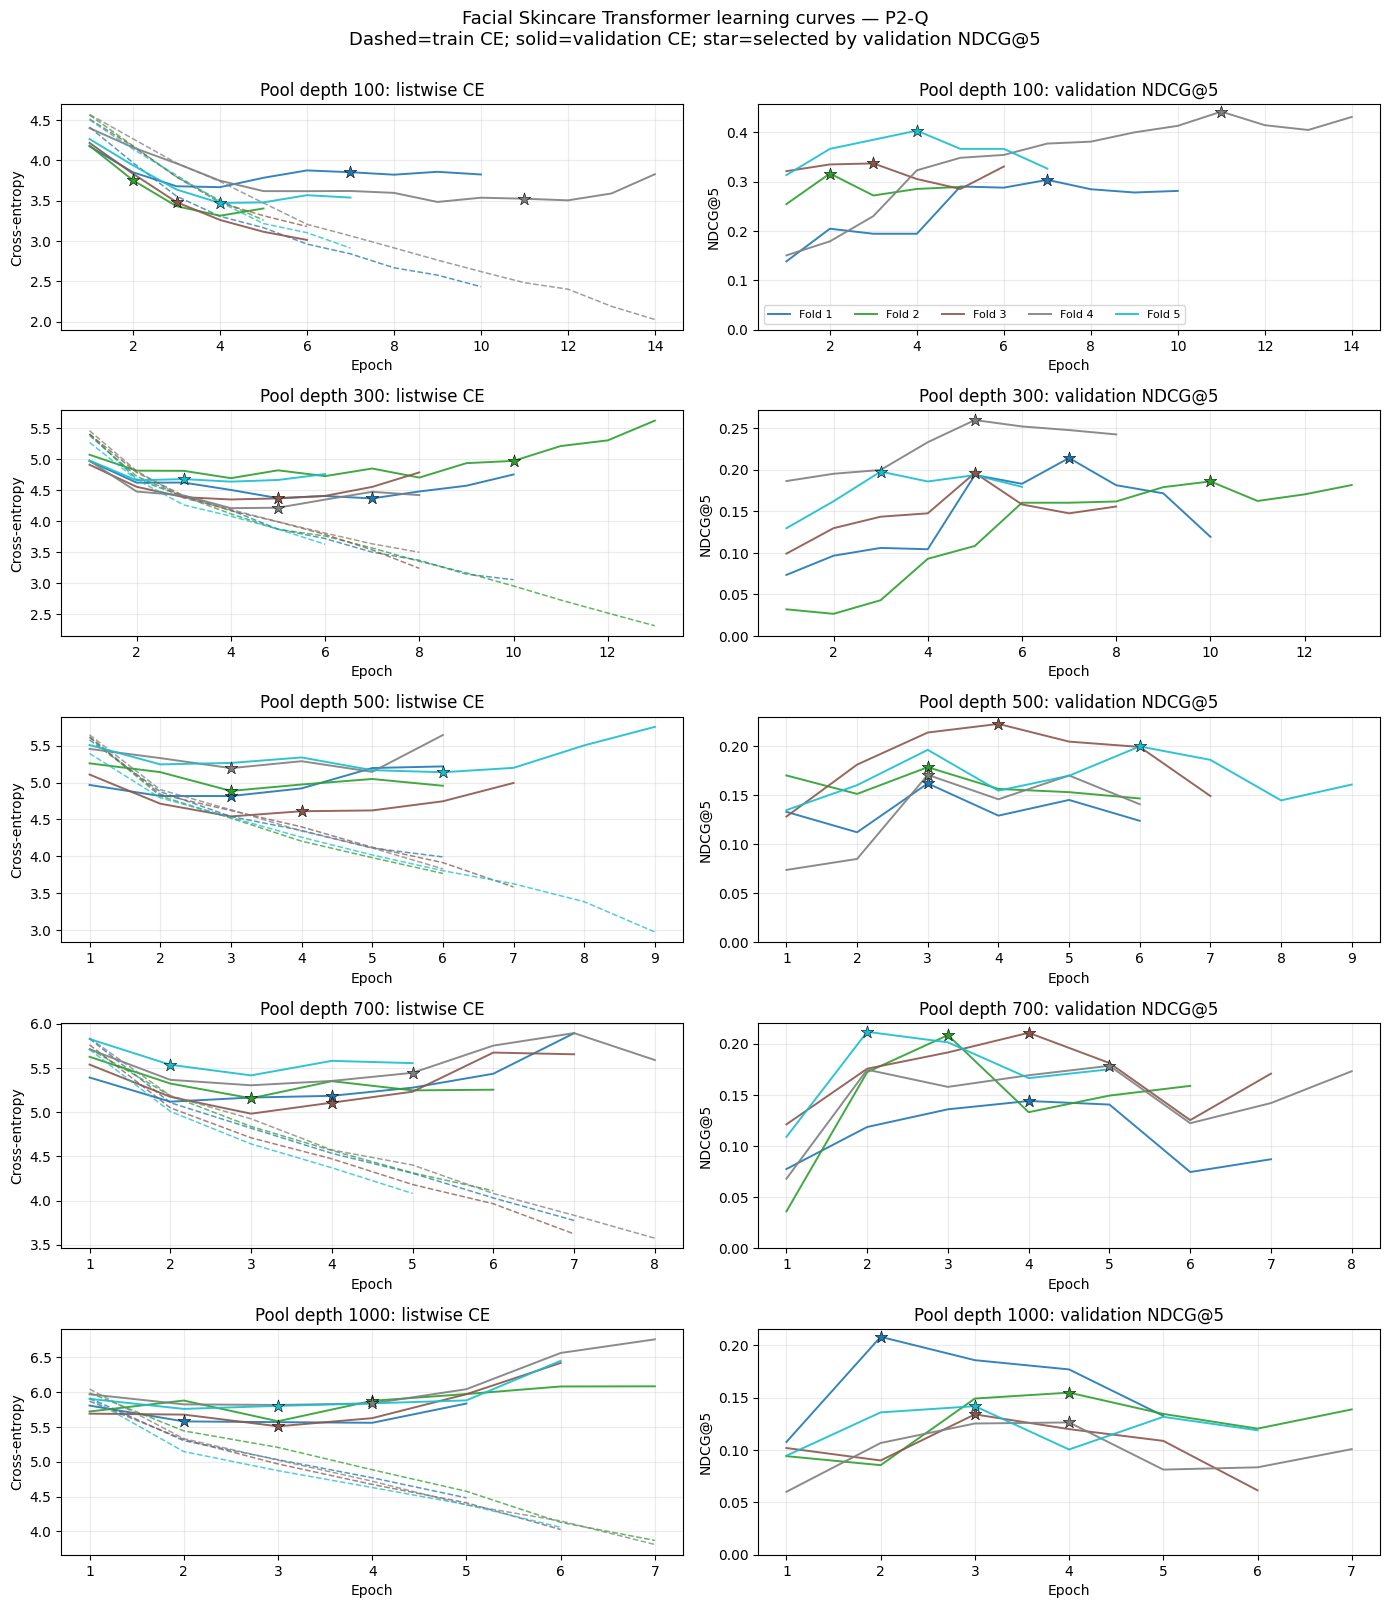

Runtime summary at @1000:


,category,category_id,notebook_name,branch,method,rerank_method,pool_depth,n_queries,n_candidates,online_operation_runtime_sec,offline_preparation_runtime_sec,evaluation_export_runtime_sec,total_notebook_runtime_sec,runtime_sec_per_query,runtime_sec_per_candidate,queries_per_second,candidates_per_second,model_end_to_end_runtime_sec,model_end_to_end_runtime_sec_per_query,model_end_to_end_runtime_sec_per_candidate,compute_framework,compute_device,cuda_available,gpu_name,torch_version,runtime_environment_note,runtime_scope,candidate_pool_type,retrieval_method,retrieval_method_label,reranking_method,sample_scope,common_sample_filtering_introduced,primary_metric,ndcg_at_5,hitrate_at_5,mrr_at_5,baseline_ndcg_at_5,baseline_hitrate_at_5,delta_ndcg_at_5_vs_baseline,delta_hitrate_at_5_vs_baseline,delta_ndcg5_per_100sec_online,delta_hitrate5_per_100sec_online
0,facial_skincare,face,13b_02_personalized_noprior_rerank_transformer...,transformer,transformer,transformer_rerank,1000,2288.0,2288000.0,297.329078,51.952109,1067.110827,2678.323926,0.129952,0.00013,7.695177,7695.17739,349.281188,0.152658,0.000153,torch,cuda,True,NVIDIA A100-SXM4-80GB,2.11.0+cu128,Transformer runtime may use GPU; compare again...,stage2_online_reranking_excluding_stage1_retri...,Profile Sparse QCHA,Profile Sparse QCHA,Profile Sparse QCHA,transformer,native,False,NDCG@5,0.028071,0.041521,0.023689,0.010081,0.014423,0.017989,0.027098,0.00605,0.009114


Runtime components at @1000:


,category_id,category_folder,category_label,method,rerank_method,pool_depth,n_queries,feature_preparation_runtime_sec,model_fit_or_tuning_runtime_sec,model_scoring_runtime_sec,ranking_sorting_runtime_sec,evaluation_runtime_sec,export_outputs_runtime_sec,online_operation_runtime_sec,model_end_to_end_runtime_sec,model_end_to_end_runtime_sec_per_query,compute_framework,compute_device,cuda_available,gpu_name,runtime_scope,candidate_pool_type,retrieval_method,retrieval_method_label,reranking_method
0,face,facial_skincare,Facial Skincare,transformer,transformer_rerank,1000,2288.0,289.305663,51.952109,1.246857,6.776558,388.054154,679.056673,297.329078,349.281188,0.152658,torch,cuda,True,NVIDIA A100-SXM4-80GB,stage2_online_reranking_excluding_stage1_retri...,Profile Sparse QCHA,Profile Sparse QCHA,Profile Sparse QCHA,transformer


Transformer reranking completed.
Output directory: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02
Saved outputs:
- results_overall: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/results_overall.csv
- results_by_pool_depth: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/results_by_pool_depth.csv
- results_by_regime: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/results_by_regime.csv
- results_by_regime_pool_depth: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/results_by_regime_pool_depth.csv
- runtime_by_pool_depth: /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/runtime_by_pool_depth

In [14]:
# Save Transformer reranking outputs, manifest, and runtime logs.

OUT_DIR.mkdir(parents=True, exist_ok=True)

output_paths = {
    "results_overall": OUT_DIR / "results_overall.csv",
    "results_by_pool_depth": OUT_DIR / "results_by_pool_depth.csv",
    "results_by_regime": OUT_DIR / "results_by_regime.csv",
    "results_by_regime_pool_depth": OUT_DIR / "results_by_regime_pool_depth.csv",
    "runtime_by_pool_depth": OUT_DIR / "runtime_by_pool_depth.csv",
    "ab_candidate_source_metrics": OUT_DIR / "transformer_face_candidate_source_metrics.csv",
    "ab_runtime_summary": OUT_DIR / "transformer_face_runtime_summary.csv",
    "ab_ranked_results": OUT_DIR / "transformer_face_ranked_results.parquet",
    "per_query_metrics": OUT_DIR / "per_query_metrics.parquet",
    "reranked_candidates": OUT_DIR / "reranked_candidates.parquet",
    "reranked_candidates_export_qc": OUT_DIR / "reranked_candidates_export_qc.csv",
    "preference_alignment_source_qc": OUT_DIR / "transformer_face_preference_alignment_source_qc.csv",
    "model_cv_summary": OUT_DIR / "transformer_model_cv_summary.csv",
    "learning_history": OUT_DIR / "transformer_learning_history.csv",
    "learning_curves": OUT_DIR / "transformer_learning_curves.png",
    "checkpoint_selection_qc": OUT_DIR / "transformer_checkpoint_selection_qc.csv",
    "feature_diagnostics": OUT_DIR / "transformer_feature_diagnostics.csv",
    "feature_manifest": OUT_DIR / "feature_manifest.json",
    "used_model_features": OUT_DIR / "used_model_features.csv",
    "feature_leakage_qc": OUT_DIR / "feature_leakage_qc.csv",
    "temporal_feature_summary": OUT_DIR / "temporal_feature_summary.csv",
    "run_manifest": OUT_DIR / "run_manifest.json",
    "cold_rerank_fallback_qc": OUT_DIR / "cold_rerank_fallback_qc.csv",
}

def plot_transformer_learning_curves(history_df: pd.DataFrame, output_path: Path) -> None:
    """Save fold-level train/validation CE and validation NDCG@5 curves."""
    if history_df.empty:
        raise RuntimeError("Transformer learning history is empty; cannot draw learning curves.")
    depths = sorted(pd.to_numeric(history_df["pool_depth"], errors="raise").astype(int).unique())
    figure, axes = plt.subplots(
        nrows=len(depths),
        ncols=2,
        figsize=(14, max(4.0, 3.2 * len(depths))),
        squeeze=False,
    )
    fold_colors = plt.cm.tab10(np.linspace(0.0, 1.0, max(int(N_FOLDS), 2)))

    for row_idx, pool_depth in enumerate(depths):
        depth_df = history_df.loc[
            pd.to_numeric(history_df["pool_depth"], errors="raise").astype(int).eq(int(pool_depth))
        ].copy()
        loss_ax, ndcg_ax = axes[row_idx]
        for color_idx, (fold_idx, fold_df) in enumerate(depth_df.groupby("fold", sort=True)):
            fold_df = fold_df.sort_values("epoch", kind="mergesort")
            color = fold_colors[color_idx % len(fold_colors)]
            epochs = pd.to_numeric(fold_df["epoch"], errors="raise").to_numpy(dtype=int)
            loss_ax.plot(
                epochs,
                pd.to_numeric(fold_df["training_listwise_ce"], errors="raise"),
                color=color,
                linestyle="--",
                linewidth=1.1,
                alpha=0.75,
            )
            loss_ax.plot(
                epochs,
                pd.to_numeric(fold_df["validation_listwise_ce"], errors="raise"),
                color=color,
                linestyle="-",
                linewidth=1.4,
                alpha=0.9,
            )
            ndcg_ax.plot(
                epochs,
                pd.to_numeric(fold_df["validation_ndcg_at_5"], errors="raise"),
                color=color,
                linewidth=1.4,
                alpha=0.9,
                label=f"Fold {int(fold_idx)}",
            )
            selected_values = fold_df["selected_checkpoint"]
            if pd.api.types.is_bool_dtype(selected_values):
                selected_mask = selected_values.fillna(False).astype(bool)
            elif pd.api.types.is_numeric_dtype(selected_values):
                selected_mask = pd.to_numeric(selected_values, errors="coerce").fillna(0).ne(0)
            else:
                selected_mask = selected_values.fillna("").astype(str).str.strip().str.lower().isin(
                    {"1", "true", "t", "yes", "y"}
                )
            selected = fold_df.loc[selected_mask]
            if len(selected) != 1:
                raise RuntimeError(
                    f"Expected one selected checkpoint for depth={pool_depth}, fold={fold_idx}."
                )
            selected_epoch = int(selected["epoch"].iloc[0])
            loss_ax.scatter(
                [selected_epoch],
                [float(selected["validation_listwise_ce"].iloc[0])],
                color=color,
                marker="*",
                s=90,
                edgecolor="black",
                linewidth=0.4,
                zorder=5,
            )
            ndcg_ax.scatter(
                [selected_epoch],
                [float(selected["validation_ndcg_at_5"].iloc[0])],
                color=color,
                marker="*",
                s=90,
                edgecolor="black",
                linewidth=0.4,
                zorder=5,
            )

        loss_ax.set_title(f"Pool depth {pool_depth}: listwise CE")
        loss_ax.set_xlabel("Epoch")
        loss_ax.set_ylabel("Cross-entropy")
        loss_ax.grid(alpha=0.25)
        ndcg_ax.set_title(f"Pool depth {pool_depth}: validation NDCG@5")
        ndcg_ax.set_xlabel("Epoch")
        ndcg_ax.set_ylabel("NDCG@5")
        ndcg_ax.set_ylim(bottom=0.0, top=min(1.0, max(0.05, ndcg_ax.get_ylim()[1])))
        ndcg_ax.grid(alpha=0.25)
        if row_idx == 0:
            ndcg_ax.legend(loc="best", ncol=min(int(N_FOLDS), 5), fontsize=8)

    curve_context = CONDITION_NAME
    if CONDITION_NAME == "Full":
        curve_context = "Full load-only scoring (training source: P2-P shared checkpoints)"
    figure.suptitle(
        f"{CATEGORY_LABEL} Transformer learning curves — {curve_context}\n"
        "Dashed=train CE; solid=validation CE; star=selected by validation NDCG@5",
        y=1.002,
        fontsize=13,
    )
    figure.tight_layout()
    figure.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(figure)


_export_n_queries = int(per_query_report_df.loc[
    per_query_report_df["rerank_method"].eq(TRANSFORMER_OUTPUT_RERANK_METHOD),
    "query_id",
].nunique())
_export_n_candidates = int(reranked_candidates_report_df.loc[
    reranked_candidates_report_df["rerank_method"].eq(TRANSFORMER_OUTPUT_RERANK_METHOD)
].shape[0])

with runtime_step(
    "export_outputs",
    pool_depth=RUNTIME_REPORT_POOL_DEPTH,
    n_queries=_export_n_queries,
    n_candidates=_export_n_candidates,
):
    summary_overall_df.to_csv(output_paths["results_overall"], index=False)
    summary_by_pool_depth_df.to_csv(output_paths["results_by_pool_depth"], index=False)
    summary_by_regime_df.to_csv(output_paths["results_by_regime"], index=False)
    summary_by_regime_pool_depth_df.to_csv(output_paths["results_by_regime_pool_depth"], index=False)
    runtime_by_pool_depth_df.to_csv(output_paths["runtime_by_pool_depth"], index=False)
    cold_rerank_fallback_qc_df.to_csv(output_paths["cold_rerank_fallback_qc"], index=False)
    ab_candidate_source_metrics_df.to_csv(output_paths["ab_candidate_source_metrics"], index=False)
    ab_runtime_summary_df.to_csv(output_paths["ab_runtime_summary"], index=False)
    ab_ranked_results_df.to_parquet(output_paths["ab_ranked_results"], index=False)

    per_query_metrics_df.to_parquet(output_paths["per_query_metrics"], index=False)
    model_cv_summary_df.to_csv(output_paths["model_cv_summary"], index=False)
    transformer_learning_history_df.to_csv(output_paths["learning_history"], index=False)
    checkpoint_selection_qc_df.to_csv(output_paths["checkpoint_selection_qc"], index=False)
    plot_transformer_learning_curves(
        transformer_learning_history_df, output_paths["learning_curves"]
    )
    feature_diagnostics_df.to_csv(output_paths["feature_diagnostics"], index=False)

    rank_position_feature_set = {"candidate_rank", "candidate_rank_pct_in_pool", "candidate_rank_from_bottom", "candidate_rank_log1p", "candidate_rank_inv"}
    raw_timestamp_feature_set = set(RAW_TIMESTAMP_FEATURE_COLS)
    identifier_or_text_feature_set = set(IDENTIFIER_OR_TEXT_FEATURE_COLS)
    model_feature_list = list(feature_cols)

    def infer_feature_group(feature_name):
        name = str(feature_name)
        if name in COMMON_TIME_FEATURE_COLS or "recency" in name or "recent_" in name or name.endswith("_gap_days") or name.endswith("_age_days") or "velocity" in name:
            return "temporal_recency"
        if name in rank_position_feature_set or name.startswith("candidate_rank"):
            return "retrieval_rank_position"
        if name.startswith("score__") or name in {"candidate_score", "candidate_score_norm_pool"}:
            return "retrieval_score"
        if name in BRAND_CANDIDATE_FEATURE_COLUMNS:
            return "candidate_brand"
        if name in BRAND_HISTORY_FEATURE_COLUMNS:
            return "user_brand_profile"
        if name.startswith("qmatch__") or name.startswith("item_label_n__") or name in {"query_item_structured_match", "item_title_token_overlap", "item_doc_token_overlap"}:
            return "query_item_match"
        if name.startswith("uaff__") or name.startswith("useen__") or name.startswith("ucountlog__") or name in {"user_item_affinity", "user_item_seen_strength"}:
            return "user_item_profile"
        if name.startswith("prior_"):
            return "history_size"
        if name.startswith("query_"):
            return "query_quality"
        return "other"

    used_model_features_df = pd.DataFrame({
        "model": RERANKING_METHOD,
        "feature": model_feature_list,
        "feature_group": [infer_feature_group(col) for col in model_feature_list],
        "is_model_specific": [col in rank_position_feature_set for col in model_feature_list],
        "is_temporal_feature": [col in COMMON_TIME_FEATURE_COLS for col in model_feature_list],
    })
    forbidden_model_features = [
        col for col in model_feature_list
        if col in raw_timestamp_feature_set
        or col in identifier_or_text_feature_set
        or str(col).endswith("_id")
    ]
    feature_leakage_qc_df = pd.DataFrame([
        {
            "check_name": "raw_timestamps_excluded_from_model_features",
            "check_passed": not any(col in raw_timestamp_feature_set for col in model_feature_list),
            "details": ",".join([col for col in model_feature_list if col in raw_timestamp_feature_set]),
        },
        {
            "check_name": "ids_labels_and_raw_text_excluded_from_model_features",
            "check_passed": len(forbidden_model_features) == 0,
            "details": ",".join(forbidden_model_features),
        },
        {
            "check_name": "strict_prior_history_filter_applied",
            "check_passed": bool(
                "prior_history_raw" in globals()
                and {"prior_timestamp_ms", "target_timestamp_ms"}.issubset(prior_history_raw.columns)
                and prior_history_raw["prior_timestamp_ms"].lt(prior_history_raw["target_timestamp_ms"]).all()
            ),
            "details": "prior_timestamp_ms < target_timestamp_ms",
        },
        {
            "check_name": "temporal_recency_features_used",
            "check_passed": any(col in COMMON_TIME_FEATURE_COLS for col in model_feature_list),
            "details": str(int(sum(col in COMMON_TIME_FEATURE_COLS for col in model_feature_list))),
        },
    ])
    if "temporal_feature_summary_df" not in globals():
        temporal_feature_summary_df = pd.DataFrame([
            {
                "feature": col,
                "used_as_numeric_model_feature": bool(col in model_feature_list),
            }
            for col in COMMON_TIME_FEATURE_COLS
        ])
    model_feature_contract_sha256 = hashlib.sha256(
        "\n".join(model_feature_list).encode("utf-8")
    ).hexdigest()
    feature_manifest = {
        "notebook_name": NOTEBOOK_NAME,
    "task_scope": "query_conditioned_next_novel_item_ranking",
    "specification_role": SPECIFICATION_ROLE,
    "primary_registry_policy_version": PRIMARY_REGISTRY_POLICY_VERSION,
    "exact_item_familiarity_enabled": ENABLE_EXACT_ITEM_FAMILIARITY,
    "exact_item_familiarity_diagnostic_columns": list(EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS),
    "exact_item_familiarity_in_primary_model": False,
    "legacy_results_reusable": LEGACY_RESULTS_REUSABLE,
    "requires_downstream_reaggregation": REQUIRES_DOWNSTREAM_REAGGREGATION,
        "brand_query_enabled": bool(BRAND_QUERY_ENABLED),
        "brand_candidate_visible": bool(BRAND_CANDIDATE_VISIBLE),
        "brand_reranking_enabled": bool(BRAND_RERANKING_ENABLED),
        "user_brand_affinity_enabled": bool(USE_USER_PRIOR_FEATURES and any(col in model_feature_list for col in USER_BRAND_FEATURE_COLUMNS)),
        "history_source": HISTORY_SOURCE,
        "historical_population_review_signals_in_user_profile": bool(HISTORICAL_POPULATION_REVIEW_SIGNALS_IN_USER_PROFILE),
        "candidate_brand_audit_column": "candidate_brand_raw",
        "query_brand_leak_qc_source": query_brand_qc_source,
        "query_brand_leak_row_count": int(query_brand_leak_row_count),
        "feature_contract_diagnostics": feature_contract_diagnostics,
        "p2q_feature_columns": list(P2Q_FEATURE_COLUMNS),
        "shared_all_prior_feature_columns": list(SHARED_ALL_PRIOR_FEATURE_COLUMNS),
        "model_feature_contract_sha256": model_feature_contract_sha256,
        "stage": STAGE,
        "reranking_method": RERANKING_METHOD,
        "query_variant": QUERY_VARIANT,
        "common_feature_registry": COMMON_FEATURE_REGISTRY_VERSION,
        "temporal_feature_version": TEMPORAL_FEATURE_VERSION,
        "item_facet_evidence_policy": ITEM_FACET_EVIDENCE_POLICY,
        "item_facet_source_qc": item_facet_source_qc,
        "facet_coverage_diagnostics": facet_coverage_diagnostics,
        "prior_history_source_qc": prior_history_source_qc,
        "no_prior_runtime_policy": NO_PRIOR_RUNTIME_POLICY,
        "model_feature_count": int(len(model_feature_list)),
        "temporal_model_feature_count": int(sum(col in COMMON_TIME_FEATURE_COLS for col in model_feature_list)),
        "model_features": model_feature_list,
        "model_specific_features": sorted([col for col in model_feature_list if col in rank_position_feature_set]),
        "rank_position_embedding": {
            "enabled": True,
            "max_rank": int(TRANSFORMER_RANK_EMBED_MAX),
            "description": "Rank-position features and embedding are Transformer-specific components.",
        },
        "raw_timestamp_features_used": False,
        "raw_identifier_or_text_features_used": False,
        "temporal_feature_rule": "derived recency features use only events before target_timestamp_ms",
        "item_temporal_recency_features_used": any(col in COMMON_TEMPORAL_ITEM_FEATURE_COLS for col in model_feature_list),
        "user_temporal_recency_features_used": any(col in COMMON_TEMPORAL_USER_FEATURE_COLS + COMMON_TEMPORAL_FAMILY_FEATURE_COLS for col in model_feature_list),
        "feature_leakage_qc_path": str(output_paths["feature_leakage_qc"]),
        "used_model_features_path": str(output_paths["used_model_features"]),
        "temporal_feature_summary_path": str(output_paths["temporal_feature_summary"]),
    }
    used_model_features_df.to_csv(output_paths["used_model_features"], index=False)
    feature_leakage_qc_df.to_csv(output_paths["feature_leakage_qc"], index=False)
    temporal_feature_summary_df.to_csv(output_paths["temporal_feature_summary"], index=False)
    output_paths["feature_manifest"].write_text(
        json.dumps(make_jsonable(feature_manifest), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    reranked_export_cols = [
        "case_id",
        "query_id",
        "user_id",
        "target_parent_asin",
        "gt_item_id",
        "regime",
        "candidate_source_method",
        "candidate_source_slug",
        "candidate_pool_type",
        "retrieval_method",
        "retrieval_method_label",
        "candidate_item_id",
        "candidate_parent_asin",
        "candidate_brand_raw",
        "candidate_rank",
        "candidate_score",
        "candidate_score_norm_pool",
        "transformer_score",
        "prediction_source",
        "native_transformer_score",
        "p2q_fallback_rerank_score",
        "p2q_fallback_rerank_rank",
        "rerank_method",
        "pool_depth",
        "rerank_rank",
        "is_gt",
        "query_item_structured_match",
        "user_item_affinity",
        "user_item_seen_strength",
    ]
    reranked_export_cols += [col for col in optional_score_cols if col in reranked_candidates_df.columns]
    reranked_export_cols = [col for col in dict.fromkeys(reranked_export_cols) if col in reranked_candidates_df.columns]

    reranked_export_df = reranked_candidates_df[reranked_export_cols].copy()
    target_col_for_diagnostics = "gt_item_id" if "gt_item_id" in reranked_export_df.columns else "target_parent_asin"
    reranked_export_df, reranked_candidates_export_qc_df = add_reranked_candidate_export_diagnostics(
        reranked_export_df,
        candidate_col="candidate_parent_asin",
        target_col=target_col_for_diagnostics,
    )
    reranked_export_df.to_parquet(
        output_paths["reranked_candidates"],
        index=False,
    )
    reranked_candidates_export_qc_df["output_path"] = str(output_paths["reranked_candidates"])
    reranked_candidates_export_qc_df.to_csv(output_paths["reranked_candidates_export_qc"], index=False)


    transformer_face_preference_alignment_source_qc_df = pd.DataFrame([{
        "output_dir": str(OUT_DIR),
        "candidate_source_slug_values": ",".join(sorted(reranked_export_df.get("candidate_source_slug", pd.Series(dtype=str)).dropna().astype(str).unique().tolist())),
        "selected_candidate_source_slug": SELECTED_RETRIEVAL_METHOD_SLUG,
        "selected_full_candidate_source_slug": SELECTED_RETRIEVAL_METHOD_SLUG,
        "query_item_structured_match_present": "query_item_structured_match" in reranked_export_df.columns,
        "alignment_metric_columns_present": ",".join([col for col in PREFERENCE_DIAGNOSTIC_METRICS if col in per_query_metrics_df.columns]),
        "product_type_columns_present": ",".join([col for col in list(reranked_export_df.columns) + list(per_query_metrics_df.columns) if "product_type" in str(col).lower() or "category_or_product_type" in str(col).lower()]),
        "invalid_facial_columns_present": ",".join([col for col in list(reranked_export_df.columns) + list(per_query_metrics_df.columns) if col in {"product_type_match_at_5", "category_or_product_type_match_at_5", "profile_history_item_n", "profile_history_review_n", "query_token_len", "candidate_n"}]),
    }])
    transformer_face_preference_alignment_source_qc_df.to_csv(output_paths["preference_alignment_source_qc"], index=False)

input_paths = {
    "stage1_candidate_pool_export_manifest": str(CANDIDATE_POOL_MANIFEST_PATH),
    "candidate_pool": str(CANDIDATE_POOL_PATH),
    "query_cache": str(QUERY_CACHE_PARQUET),
    "item_schema": str(ITEM_SCHEMA_PARQUET),
    "item_docs": str(ITEM_DOCS_PARQUET),
    "items_facets": str(ITEMS_FACETS_PARQUET),
    "retrieval_artifact_manifest": str(RETRIEVAL_ARTIFACT_MANIFEST_JSON),
    "prior_history": str(PRIOR_HISTORY_PARQUET),
    "target_case_metadata": str(TARGET_CASE_METADATA_PARQUET),
    "item_review_time_index": str(ITEM_REVIEW_TIME_INDEX_PATH),
    "temporal_artifact_manifest": str(TEMPORAL_ARTIFACT_MANIFEST_PATH),
}

candidate_source_qc = {
    "expected_candidate_pool_type": CANDIDATE_POOL_TYPE,
    "observed_candidate_pool_type": sorted(candidate_df["candidate_pool_type"].astype(str).unique().tolist()),
    "expected_retrieval_method": RETRIEVAL_METHOD,
    "observed_retrieval_method": sorted(candidate_df["retrieval_method"].astype(str).unique().tolist()),
    "candidate_rows": int(len(candidate_df)),
    "query_count": int(candidate_df["query_id"].nunique()),
    "min_candidates_per_query": int(query_candidate_counts.min()),
    "max_candidates_per_query": int(query_candidate_counts.max()),
}

condition_name = B02_OUTPUT_CONDITION_SERIES
source_notebook_name = SOURCE_NOTEBOOK_NAME

manifest = {
    "notebook_name": NOTEBOOK_NAME,
    "brand_query_enabled": bool(BRAND_QUERY_ENABLED),
    "brand_candidate_visible": bool(BRAND_CANDIDATE_VISIBLE),
    "brand_reranking_enabled": bool(BRAND_RERANKING_ENABLED),
    "user_brand_affinity_enabled": bool(USE_USER_PRIOR_FEATURES and any(col in feature_cols for col in USER_BRAND_FEATURE_COLUMNS)),
    "history_source": HISTORY_SOURCE,
    "historical_population_review_signals_in_user_profile": bool(HISTORICAL_POPULATION_REVIEW_SIGNALS_IN_USER_PROFILE),
    "query_brand_leak_qc_source": query_brand_qc_source,
    "query_brand_leak_row_count": int(query_brand_leak_row_count),
    "shared_all_prior_model_role": SHARED_ALL_PRIOR_MODEL_ROLE,
    "shared_all_prior_model_dir": str(SHARED_ALL_PRIOR_MODEL_DIR),
    "category_id": CATEGORY_ID,
    "category_folder": CATEGORY_FOLDER,
    "category_label": CATEGORY_LABEL,
    "stage": STAGE,
    "experiment_condition": EXPERIMENT_CONDITION,
    "condition": condition_name,
    "query_method": QUERY_METHOD,
    "query_variant": QUERY_VARIANT,
    "candidate_pool_type": CANDIDATE_POOL_TYPE,
    "candidate_source": CANDIDATE_SOURCE_LABEL,
    "candidate_source_format": CANDIDATE_SOURCE_FORMAT,
    "candidate_pool_path": str(CANDIDATE_POOL_PATH),
    "candidate_pool_role": CANDIDATE_POOL_ROLE,
    "selected_stage1_method_slug": SELECTED_RETRIEVAL_METHOD_SLUG,
    "selected_stage1_method_label": SELECTED_RETRIEVAL_METHOD,
    "stage1_candidate_pool_manifest_path": str(CANDIDATE_POOL_MANIFEST_PATH),
    "ab_candidate_source_slugs": list(AB_CANDIDATE_SOURCE_SLUGS),
    "candidate_pool_source": source_notebook_name,
    "retrieval_method": RETRIEVAL_METHOD,
    "retrieval_method_label": RETRIEVAL_METHOD_LABEL,
    "reranking_method": RERANKING_METHOD,
    "rerank_method": TRANSFORMER_OUTPUT_RERANK_METHOD,
    "expected_rerank_methods": list(EXPECTED_RERANK_METHODS),
    "cold_reranking_fallback_policy": "use_same_family_p2q_oof_predictions",
    "cold_users_in_prior_aware_training": False,
    "cold_prediction_source": "p2q_cold_fallback",
    "cold_metric_identity_passed": bool(cold_rerank_fallback_qc_df["cold_metric_identity_passed"].all()),
    "history_eligible_regimes": ["weak", "moderate", "strong"],
    "p2q_oof_prediction_path": str(P2Q_OOF_PREDICTION_PATH),
    "pool_k": int(POOL_K),
    "pool_depths": [int(x) for x in POOL_DEPTHS],
    "max_pool_depth": int(MAX_POOL_DEPTH),
    "report_pool_depth": int(REPORT_POOL_DEPTH),
    "eval_ks": [int(x) for x in EVAL_KS],
    "primary_metrics": PRIMARY_STAGE2_METRICS,
    "secondary_metrics": SECONDARY_STAGE2_METRICS,
    "supplementary_metrics": SUPPLEMENTARY_STAGE2_METRICS,
    "preference_diagnostic_metrics": PREFERENCE_DIAGNOSTIC_METRICS,
    "preference_diagnostic_families": PREFERENCE_DIAGNOSTIC_FAMILIES,
    "preference_diagnostic_family_weights": PREFERENCE_DIAGNOSTIC_FAMILY_WEIGHTS,
    "common_comparison_metrics": COMMON_STAGE2_COMPARISON_METRICS,
    "candidate_set_changed_by_reranker": bool(candidate_set_changed_by_reranker),
    "raw_reviews_loaded": False,
    "rating_used": False,
    "helpful_vote_used": False,
    "sentiment_used": False,
    "prior_review_text_loaded": False,
    "notebook_09_dependency": True,
    "notebook_08_dependency": "indirect_via_notebook09",
    "item_facets_rebuilt": False,
    "synthetic_item_facets_created": False,
    "source_notebook": source_notebook_name,
    "input_paths": input_paths,
    "output_paths": {key: str(path) for key, path in output_paths.items()},
    "feature_manifest_path": str(output_paths["feature_manifest"]),
    "model_feature_contract_sha256": model_feature_contract_sha256,
    "used_model_features_path": str(output_paths["used_model_features"]),
    "feature_leakage_qc_path": str(output_paths["feature_leakage_qc"]),
    "temporal_feature_summary_path": str(output_paths["temporal_feature_summary"]),
    "candidate_source_qc": candidate_source_qc,
    "device": str(DEVICE),
    "compute_framework": "torch",
    "cuda_available": bool(torch.cuda.is_available()),
    "gpu_name": str(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else "",
    "torch_version": str(torch.__version__),
    "runtime_environment_note": "Transformer runtime may use GPU; compare against LightGBM CPU runtime as observed serving-cost diagnostics, not hardware-normalized benchmarks.",
    "transformer_framework_version": TRANSFORMER_FRAMEWORK_VERSION,
    "transformer_architecture": "listwise_candidate_transformer_encoder",
    "cv_split_policy": CV_SPLIT_POLICY,
    "training_query_policy": TRAINING_QUERY_POLICY,
    "matched_fitting_policy": TRANSFORMER_MATCHED_FITTING_POLICY,
    "training_plan_contract_version": TRANSFORMER_TRAINING_PLAN_VERSION,
    "model_contract_version": TRANSFORMER_MODEL_CONTRACT_VERSION,
    "sample_weight_policy": "none_query_groups_unweighted",
    "user_prior_feature_policy": USER_PRIOR_FEATURE_POLICY,
    "user_prior_features_enabled": bool(USE_USER_PRIOR_FEATURES),
    "candidate_score_model_policy": CANDIDATE_SCORE_MODEL_POLICY,
    "item_facet_evidence_policy": ITEM_FACET_EVIDENCE_POLICY,
    "item_facet_source_qc": item_facet_source_qc,
    "facet_coverage_diagnostics": facet_coverage_diagnostics,
    "prior_history_source_qc": prior_history_source_qc,
    "no_prior_runtime_policy": NO_PRIOR_RUNTIME_POLICY,
    "prior_history_loaded": bool(USE_USER_PRIOR_FEATURES),
    "user_temporal_feature_construction_enabled": bool(USE_USER_PRIOR_FEATURES and USE_TEMPORAL_RECENCY_FEATURES),
    "raw_retrieval_score_used_as_model_feature": bool(USE_RAW_RETRIEVAL_SCORE_FEATURE),
    "method_specific_retrieval_component_scores_used": bool(USE_METHOD_SPECIFIC_RETRIEVAL_COMPONENT_SCORES),
    "ranking_loss": "listwise_cross_entropy",
    "checkpoint_selection_metric": TRANSFORMER_CHECKPOINT_SELECTION_METRIC,
    "checkpoint_selection_rule": TRANSFORMER_CHECKPOINT_SELECTION_RULE,
    "early_stopping_policy": TRANSFORMER_EARLY_STOPPING_POLICY,
    "learning_curve_version": TRANSFORMER_LEARNING_CURVE_VERSION,
    "learning_history_path": str(output_paths["learning_history"]),
    "learning_curves_path": str(output_paths["learning_curves"]),
    "checkpoint_selection_qc_path": str(output_paths["checkpoint_selection_qc"]),
    "transformer_d_model": int(TRANSFORMER_D_MODEL),
    "transformer_nhead": int(TRANSFORMER_NHEAD),
    "transformer_num_layers": int(TRANSFORMER_NUM_LAYERS),
    "transformer_dim_feedforward": int(TRANSFORMER_DIM_FEEDFORWARD),
    "transformer_dropout": float(TRANSFORMER_DROPOUT),
    "transformer_max_epochs": int(TRANSFORMER_MAX_EPOCHS),
    "transformer_patience": int(TRANSFORMER_PATIENCE),
    "transformer_checkpoint_ndcg_tolerance": float(TRANSFORMER_CHECKPOINT_NDCG_TOL),
    "transformer_checkpoint_ce_tolerance": float(TRANSFORMER_CHECKPOINT_CE_TOL),
    "transformer_learning_rate": float(TRANSFORMER_LR),
    "transformer_weight_decay": float(TRANSFORMER_WEIGHT_DECAY),
    "transformer_grad_clip": float(TRANSFORMER_GRAD_CLIP),
    "transformer_label_smoothing": float(TRANSFORMER_LABEL_SMOOTHING),
    "transformer_use_amp": bool(TRANSFORMER_USE_AMP),
    "transformer_rank_embed_max": int(TRANSFORMER_RANK_EMBED_MAX),
    "common_feature_registry_version": COMMON_FEATURE_REGISTRY_VERSION,
    "temporal_feature_version": TEMPORAL_FEATURE_VERSION,
    "temporal_recency_features_enabled": bool(USE_TEMPORAL_RECENCY_FEATURES),
    "temporal_model_feature_count": int(sum(col in COMMON_TIME_FEATURE_COLS for col in feature_cols)),
    "transformer_batch_size_by_depth": {str(k): int(v) for k, v in TRANSFORMER_BATCH_SIZE_BY_DEPTH.items()},
    "transformer_num_workers": int(TRANSFORMER_NUM_WORKERS),
    "runtime_frame": f"notebook10_compatible_{EXPERIMENT_CONDITION}_runtime_frame",
    "host": socket.gethostname(),
    "platform": platform.platform(),
}

output_paths["run_manifest"].write_text(
    json.dumps(make_jsonable(manifest), ensure_ascii=False, indent=2),
    encoding="utf-8",
)

(
    runtime_steps_df,
    runtime_notebook_summary_df,
    runtime_method_summary_at1000_df,
    runtime_pool_depth_diagnostic_df,
    runtime_method_components_at1000_df,
) = export_runtime_logs(
    OUT_DIR,
    report_pool_depth=RUNTIME_REPORT_POOL_DEPTH,
)

runtime_output_paths = [
    OUT_DIR / "runtime_steps.csv",
    OUT_DIR / "runtime_notebook_summary.csv",
    OUT_DIR / "runtime_method_summary_at1000.csv",
    OUT_DIR / "runtime_pool_depth_diagnostic.csv",
    OUT_DIR / f"runtime_method_components_at1000_{CATEGORY_ID}.csv",
]

print("Runtime summary at @1000:")
display(runtime_method_summary_at1000_df)
print("Runtime components at @1000:")
display(runtime_method_components_at1000_df)

print("Transformer reranking completed.")
print("Output directory:", OUT_DIR)
print("Saved outputs:")

for key, path in output_paths.items():
    print(f"- {key}: {path}")
for path in runtime_output_paths:
    print(f"- runtime: {path}")

clear_torch_memory()
# Backfill target_rank_desc from Notebook 03 sampling artifacts if Notebook 09 candidate rows have missing ranks.
target_rank_lookup_frames = []
sampling_rank_paths = [
    PROJECT_ROOT / "data" / "processed" / "user_sampling" / "face_user_regime_sample.parquet",
    PROJECT_ROOT / "data" / "processed" / "user_sampling" / "face_final_sampling_pool.parquet",
]
for rank_path in sampling_rank_paths:
    if rank_path.exists():
        rank_columns = pq.ParquetFile(rank_path).schema.names
        if {"case_id", "target_rank_desc"}.issubset(rank_columns):
            target_rank_lookup_frames.append(
                pd.read_parquet(rank_path, columns=["case_id", "target_rank_desc"])
            )
if target_rank_lookup_frames:
    target_rank_lookup_df = pd.concat(target_rank_lookup_frames, ignore_index=True)
    target_rank_lookup_df["case_id"] = target_rank_lookup_df["case_id"].astype(str).str.strip()
    target_rank_lookup_df["target_rank_desc"] = pd.to_numeric(
        target_rank_lookup_df["target_rank_desc"],
        errors="coerce",
    )
    target_rank_lookup_df = (
        target_rank_lookup_df
        .dropna(subset=["case_id", "target_rank_desc"])
        .drop_duplicates("case_id", keep="first")
    )
    target_rank_map = target_rank_lookup_df.set_index("case_id")["target_rank_desc"]
    if "target_rank_desc" not in candidate_df.columns:
        candidate_df["target_rank_desc"] = pd.NA
    candidate_df["case_id"] = candidate_df["case_id"].astype(str).str.strip()
    candidate_df["target_rank_desc"] = pd.to_numeric(candidate_df["target_rank_desc"], errors="coerce")
    missing_rank_mask = candidate_df["target_rank_desc"].isna()
    candidate_df.loc[missing_rank_mask, "target_rank_desc"] = (
        candidate_df.loc[missing_rank_mask, "case_id"].map(target_rank_map)
    )
bad_rank_cases = candidate_df.loc[
    candidate_df["target_rank_desc"].isna()
    | candidate_df["target_rank_desc"].gt(MAX_TARGET_RANK_ALLOWED),
    ["case_id", "query_id", "target_rank_desc"],
].drop_duplicates().head(20)
if len(bad_rank_cases):
    display(bad_rank_cases)
    raise RuntimeError("target_rank_desc is missing or exceeds MAX_TARGET_RANK_ALLOWED after Notebook 03 backfill.")

_target_rank_desc_values = (
    pd.to_numeric(candidate_df.drop_duplicates("query_id")["target_rank_desc"], errors="coerce")
    if "target_rank_desc" in candidate_df.columns
    else pd.Series(dtype=float)
)
final_qc = {
    "candidate_input_path": str(CANDIDATE_POOL_PATH),
    "query_count": int(candidate_df["query_id"].astype(str).nunique()),
    "candidate_row_count": int(len(candidate_df)),
    "regime_counts": {
        regime: int((candidate_df.drop_duplicates("query_id")["regime"].astype(str) == regime).sum())
        for regime in EXPECTED_REGIME_COUNTS
    },
    "target_rank_desc_available": bool(_target_rank_desc_values.notna().any()),
    "missing_target_rank_desc_count": int(_target_rank_desc_values.isna().sum()),
    "max_target_rank_desc": int(_target_rank_desc_values.max()) if _target_rank_desc_values.notna().any() else None,
    "unique_target_selection_mode": sorted(candidate_df["target_selection_mode"].dropna().astype(str).unique().tolist()) if "target_selection_mode" in candidate_df.columns else [],
    "missing_target_timestamp_ms_count": int(candidate_df.drop_duplicates("query_id")["target_timestamp_ms"].isna().sum()) if "target_timestamp_ms" in candidate_df.columns else None,
    "output_folder": str(OUT_DIR),
}
print("Final compatibility QC:")
for key, value in final_qc.items():
    print(f"{key}: {value}")

if final_qc["query_count"] != EXPECTED_QUERY_COUNT:
    raise RuntimeError(f"Expected {EXPECTED_QUERY_COUNT} queries, found {final_qc['query_count']}.")
if final_qc["candidate_row_count"] != EXPECTED_CANDIDATE_ROWS_TOP1000:
    raise RuntimeError(f"Expected {EXPECTED_CANDIDATE_ROWS_TOP1000} candidate rows, found {final_qc['candidate_row_count']}.")
if final_qc["max_target_rank_desc"] is None or final_qc["max_target_rank_desc"] > MAX_TARGET_RANK_ALLOWED:
    raise RuntimeError(f"target_rank_desc exceeds {MAX_TARGET_RANK_ALLOWED} or is missing.")
if final_qc["unique_target_selection_mode"] != [EXPECTED_TARGET_SELECTION_MODE]:
    raise RuntimeError(f"Unexpected target_selection_mode values: {final_qc['unique_target_selection_mode']}.")
if final_qc["missing_target_timestamp_ms_count"] != 0:
    raise RuntimeError("target_timestamp_ms must be present for every query.")


In [15]:
# =========================================================
# Transformer output naming QC
# =========================================================

_final_method_frames = []
for _name in [
    "runtime_by_pool_depth_df",
    "runtime_pool_depth_diagnostic_df",
    "summary_overall_df",
    "summary_by_pool_depth_df",
    "summary_by_regime_df",
    "summary_by_regime_pool_depth_df",
    "per_query_metrics_df",
    "reranked_export_df",
]:
    _df = globals().get(_name)
    if isinstance(_df, pd.DataFrame) and "method" in _df.columns:
        _final_method_frames.append((_name, _df))

_unique_methods = sorted({
    str(value)
    for _, _df in _final_method_frames
    for value in _df["method"].dropna().astype(str).unique().tolist()
})
_method_label_frames = [
    _name for _name, _df in _final_method_frames
    if "method_label" in _df.columns
]
_method_label_absent = len(_method_label_frames) == 0
_output_files_created = [
    str(path)
    for path in [
        globals().get("results_overall_path"),
        globals().get("results_by_pool_depth_path"),
        globals().get("runtime_by_pool_depth_path"),
        globals().get("run_manifest_path"),
    ]
    if path is not None and Path(path).exists()
]

print("Unique final method values:", _unique_methods)
print("method_label absent from final exported result tables:", _method_label_absent)
print("Frames with method_label:", _method_label_frames)
print("Output files created:")
for _path in _output_files_created:
    print(_path)

if not _method_label_absent:
    raise RuntimeError(f"method_label is still present in final exported result frames: {_method_label_frames}")


Unique final method values: ['transformer']
method_label absent from final exported result tables: True
Frames with method_label: []
Output files created:


In [16]:
# =========================================================
# Runtime Pool Depth QC
# =========================================================
expected_runtime_depths = sorted(int(depth) for depth in POOL_DEPTHS)
runtime_depths_present = sorted(runtime_by_pool_depth_df["pool_depth"].astype(int).unique().tolist())
runtime_component_columns = [
    "feature_preparation_runtime_sec",
    "model_scoring_runtime_sec",
    "ranking_sorting_runtime_sec",
    "online_operation_runtime_sec",
    "runtime_sec_per_query",
    "runtime_sec_per_candidate",
    "queries_per_second",
    "candidates_per_second",
]
missing_runtime_components = [
    column for column in runtime_component_columns
    if column not in runtime_by_pool_depth_df.columns
]
duplicate_key_columns = [
    column for column in ["pool_depth", "reranker", "method", "reranking_method"]
    if column in runtime_by_pool_depth_df.columns
]
duplicate_runtime_rows = int(runtime_by_pool_depth_df.duplicated(duplicate_key_columns).sum()) if duplicate_key_columns else 0
runtime_file_candidates = []

if "output_paths" in globals() and isinstance(output_paths, dict):
    runtime_file_candidates.extend(
        path for key, path in output_paths.items()
        if str(key).startswith("runtime") or str(key).endswith("manifest")
    )

if "runtime_output_paths" in globals():
    runtime_file_candidates.extend(runtime_output_paths)

for _name in [
    "runtime_by_pool_depth_path",
    "runtime_report_summary_path",
    "runtime_steps_path",
    "runtime_notebook_summary_path",
]:
    if _name in globals():
        runtime_file_candidates.append(globals()[_name])

runtime_files_created = sorted({
    str(Path(path)) for path in runtime_file_candidates
    if path is not None and Path(path).exists()
})

print("Candidate pool depths evaluated:", expected_runtime_depths)
print("Candidate pool depths in runtime_by_pool_depth.csv:", runtime_depths_present)
print("Every evaluated pool depth has a runtime row:", runtime_depths_present == expected_runtime_depths)
print("Output runtime files created:", runtime_files_created)
if missing_runtime_components:
    print("Warning: missing runtime component columns:", missing_runtime_components)
else:
    print("Warning: missing runtime component columns: none")
if duplicate_runtime_rows:
    print("Warning: duplicate runtime rows:", duplicate_runtime_rows)
else:
    print("Warning: duplicate runtime rows: none")

if runtime_depths_present != expected_runtime_depths:
    raise RuntimeError("Not every evaluated pool depth has a runtime row.")
if missing_runtime_components:
    raise RuntimeError("Runtime component columns are missing from runtime_by_pool_depth_df.")
if duplicate_runtime_rows:
    raise RuntimeError("Duplicate per-depth runtime rows were found.")


Candidate pool depths evaluated: [100, 300, 500, 700, 1000]
Candidate pool depths in runtime_by_pool_depth.csv: [100, 300, 500, 700, 1000]
Every evaluated pool depth has a runtime row: True
Output runtime files created: ['/content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/feature_manifest.json', '/content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/run_manifest.json', '/content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/runtime_by_pool_depth.csv', '/content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/runtime_method_components_at1000_face.csv', '/content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/runtime_method_summary_at1000.csv', '/content/drive/MyDrive/thesis_recsys/categorie

In [17]:
# =========================================================
# Metric Depth QC
# =========================================================
_required_eval_ks = [1, 5, 10, 100, 300, 500, 700, 1000]
_required_pool_depths = [100, 300, 500, 700, 1000]
_metric_qc_df = globals().get("per_query_results_df", globals().get("per_query_metrics_df", pd.DataFrame()))
_summary_qc_df = globals().get("summary_by_pool_depth_df", globals().get("results_by_pool_depth_df", pd.DataFrame()))
_available_hitrate_cols = sorted([col for col in _metric_qc_df.columns if re.match(r"^HitRate@\d+$", str(col))], key=lambda col: int(str(col).split("@")[1]))
_available_ndcg_cols = sorted([col for col in _metric_qc_df.columns if re.match(r"^NDCG@\d+$", str(col))], key=lambda col: int(str(col).split("@")[1]))
_available_mrr_cols = sorted([col for col in _metric_qc_df.columns if re.match(r"^MRR@\d+$", str(col))], key=lambda col: int(str(col).split("@")[1]))
_required_metric_cols = [
    f"{metric}@{k}"
    for metric in ["HitRate", "NDCG", "MRR"]
    for k in _required_eval_ks
]
_missing_metric_cols = [col for col in _required_metric_cols if col not in _metric_qc_df.columns]
_pool_depths_present = sorted(pd.to_numeric(_metric_qc_df.get("pool_depth", pd.Series(dtype="float64")), errors="coerce").dropna().astype(int).unique().tolist())
_summary_missing_metric_cols = [col for col in _required_metric_cols if col not in _summary_qc_df.columns]
_every_pool_depth_has_metrics = (
    _pool_depths_present == _required_pool_depths
    and not _missing_metric_cols
    and not _summary_missing_metric_cols
)
_runtime_depths_present = []
if isinstance(globals().get("runtime_by_pool_depth_df"), pd.DataFrame) and "pool_depth" in runtime_by_pool_depth_df.columns:
    _runtime_depths_present = sorted(pd.to_numeric(runtime_by_pool_depth_df["pool_depth"], errors="coerce").dropna().astype(int).unique().tolist())
_output_files_created = []
for _name, _value in list(globals().items()):
    if _name.endswith("_path") and isinstance(_value, (str, Path)):
        _path = Path(_value)
        if _path.exists():
            _output_files_created.append(str(_path))
if "output_paths" in globals() and isinstance(output_paths, dict):
    for _path in output_paths.values():
        _path = Path(_path)
        if _path.exists():
            _output_files_created.append(str(_path))
_output_files_created = sorted(set(_output_files_created))

print("POOL_DEPTHS:", list(POOL_DEPTHS))
print("EVAL_KS:", list(EVAL_KS))
print("Available HitRate columns:", _available_hitrate_cols)
print("Available NDCG columns:", _available_ndcg_cols)
print("Available MRR columns:", _available_mrr_cols)
print("Evaluated pool depths:", _pool_depths_present)
print("Runtime pool depths:", _runtime_depths_present)
print("Every evaluated pool depth has all required EVAL_KS metrics:", _every_pool_depth_has_metrics)
print("Output files created:", _output_files_created)

if list(POOL_DEPTHS) != _required_pool_depths:
    raise RuntimeError(f"POOL_DEPTHS mismatch: {list(POOL_DEPTHS)}")
if list(EVAL_KS) != _required_eval_ks:
    raise RuntimeError(f"EVAL_KS mismatch: {list(EVAL_KS)}")
if _pool_depths_present != _required_pool_depths:
    raise RuntimeError(f"Metric rows do not cover required pool depths: {_pool_depths_present}")
if _missing_metric_cols:
    raise RuntimeError(f"Missing per-query metric columns: {_missing_metric_cols}")
if _summary_missing_metric_cols:
    raise RuntimeError(f"Missing by-pool-depth summary metric columns: {_summary_missing_metric_cols}")


POOL_DEPTHS: [100, 300, 500, 700, 1000]
EVAL_KS: [1, 5, 10, 100, 300, 500, 700, 1000]
Available HitRate columns: ['HitRate@1', 'HitRate@5', 'HitRate@10', 'HitRate@100', 'HitRate@300', 'HitRate@500', 'HitRate@700', 'HitRate@1000']
Available NDCG columns: ['NDCG@1', 'NDCG@5', 'NDCG@10', 'NDCG@100', 'NDCG@300', 'NDCG@500', 'NDCG@700', 'NDCG@1000']
Available MRR columns: ['MRR@1', 'MRR@5', 'MRR@10', 'MRR@100', 'MRR@300', 'MRR@500', 'MRR@700', 'MRR@1000']
Evaluated pool depths: [100, 300, 500, 700, 1000]
Runtime pool depths: [100, 300, 500, 700, 1000]
Every evaluated pool depth has all required EVAL_KS metrics: True
Output files created: ['/content/drive/MyDrive/thesis_recsys/categories/facial_skincare/data/processed/user_sampling/face_final_sampling_pool.parquet', '/content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/cold_rerank_fallback_qc.csv', '/content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_per

In [18]:
# =========================================================
# Held-Out Structured-Feature Interpretation Export
# =========================================================
model_feature_columns = list(feature_cols)
if len(model_feature_columns) != len(set(model_feature_columns)):
    raise RuntimeError("Transformer structured feature names must be unique.")

if CONDITION_NAME == "P2-Q":
    if model_feature_columns != list(P2Q_FEATURE_COLUMNS):
        raise RuntimeError("Executed RetrP feature order differs from the no-prior contract.")
    executed_transformer_settings = globals()["transformer_setting_contract"]()
    model_artifact_paths_for_depth = globals()["shared_all_prior_artifact_paths"]
else:
    if model_feature_columns != list(SHARED_ALL_PRIOR_FEATURE_COLUMNS):
        raise RuntimeError("Executed All Prior feature order differs from the shared contract.")
    executed_transformer_settings = globals()["transformer_setting_contract"]()
    model_artifact_paths_for_depth = globals()["shared_all_prior_artifact_paths"]

feature_dtype_contract = {
    column: str(feature_df[column].dtype) for column in model_feature_columns
}
if any(dtype != "float32" for dtype in feature_dtype_contract.values()):
    raise RuntimeError(f"Unexpected structured feature dtype: {feature_dtype_contract}")

brand_affinity_feature_columns = [
    column for column in model_feature_columns if column in set(USER_BRAND_FEATURE_COLUMNS)
]
candidate_side_brand_feature_columns = [
    column for column in model_feature_columns if column in set(BRAND_CANDIDATE_FEATURE_COLUMNS)
]
user_history_feature_columns = [
    column for column in model_feature_columns if is_no_prior_excluded_feature(column)
]

if CONDITION_NAME == "P2-Q":
    if user_history_feature_columns:
        raise RuntimeError(f"RetrP contains user-history model features: {user_history_feature_columns}")
    if brand_affinity_feature_columns:
        raise RuntimeError(f"RetrP contains brand-affinity model features: {brand_affinity_feature_columns}")
else:
    if HISTORY_SOURCE != "all_prior":
        raise RuntimeError(f"{CONDITION_NAME} must use All Prior history.")
    if feature_columns_P2P != feature_columns_Full or feature_dtypes_P2P != feature_dtypes_Full:
        raise RuntimeError("P2-P and Full structured feature schemas must be identical.")
if HISTORICAL_POPULATION_REVIEW_SIGNALS_IN_USER_PROFILE:
    raise RuntimeError("Historical population-level review signals must remain outside the user profile.")

retrieval_features = {
    "candidate_rank", "candidate_rank_log1p", "candidate_rank_inv", "candidate_score",
    "candidate_score_norm_pool", "candidate_rank_pct_in_pool", "candidate_rank_from_bottom",
}
query_item_text_features = {
    "query_token_count", "query_unique_token_count", "query_token_len",
    "query_token_len_log1p", "query_unique_token_len", "query_unique_token_len_log1p",
    "item_title_token_overlap", "item_doc_token_overlap", "query_item_structured_match",
}
candidate_item_features = set(COMMON_TEMPORAL_ITEM_FEATURE_COLS) | set(BRAND_CANDIDATE_FEATURE_COLUMNS)
history_depth_recency_features = (
    set(COMMON_TEMPORAL_USER_FEATURE_COLS)
    | {
        "prior_history_count", "prior_unique_item_count", "prior_history_n",
        "prior_review_n", "prior_review_n_log1p", "prior_item_n", "prior_item_n_log1p",
        "user_item_seen_strength",
    }
)
functional_facet_preference_features = {
    "user_item_affinity",
    *COMMON_TEMPORAL_FAMILY_FEATURE_COLS,
}


def structured_interpretation_group(feature: str) -> str:
    if feature in set(USER_BRAND_FEATURE_COLUMNS):
        return "brand_affinity"
    if feature in retrieval_features or feature.endswith("__pool_norm"):
        return "retrieval"
    if feature in query_item_text_features or feature.startswith("qmatch__"):
        return "query_item_text"
    if feature in candidate_item_features or feature.startswith("item_label_n__"):
        return "candidate_item"
    if (
        feature in functional_facet_preference_features
        or feature.startswith("uaff__")
        or feature.startswith("ucountlog__")
    ):
        return "functional_facet_preference"
    if feature in history_depth_recency_features or feature.startswith("prior_"):
        return "history_depth_recency"
    return "other"


feature_group_mapping_df = pd.DataFrame({
    "feature_position": np.arange(len(model_feature_columns), dtype=np.int32),
    "feature": model_feature_columns,
    "dtype": [feature_dtype_contract[column] for column in model_feature_columns],
    "interpretation_group": [
        structured_interpretation_group(column) for column in model_feature_columns
    ],
})
allowed_interpretation_groups = {
    "query_item_text", "retrieval", "candidate_item", "history_depth_recency",
    "functional_facet_preference", "brand_affinity", "other",
}
if not set(feature_group_mapping_df["interpretation_group"]).issubset(allowed_interpretation_groups):
    raise RuntimeError("Unexpected structured feature interpretation group.")
feature_group_mapping_df.to_csv(FEATURE_GROUP_MAPPING_PATH, index=False)

if "reranked_candidates_df" not in globals():
    reranked_candidates_path = OUT_DIR / "reranked_candidates.parquet"
    if not reranked_candidates_path.exists():
        raise RuntimeError(
            "reranked_candidates_df is not defined. Run the Transformer training/evaluation "
            "and export cells before held-out feature interpretation."
        )
    reranked_candidates_df = pd.read_parquet(reranked_candidates_path)

required_reranked_columns = [
    "rerank_method", "pool_depth", "candidate_source_slug", "query_id",
    "candidate_parent_asin", "cv_fold", "transformer_score",
]
missing_reranked_columns = [
    column for column in required_reranked_columns
    if column not in reranked_candidates_df.columns
]
if missing_reranked_columns:
    raise RuntimeError(f"reranked_candidates_df missing columns: {missing_reranked_columns}")


def build_heldout_interpretation_frame(pool_depth: int) -> pd.DataFrame:
    depth_frames = []
    for source_slug in AB_CANDIDATE_SOURCE_SLUGS:
        source_feature_df = feature_df.loc[
            feature_df["candidate_source_slug"].astype(str).eq(str(source_slug))
        ].copy()
        exact_pool_df = build_pool_frame(int(pool_depth), source_feature_df)
        exact_pool_df, exact_model_feature_columns = make_pool_dynamic_features(
            exact_pool_df, int(pool_depth), model_feature_columns
        )
        if exact_model_feature_columns != model_feature_columns:
            raise RuntimeError(
                f"Structured feature order changed while rebuilding pool_depth={pool_depth}."
            )

        prediction_df = reranked_candidates_df.loc[
            reranked_candidates_df["rerank_method"].astype(str).eq(TRANSFORMER_OUTPUT_RERANK_METHOD)
            & reranked_candidates_df["pool_depth"].astype(int).eq(int(pool_depth))
            & reranked_candidates_df["candidate_source_slug"].astype(str).eq(str(source_slug)),
            ["query_id", "candidate_parent_asin", "cv_fold", "transformer_score"],
        ].copy()
        key_columns = ["query_id", "candidate_parent_asin"]
        if prediction_df.duplicated(key_columns).any():
            raise RuntimeError(
                f"Duplicate Transformer OOF rows at pool_depth={pool_depth}, source={source_slug}."
            )
        prediction_df = prediction_df.rename(columns={
            "cv_fold": "fold_id",
            "transformer_score": "oof_prediction",
        })

        metadata_columns = [
            "case_id", "query_id", "candidate_parent_asin", "candidate_source_slug",
            "candidate_source_method", "is_gt",
        ]
        heldout_df = exact_pool_df[metadata_columns + model_feature_columns].merge(
            prediction_df,
            on=key_columns,
            how="left",
            validate="one_to_one",
        )
        if heldout_df[["fold_id", "oof_prediction"]].isna().any().any():
            raise RuntimeError(
                f"OOF fold/prediction coverage is incomplete at pool_depth={pool_depth}."
            )
        heldout_df.insert(0, "condition_name", CONDITION_NAME)
        heldout_df.insert(1, "category_id", CATEGORY_ID)
        heldout_df.insert(2, "pool_depth", np.int32(pool_depth))
        heldout_df["label"] = pd.to_numeric(heldout_df.pop("is_gt"), errors="raise").astype(np.int8)
        heldout_df["fold_id"] = pd.to_numeric(heldout_df["fold_id"], errors="raise").astype(np.int16)
        heldout_df["oof_prediction"] = pd.to_numeric(
            heldout_df["oof_prediction"], errors="raise"
        ).astype(np.float32)
        for column in model_feature_columns:
            heldout_df[column] = pd.to_numeric(
                heldout_df[column], errors="raise"
            ).astype(np.float32)
        depth_frames.append(heldout_df)

    if not depth_frames:
        raise RuntimeError("No candidate source was available for interpretation export.")
    out = pd.concat(depth_frames, ignore_index=True)
    unique_key = [
        "candidate_source_slug", "pool_depth", "case_id", "candidate_parent_asin"
    ]
    if out.duplicated(unique_key).any():
        raise RuntimeError(f"Held-out interpretation candidates are not unique at pool_depth={pool_depth}.")
    return out


candidate_feature_oof_artifacts = []
heldout_frames = []
for pool_depth in POOL_DEPTHS:
    heldout_depth_df = build_heldout_interpretation_frame(int(pool_depth))
    heldout_path = OUT_DIR / FEATURE_INTERPRETATION_CANDIDATE_FILENAME.format(
        pool_depth=int(pool_depth)
    )
    heldout_depth_df.to_parquet(heldout_path, index=False)
    heldout_frames.append(heldout_depth_df)
    candidate_feature_oof_artifacts.append({
        "pool_depth": int(pool_depth),
        "path": str(heldout_path),
        "row_count": int(len(heldout_depth_df)),
        "case_count": int(heldout_depth_df["case_id"].nunique()),
        "candidate_source_slugs": sorted(
            heldout_depth_df["candidate_source_slug"].astype(str).unique().tolist()
        ),
    })

all_heldout_df = pd.concat(heldout_frames, ignore_index=True)
feature_interpretation_fold_assignments_df = (
    all_heldout_df[
        ["condition_name", "category_id", "candidate_source_slug", "pool_depth", "case_id", "query_id", "fold_id"]
    ]
    .drop_duplicates()
    .sort_values(["candidate_source_slug", "pool_depth", "case_id"], kind="mergesort")
    .reset_index(drop=True)
)
if feature_interpretation_fold_assignments_df.duplicated(
    ["candidate_source_slug", "pool_depth", "case_id"]
).any():
    raise RuntimeError("Each evaluated case must have exactly one fold assignment per source and depth.")
feature_interpretation_fold_assignments_df.to_parquet(
    FEATURE_INTERPRETATION_FOLD_ASSIGNMENT_PATH,
    index=False,
)

model_contracts = []
fold_model_artifacts = []
for pool_depth in POOL_DEPTHS:
    artifact_paths = model_artifact_paths_for_depth(int(pool_depth))
    contract_path = Path(artifact_paths["contract"])
    if not contract_path.exists():
        raise FileNotFoundError(f"Missing Transformer model contract: {contract_path}")
    model_contract = json.loads(contract_path.read_text(encoding="utf-8"))
    if model_contract.get("feature_columns") != model_feature_columns:
        raise RuntimeError(f"Model feature order mismatch in {contract_path}.")
    if model_contract.get("feature_dtypes") != feature_dtype_contract:
        raise RuntimeError(f"Model feature dtype mismatch in {contract_path}.")
    if model_contract.get("settings") != executed_transformer_settings:
        raise RuntimeError(f"Transformer setting mismatch in {contract_path}.")
    if model_contract.get("structured_feature_preprocessing_contract") != STRUCTURED_FEATURE_PREPROCESSING_CONTRACT:
        raise RuntimeError(f"Structured preprocessing mismatch in {contract_path}.")
    if model_contract.get("tokenizer_text_encoder_contract") != TOKENIZER_TEXT_ENCODER_CONTRACT:
        raise RuntimeError(f"Tokenizer/text-encoder contract mismatch in {contract_path}.")

    assignment_path = Path(str(model_contract.get("fold_assignment_path", "")))
    if not assignment_path.exists():
        raise FileNotFoundError(f"Missing fold assignment artifact: {assignment_path}")
    source_assignments_df = pd.read_parquet(assignment_path)
    source_assignments_df["query_id"] = source_assignments_df["query_id"].astype(str)
    source_fold_map = source_assignments_df.set_index("query_id")["fold"].astype(int).to_dict()
    observed_assignments_df = feature_interpretation_fold_assignments_df.loc[
        feature_interpretation_fold_assignments_df["pool_depth"].eq(int(pool_depth))
    ]
    observed_fold_map = observed_assignments_df.drop_duplicates("query_id").set_index("query_id")["fold_id"].astype(int).to_dict()
    if source_fold_map != observed_fold_map:
        raise RuntimeError(f"Exported fold assignments differ from model folds at pool_depth={pool_depth}.")

    model_contracts.append({
        "pool_depth": int(pool_depth),
        "path": str(contract_path),
        "fold_assignment_path": str(assignment_path),
        "global_fallback_used": bool(model_contract.get("global_fallback_used", False)),
    })
    for fold_contract in model_contract.get("folds", []):
        model_path_text = fold_contract.get("model_path")
        if not model_path_text:
            raise RuntimeError(
                f"Fold {fold_contract.get('fold')} lacks a checkpoint path in {contract_path}."
            )
        model_path = Path(str(model_path_text))
        if not model_path.exists():
            raise FileNotFoundError(f"Missing fold-specific Transformer checkpoint: {model_path}")
        fold_model_artifacts.append({
            "pool_depth": int(pool_depth),
            "fold_id": int(fold_contract["fold"]),
            "path": str(model_path),
            "fold_seed": fold_contract.get("fold_seed"),
            "fallback_used": bool(fold_contract.get("fallback_used", False)),
        })

candidate_source_output_key = (
    "personalized_winner_long"
    if CANDIDATE_POOL_ROLE == "personalized_retrieval"
    else "query_only_winner_long"
)
candidate_source_contract = {
    "source_notebook": "Notebook 09",
    "source_notebook_name": stage1_pool_manifest.get("notebook_name"),
    "candidate_source_output_key": candidate_source_output_key,
    "candidate_pool_path": str(CANDIDATE_POOL_PATH),
    "candidate_pool_manifest_path": str(CANDIDATE_POOL_MANIFEST_PATH),
    "candidate_pool_summary_path": str(CANDIDATE_POOL_SUMMARY_PATH),
    "candidate_source": CANDIDATE_SOURCE_LABEL,
    "candidate_source_role": CANDIDATE_POOL_ROLE,
    "candidate_source_format": CANDIDATE_SOURCE_FORMAT,
    "candidate_score_policy": CANDIDATE_SCORE_POLICY,
    "candidate_pool_type": CANDIDATE_POOL_TYPE,
    "retrieval_method": RETRIEVAL_METHOD,
    "retrieval_method_label": RETRIEVAL_METHOD_LABEL,
    "candidate_budget_policy": stage1_pool_manifest.get("candidate_budget_policy"),
    "candidate_budget_k": int(stage1_pool_manifest.get("candidate_budget_k", POOL_K)),
    "effective_candidate_count_per_query": int(
        stage1_pool_manifest.get("effective_candidate_count_per_query", POOL_K)
    ),
    "variable_candidate_count_allowed": bool(
        stage1_pool_manifest.get("variable_candidate_count_allowed", False)
    ),
    "candidate_scores_preserved": bool(stage1_pool_manifest.get("candidate_scores_preserved", True)),
    "retrieval_recomputed": bool(stage1_pool_manifest.get("retrieval_recomputed", False)),
    "complete_case_universe_preserved": bool(
        stage1_pool_manifest.get("complete_case_universe_preserved", True)
    ),
    "brand_in_candidate_output": bool(stage1_pool_manifest.get("brand_in_candidate_output", True)),
    "pool_depths": [int(depth) for depth in POOL_DEPTHS],
}
brand_all_prior_flags = {
    "brand_query_enabled": bool(BRAND_QUERY_ENABLED),
    "brand_candidate_visible": bool(BRAND_CANDIDATE_VISIBLE),
    "brand_reranking_enabled": bool(BRAND_RERANKING_ENABLED),
    "candidate_side_brand_feature_columns": candidate_side_brand_feature_columns,
    "candidate_side_brand_feature_count": int(len(candidate_side_brand_feature_columns)),
    "brand_affinity_feature_columns": brand_affinity_feature_columns,
    "brand_affinity_feature_count": int(len(brand_affinity_feature_columns)),
    "user_history_feature_columns": user_history_feature_columns,
    "user_history_feature_count": int(len(user_history_feature_columns)),
    "model_history_source": "none" if CONDITION_NAME == "P2-Q" else "all_prior",
    "diagnostic_history_source": HISTORY_SOURCE,
    "historical_population_review_signals_in_user_profile": False,
    "historical_population_review_signals_candidate_side_only": True,
}

feature_interpretation_manifest = {
    "artifact_version": "transformer_heldout_structured_feature_interpretation_v1",
    "contract_version": TRANSFORMER_MODEL_CONTRACT_VERSION,
    "model_contract_version": TRANSFORMER_MODEL_CONTRACT_VERSION,
    "condition_name": B02_OUTPUT_CONDITION_SERIES,
    "internal_condition_name": CONDITION_NAME,
    "transport": False,
    "trained_on_pool": "personalized_winner_long",
    "prior_features": False,
    "outcome_data_used": False,
    "category_id": CATEGORY_ID,
    "model_family": "transformer",
    "task_scope": "query_conditioned_next_novel_item_ranking",
    "specification_role": SPECIFICATION_ROLE,
    "primary_registry_policy_version": PRIMARY_REGISTRY_POLICY_VERSION,
    "exact_item_familiarity_enabled": ENABLE_EXACT_ITEM_FAMILIARITY,
    "exact_item_familiarity_feature_columns": list(EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS),
    "model_source_condition": MODEL_SOURCE_CONDITION,
    "model_configuration": executed_transformer_settings,
    "tokenizer_text_encoder_contract": TOKENIZER_TEXT_ENCODER_CONTRACT,
    "structured_feature_injection_contract": STRUCTURED_FEATURE_INJECTION_CONTRACT,
    "attention_interpretation_policy": ATTENTION_INTERPRETATION_POLICY,
    "feature_names": model_feature_columns,
    "structured_feature_names": model_feature_columns,
    "structured_feature_dtypes": feature_dtype_contract,
    "structured_feature_count": int(len(model_feature_columns)),
    "structured_feature_preprocessing_contract": STRUCTURED_FEATURE_PREPROCESSING_CONTRACT,
    "missing_value_policy": STRUCTURED_FEATURE_MISSING_VALUE_POLICY,
    "feature_group_mapping_path": str(FEATURE_GROUP_MAPPING_PATH),
    "fold_assignment_path": str(FEATURE_INTERPRETATION_FOLD_ASSIGNMENT_PATH),
    "fold_assignment_row_count": int(len(feature_interpretation_fold_assignments_df)),
    "candidate_feature_oof_artifacts": candidate_feature_oof_artifacts,
    "model_contracts": model_contracts,
    "fold_model_checkpoints": fold_model_artifacts,
    "oof_prediction_column": "oof_prediction",
    "label_column": "label",
    "case_id_column": "case_id",
    "candidate_id_column": "candidate_parent_asin",
    "fold_id_column": "fold_id",
    "random_seed": int(RANDOM_SEED),
    "candidate_source_contract": candidate_source_contract,
    "brand_all_prior_flags": brand_all_prior_flags,
    "p2p_full_feature_schema_equal": bool(
        feature_columns_P2P == feature_columns_Full
    ) if CONDITION_NAME in {"P2-P", "Full"} else None,
    "p2p_full_model_settings_equal": True if CONDITION_NAME in {"P2-P", "Full"} else None,
    "p2p_full_fold_assignment_equal": None,  # transport-heritage flag retired for b02
}
FEATURE_INTERPRETATION_MANIFEST_PATH.write_text(
    json.dumps(make_jsonable(feature_interpretation_manifest), ensure_ascii=False, indent=2),
    encoding="utf-8",
)

interpretation_output_paths = [
    FEATURE_INTERPRETATION_FOLD_ASSIGNMENT_PATH,
    FEATURE_GROUP_MAPPING_PATH,
    FEATURE_INTERPRETATION_MANIFEST_PATH,
] + [Path(row["path"]) for row in candidate_feature_oof_artifacts]
manifest.setdefault("output_paths", {})
manifest["output_paths"].update({
    "feature_interpretation_manifest": str(FEATURE_INTERPRETATION_MANIFEST_PATH),
    "feature_group_mapping": str(FEATURE_GROUP_MAPPING_PATH),
    "feature_interpretation_fold_assignments": str(FEATURE_INTERPRETATION_FOLD_ASSIGNMENT_PATH),
    "feature_interpretation_candidates": [
        row["path"] for row in candidate_feature_oof_artifacts
    ],
})
manifest["feature_interpretation_artifact_version"] = feature_interpretation_manifest["artifact_version"]
output_paths["run_manifest"].write_text(
    json.dumps(make_jsonable(manifest), ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Held-out structured-feature interpretation artifacts saved:")
for path_obj in interpretation_output_paths:
    print("-", path_obj)


Pool depth 100: queries=2288, queries_with_gt=185, queries_missing_gt=2103
Pool depth 300: queries=2288, queries_with_gt=303, queries_missing_gt=1985
Pool depth 500: queries=2288, queries_with_gt=395, queries_missing_gt=1893
Pool depth 700: queries=2288, queries_with_gt=474, queries_missing_gt=1814
Pool depth 1000: queries=2288, queries_with_gt=565, queries_missing_gt=1723
Held-out structured-feature interpretation artifacts saved:
- /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/feature_interpretation_fold_assignments.parquet
- /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/feature_group_mapping.csv
- /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/transformer_b02/feature_interpretation_manifest.json
- /content/drive/MyDrive/thesis_recsys/categories/facial_skincare/outputs/stage2_personalized_rerank/t

In [19]:
# Batch C2: primary seen-item exclusion QC
_exact_item_columns = list(EXACT_ITEM_FAMILIARITY_FEATURE_COLUMNS)
_primary_model_features = list(feature_cols)
_exact_in_primary = sorted(set(_primary_model_features).intersection(_exact_item_columns))
if _exact_in_primary:
    raise RuntimeError(f"Previously-reviewed-item diagnostics entered the primary Transformer model: {_exact_in_primary}")

_interpretation_manifest_available = "feature_interpretation_manifest" in globals()
if _interpretation_manifest_available:
    _interpretation_features = list(
        feature_interpretation_manifest.get("structured_feature_names", [])
    )
    if _interpretation_features != _primary_model_features:
        raise RuntimeError(
            "Transformer interpretation feature order differs from the executed primary model order."
        )
    if sorted(set(_interpretation_features).intersection(_exact_item_columns)):
        raise RuntimeError(
            "Transformer interpretation input includes previously-reviewed-item diagnostics."
        )
else:
    _interpretation_features = []

_seen_item_qc = {
    "task_scope": "query_conditioned_next_novel_item_ranking",
    "specification_role": SPECIFICATION_ROLE,
    "primary_model_features": _primary_model_features,
    "diagnostic_only_columns": _exact_item_columns,
    "diagnostic_columns_in_primary_model": _exact_in_primary,
    "candidate_export_may_retain_diagnostics": True,
    "model_input_excludes_diagnostics": True,
    "interpretation_manifest_available": _interpretation_manifest_available,
    "interpretation_features": _interpretation_features,
}
(OUT_DIR / "seen_item_primary_exclusion_qc.json").write_text(
    json.dumps(_seen_item_qc, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Seen-item primary exclusion QC passed.")


Seen-item primary exclusion QC passed.


In [20]:
# W2-5 (4): Transformer early-stopping / checkpoint-selection behavior (export-only)
try:
    _w25_hist = transformer_learning_history_df.copy()
except NameError:
    _w25_hist = pd.read_csv(output_paths["learning_history"])
_w25_sel = _w25_hist.loc[_w25_hist["selected_checkpoint"].astype(bool)]
_w25_sel_epoch = _w25_sel.groupby(["pool_depth", "fold"], as_index=False)["epoch"].max().rename(columns={"epoch": "selected_epoch"})
transformer_earlystop_summary_df = _w25_sel_epoch.groupby("pool_depth", as_index=False).agg(
    n_folds=("selected_epoch", "size"),
    mean_selected_epoch=("selected_epoch", "mean"),
    std_selected_epoch=("selected_epoch", "std"),
    min_selected_epoch=("selected_epoch", "min"),
    max_selected_epoch=("selected_epoch", "max"),
)
transformer_earlystop_summary_df.insert(0, "category_id", CATEGORY_ID)
transformer_earlystop_summary_df.to_csv(OUT_DIR / "transformer_earlystop_summary.csv", index=False, encoding="utf-8-sig")
print("W2-5 transformer early-stopping summary rows:", len(transformer_earlystop_summary_df))
try:
    display(transformer_earlystop_summary_df)
except NameError:
    print(transformer_earlystop_summary_df)


W2-5 transformer early-stopping summary rows: 5


,category_id,pool_depth,n_folds,mean_selected_epoch,std_selected_epoch,min_selected_epoch,max_selected_epoch
0,face,100,5,5.4,3.646917,2,11
1,face,300,5,6.0,2.645751,3,10
2,face,500,5,3.8,1.303840,3,6
3,face,700,5,3.6,1.140175,2,5
4,face,1000,5,3.2,0.836660,2,4
